In [17]:
%pip install yfinance
%pip install matplotlib

Import the library we are using for this notebook

In [18]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import warnings
warnings.filterwarnings('ignore')


from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen

Simulation of periodic rebalancing with proportional cost

Assumptions used:
1. w* = 0.6 (60% risky item)
2. c = 0.005 (50 bps) (High enough transactional cost)
3. Volatility (σ) is calculated as follows
4. Estimate the λ by letting pplausible h* (weekly, monthly, quaterly)
5. Portfolio combination: TSLA, AGG
6. Initial capital = 100000


Volatility calculation:

In [19]:
# Portfolio weights
weights = np.array([0.6, 0.4])

# Tickers
tickers = ["TSLA", "AGG"]

# Calling historical data, can adjust the period here
data = yf.download(tickers, start="2020-01-01", end="2025-01-01")["Close"]

# Daily returns
returns = data.pct_change().dropna()

# Covariance matrix of daily returns
cov_matrix = returns.cov()

# Portfolio variance (daily)
portfolio_variance = weights.T @ cov_matrix @ weights


# Annualised portfolio volatility, assume trading days = 252 here
portfolio_volatility = np.sqrt(portfolio_variance) * np.sqrt(252)

# Output result
print(f"Portfolio Weights: {dict(zip(tickers, weights))}")
print(f"Covariance Matrix:\n{cov_matrix}")
print(f"Portfolio Variance (daily): {portfolio_variance:.6f}")
print(f"Portfolio Volatility (annualised): {portfolio_volatility:.4f} ({portfolio_volatility*100:.2f}%)")

[*********************100%***********************]  2 of 2 completed

Portfolio Weights: {'TSLA': np.float64(0.6), 'AGG': np.float64(0.4)}
Covariance Matrix:
Ticker       AGG      TSLA
Ticker                    
AGG     0.000019  0.000026
TSLA    0.000026  0.001791
Portfolio Variance (daily): 0.000306
Portfolio Volatility (annualised): 0.2776 (27.76%)


From the result, the annualised portfolio volatility = 0.2776

Next, proceed to estimate the λ

Assume trade periods are as follows:
Weekly = 5 days
Monthly = 22 days
Quarter = 63 days

By rearranging the cube-root rule, λ = (c / (h*^(3/2))) * sqrt(2/π) / (w*(1-w*)*σ)

In [20]:
# parameters
w_star = 0.6  # target weight in risky asset
c = 0.005  # 50 bps transaction cost (0.5%)
annual_vol = 0.2776  # annualized portfolio volatility
initial_capital = 100000

# Trading days per year (assuming 252 trading days)
trading_days_per_year = 252

# Convert annual volatility to daily volatility
daily_vol = annual_vol / np.sqrt(trading_days_per_year)

# Rebalancing frequencies (in days)
rebalance_periods = {
    'Weekly': 5,
    'Monthly': 22,
    'Quarterly': 63
}

# Function to calculate λ from the cube-root rule rearranged formula
def calculate_lambda(h_days, w, c, sigma_daily):
    """
    Calculate λ from the rearranged cube-root rule:
    λ = (c / h^(3/2)) * sqrt(2/π) * 1/(w*(1-w)*σ)
    """
    # Calculate the term
    numerator = c * np.sqrt(2 / np.pi)
    denominator = (h_days ** (3/2)) * w * (1 - w) * sigma_daily
    lambda_val = numerator / denominator
    return lambda_val

# Calculate λ for each rebalancing frequency
print("Parameter Estimates:")
print(f"w* = {w_star}")
print(f"c = {c} ({c*10000:.0f} bps)")
print(f"Annual volatility = {annual_vol:.4f} ({annual_vol*100:.2f}%)")
print(f"Daily volatility = {daily_vol:.6f}")
print(f"Initial capital = ${initial_capital:,.0f}")
print()

print("Estimated λ values for different rebalancing frequencies:")
print("-" * 60)

results = []
for period_name, h_days in rebalance_periods.items():
    lambda_val = calculate_lambda(h_days, w_star, c, daily_vol)
    results.append((period_name, h_days, lambda_val))

    print(f"{period_name} (h = {h_days} days):")
    print(f"  λ = {lambda_val:.6f}")



Parameter Estimates:
w* = 0.6
c = 0.005 (50 bps)
Annual volatility = 0.2776 (27.76%)
Daily volatility = 0.017487
Initial capital = $100,000

Estimated λ values for different rebalancing frequencies:
------------------------------------------------------------
Weekly (h = 5 days):
  λ = 0.085021
Monthly (h = 22 days):
  λ = 0.009212
Quarterly (h = 63 days):
  λ = 0.001901


Now, backtest on the periodic rebalancing method using the Walk-Forward method

For this part, use the training window to estimate the parameters (volatility, etc.)

Assumption: Treat AGG as a risk-free item where it is not true in the reality

Steps as follows:
1. Set initial capital = 100000;
initial target weights = 60% TSLA + 40% AGG
2. Data used: 2010-01-01 to 2025-01-01 (15 years)
3. Training: 1 year; Testing: 1 year
4. h* = 22






[*********************100%***********************]  2 of 2 completed



DATA SUMMARY
Data period: 2015-01-02 to 2024-12-31
Total data points: 2516
Training days per window: 252
Testing days per window: 252
Number of possible windows: 8

Running Walk-Forward Backtest...
Processed 8 complete windows


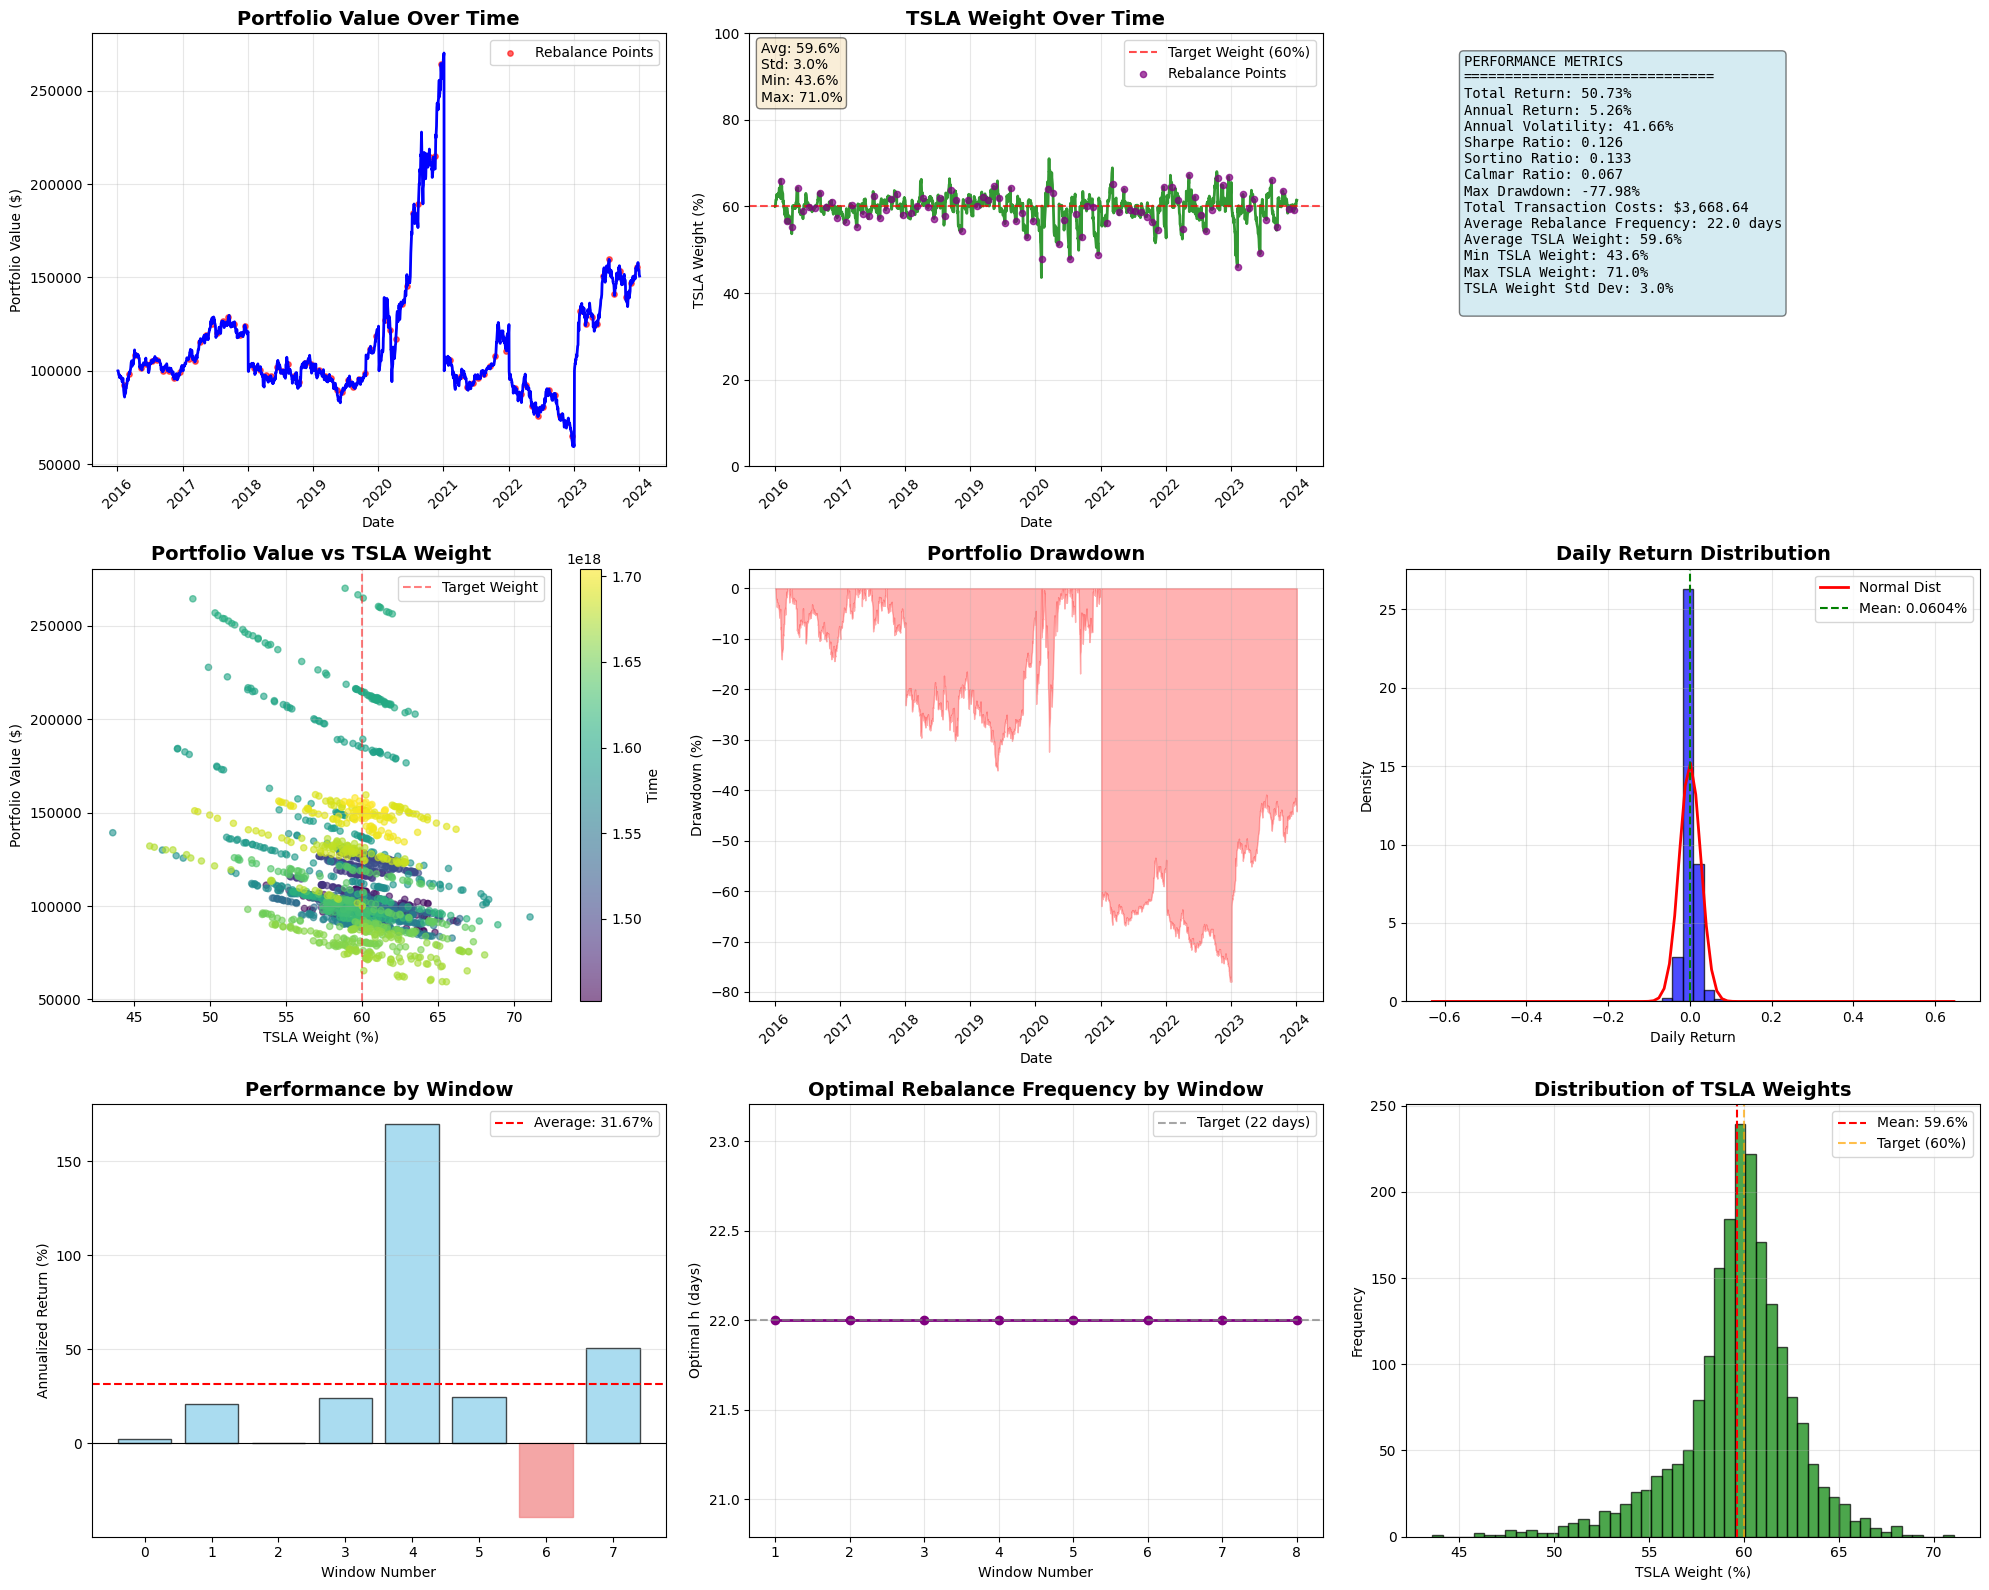


WALK-FORWARD BACKTEST SUMMARY

KEY METRICS:
----------------------------------------
Total Return                  : 50.73%
Annual Return                 : 5.26%
Annual Volatility             : 41.66%
Sharpe Ratio                  : 0.126
Sortino Ratio                 : 0.133
Calmar Ratio                  : 0.067
Max Drawdown                  : -77.98%
Total Transaction Costs       : $3,668.64
Average Rebalance Frequency   : 22.0 days
Total Rebalances              : 88
Number of Windows             : 8
Average TSLA Weight           : 59.6%
Min TSLA Weight               : 43.6%
Max TSLA Weight               : 71.0%
TSLA Weight Std Dev           : 3.0%

WINDOW STATISTICS SUMMARY:
----------------------------------------
Average Window Return: 31.67%
Window Return Std Dev: 61.72%
Best Window Return: 170.14%
Worst Window Return: -39.25%
Positive Windows: 7/8
Average Optimal h: 22.0 days
Average Transaction Costs per Window: $458.58

PORTFOLIO STATISTICS:
----------------------------------

In [21]:
# Step 1: Download data
tickers = ["TSLA", "AGG"]
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")["Close"]
data.columns = ['TSLA', 'AGG']

# Step 2: Adjust Walk-Forward parameters for more windows
train_years = 1
test_years = 1
trading_days_per_year = 252

# Calculate total days
total_days = len(data)
train_days = train_years * trading_days_per_year
test_days = test_years * trading_days_per_year

print(f"\nDATA SUMMARY")
print("=" * 60)
print(f"Data period: {data.index[0].date()} to {data.index[-1].date()}")
print(f"Total data points: {total_days}")
print(f"Training days per window: {train_days}")
print(f"Testing days per window: {test_days}")
num_windows = max(0, (total_days - train_days - test_days) // test_days + 1)
print(f"Number of possible windows: {num_windows}")
print("=" * 60)

# Step 3: Walk-Forward backtesting function (optimized)
def walk_forward_backtest(data, train_days, test_days,
                          w_star=0.6, c=0.005, h_target=22):
    """
    Perform Walk-Forward backtesting for periodic rebalancing strategy.
    """

    # Initialize results storage
    all_portfolio_values = []
    all_portfolio_dates = []
    all_tsla_weights = []  # Track TSLA weights over time
    all_rebalance_dates = []
    all_transaction_costs = []
    all_optimal_h = []
    all_window_stats = []

    # Walk through the data
    start_idx = 0
    window_count = 0

    while start_idx + train_days + test_days <= len(data):
        window_count += 1

        # Split data into training and testing periods
        train_data = data.iloc[start_idx:start_idx + train_days]
        test_data = data.iloc[start_idx + train_days:start_idx + train_days + test_days]

        # Estimate parameters from training window
        train_returns = train_data.pct_change().dropna()

        # Calculate portfolio statistics
        weights = np.array([w_star, 1 - w_star])
        cov_matrix = train_returns.cov()
        portfolio_variance = weights.T @ cov_matrix @ weights
        daily_vol = np.sqrt(portfolio_variance)

        # Calculate optimal h using cube-root rule
        v = (w_star * (1 - w_star) * daily_vol) ** 2
        a = c * np.sqrt(2 * v / np.pi)

        # Estimate lambda from target h
        lambda_val = (c * np.sqrt(2 / np.pi)) / (h_target ** (3/2) * w_star * (1 - w_star) * daily_vol)
        lambda_val = max(0.001, lambda_val)  # Ensure positive

        b = lambda_val * v / 2

        # Calculate optimal h
        h_optimal = int(round((a / (2 * b)) ** (2/3))) if b > 0 else h_target
        h_optimal = max(5, min(h_optimal, test_days))  # Bound between 5 days and test period
        all_optimal_h.append(h_optimal)

        # Backtest on testing period
        initial_capital = 100000

        # Initialize portfolio
        tsla_price = test_data.iloc[0]['TSLA']
        agg_price = test_data.iloc[0]['AGG']

        tsla_shares = (initial_capital * w_star) / tsla_price
        agg_shares = (initial_capital * (1 - w_star)) / agg_price

        transaction_costs_window = 0
        rebalance_count = 0

        portfolio_values = []
        portfolio_dates = []
        tsla_weights_window = []

        # Run backtest
        for i in range(len(test_data)):
            current_date = test_data.index[i]
            current_tsla = test_data.iloc[i]['TSLA']
            current_agg = test_data.iloc[i]['AGG']

            # Calculate current values
            tsla_value = tsla_shares * current_tsla
            agg_value = agg_shares * current_agg
            current_value = tsla_value + agg_value

            # Calculate TSLA weight
            tsla_weight = tsla_value / current_value if current_value > 0 else w_star

            portfolio_values.append(current_value)
            portfolio_dates.append(current_date)
            tsla_weights_window.append(tsla_weight)

            # Check for rebalance (skip first day)
            if i > 0 and i % h_optimal == 0:
                all_rebalance_dates.append(current_date)
                rebalance_count += 1

                # Calculate target values
                target_tsla = current_value * w_star
                target_agg = current_value * (1 - w_star)

                # Trade amounts
                trade_tsla = target_tsla - tsla_value
                trade_agg = target_agg - agg_value

                # Transaction cost
                transaction_cost = c * (abs(trade_tsla) + abs(trade_agg))
                transaction_costs_window += transaction_cost

                # Update shares
                if trade_tsla != 0:
                    tsla_shares += trade_tsla / current_tsla
                if trade_agg != 0:
                    agg_shares += trade_agg / current_agg

                # Deduct transaction cost
                current_value -= transaction_cost

        # Store results for this window
        all_portfolio_values.extend(portfolio_values)
        all_portfolio_dates.extend(portfolio_dates)
        all_tsla_weights.extend(tsla_weights_window)
        all_transaction_costs.append(transaction_costs_window)

        # Store window statistics
        window_return = (portfolio_values[-1] / portfolio_values[0]) - 1
        annualized_return = (1 + window_return) ** (trading_days_per_year / len(test_data)) - 1
        window_volatility = np.std(np.diff(portfolio_values) / portfolio_values[:-1]) * np.sqrt(trading_days_per_year)

        all_window_stats.append({
            'Window': window_count,
            'Start Date': test_data.index[0].date(),
            'End Date': test_data.index[-1].date(),
            'Optimal h': h_optimal,
            'Return': window_return,
            'Annualized Return': annualized_return,
            'Volatility': window_volatility,
            'Transaction Costs': transaction_costs_window,
            'Rebalances': rebalance_count
        })

        # Move to next window
        start_idx += test_days

    print(f"Processed {window_count} complete windows")

    # Create portfolio series
    portfolio_series = pd.Series(all_portfolio_values, index=all_portfolio_dates)
    tsla_weight_series = pd.Series(all_tsla_weights, index=all_portfolio_dates)

    # Calculate overall performance metrics
    if len(portfolio_series) > 1:
        returns = portfolio_series.pct_change().dropna()

        total_return = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) - 1
        annual_return = (1 + total_return) ** (trading_days_per_year / len(portfolio_series)) - 1
        volatility = returns.std() * np.sqrt(trading_days_per_year)
        sharpe_ratio = annual_return / volatility if volatility > 0 else 0

        # Maximum drawdown
        rolling_max = portfolio_series.expanding().max()
        drawdowns = (portfolio_series - rolling_max) / rolling_max
        max_drawdown = drawdowns.min()

        # Sortino ratio
        negative_returns = returns[returns < 0]
        downside_dev = negative_returns.std() * np.sqrt(trading_days_per_year) if len(negative_returns) > 0 else 0
        sortino_ratio = annual_return / downside_dev if downside_dev > 0 else 0

        # Calmar ratio
        calmar_ratio = annual_return / abs(max_drawdown) if max_drawdown < 0 else 0

        # Total transaction costs
        total_transaction_costs = sum(all_transaction_costs)
        avg_optimal_h = np.mean(all_optimal_h)

        # TSLA weight statistics
        avg_tsla_weight = tsla_weight_series.mean()
        min_tsla_weight = tsla_weight_series.min()
        max_tsla_weight = tsla_weight_series.max()
        std_tsla_weight = tsla_weight_series.std()

        # Create results dictionary
        results = {
            'Total Return': f"{total_return:.2%}",
            'Annual Return': f"{annual_return:.2%}",
            'Annual Volatility': f"{volatility:.2%}",
            'Sharpe Ratio': f"{sharpe_ratio:.3f}",
            'Sortino Ratio': f"{sortino_ratio:.3f}",
            'Calmar Ratio': f"{calmar_ratio:.3f}",
            'Max Drawdown': f"{max_drawdown:.2%}",
            'Total Transaction Costs': f"${total_transaction_costs:,.2f}",
            'Average Rebalance Frequency': f"{avg_optimal_h:.1f} days",
            'Total Rebalances': len(all_rebalance_dates),
            'Number of Windows': window_count,
            'Average TSLA Weight': f"{avg_tsla_weight:.1%}",
            'Min TSLA Weight': f"{min_tsla_weight:.1%}",
            'Max TSLA Weight': f"{max_tsla_weight:.1%}",
            'TSLA Weight Std Dev': f"{std_tsla_weight:.1%}"
        }
    else:
        results = {"Error": "Insufficient data for analysis"}

    return results, portfolio_series, tsla_weight_series, all_window_stats, all_rebalance_dates

# Step 4: Run the Walk-Forward backtest
print("\nRunning Walk-Forward Backtest...")
print("=" * 60)

results, portfolio_series, tsla_weight_series, window_stats, rebalance_dates = walk_forward_backtest(
    data, train_days, test_days, w_star=0.6, c=0.005, h_target=22
)

# Step 5: Create comprehensive visualizations
fig = plt.figure(figsize=(20, 16))

# 1. Portfolio Value Over Time (Requested Plot #1)
ax1 = plt.subplot(3, 3, 1)
ax1.plot(portfolio_series.index, portfolio_series.values, linewidth=2, color='blue')
ax1.set_title('Portfolio Value Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Portfolio Value ($)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Mark rebalance points
if rebalance_dates:
    rebalance_values = portfolio_series[portfolio_series.index.isin(rebalance_dates)]
    ax1.scatter(rebalance_values.index, rebalance_values.values,
               color='red', s=15, alpha=0.6, label='Rebalance Points')
    ax1.legend()

# 2. TSLA Weight Over Time (Requested Plot #2)
ax2 = plt.subplot(3, 3, 2)
ax2.plot(tsla_weight_series.index, tsla_weight_series.values * 100,
        linewidth=2, color='green', alpha=0.8)
ax2.axhline(y=60, color='red', linestyle='--', linewidth=1.5,
           label='Target Weight (60%)', alpha=0.7)

# Highlight rebalance points on weight chart
if rebalance_dates:
    rebalance_weights = tsla_weight_series[tsla_weight_series.index.isin(rebalance_dates)]
    ax2.scatter(rebalance_weights.index, rebalance_weights.values * 100,
               color='purple', s=20, alpha=0.7, zorder=5, label='Rebalance Points')

ax2.set_title('TSLA Weight Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('TSLA Weight (%)')
ax2.set_ylim([0, 100])
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

# Add weight statistics to the plot
weight_stats_text = f"Avg: {tsla_weight_series.mean()*100:.1f}%\nStd: {tsla_weight_series.std()*100:.1f}%\nMin: {tsla_weight_series.min()*100:.1f}%\nMax: {tsla_weight_series.max()*100:.1f}%"
ax2.text(0.02, 0.98, weight_stats_text, transform=ax2.transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Performance Metrics Table
ax3 = plt.subplot(3, 3, 3)
ax3.axis('off')
metrics_text = "PERFORMANCE METRICS\n" + "="*30 + "\n"
for key, value in results.items():
    if key not in ['Number of Windows', 'Total Rebalances']:
        metrics_text += f"{key}: {value}\n"
ax3.text(0.1, 0.95, metrics_text, fontsize=10, fontfamily='monospace',
        verticalalignment='top', transform=ax3.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 4. Portfolio Value vs TSLA Weight Correlation
ax4 = plt.subplot(3, 3, 4)
scatter = ax4.scatter(tsla_weight_series.values * 100, portfolio_series.values,
                     c=pd.to_datetime(portfolio_series.index).astype(int),
                     cmap='viridis', alpha=0.6, s=20)
ax4.axvline(x=60, color='red', linestyle='--', alpha=0.5, label='Target Weight')
ax4.set_xlabel('TSLA Weight (%)')
ax4.set_ylabel('Portfolio Value ($)')
ax4.set_title('Portfolio Value vs TSLA Weight', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

# Add colorbar for time
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Time')

# 5. Drawdown Analysis
ax5 = plt.subplot(3, 3, 5)
rolling_max = portfolio_series.expanding().max()
drawdown = (portfolio_series - rolling_max) / rolling_max * 100
ax5.fill_between(portfolio_series.index, drawdown.values, 0,
                 color='red', alpha=0.3)
ax5.set_title('Portfolio Drawdown', fontsize=14, fontweight='bold')
ax5.set_xlabel('Date')
ax5.set_ylabel('Drawdown (%)')
ax5.grid(True, alpha=0.3)
ax5.tick_params(axis='x', rotation=45)

# 6. Return Distribution
ax6 = plt.subplot(3, 3, 6)
returns = portfolio_series.pct_change().dropna()
if len(returns) > 10:
    ax6.hist(returns, bins=50, alpha=0.7, color='blue', edgecolor='black', density=True)

    # Add normal distribution for comparison
    x = np.linspace(returns.min(), returns.max(), 100)
    mu, sigma = returns.mean(), returns.std()
    normal_dist = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
    ax6.plot(x, normal_dist, 'r-', linewidth=2, label='Normal Dist')

    ax6.axvline(x=mu, color='green', linestyle='--',
               label=f'Mean: {mu:.4%}')
    ax6.set_title('Daily Return Distribution', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Daily Return')
    ax6.set_ylabel('Density')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

# 7. Window-by-Window Performance
ax7 = plt.subplot(3, 3, 7)
if window_stats:
    windows_df = pd.DataFrame(window_stats)
    x_pos = np.arange(len(windows_df))

    bars = ax7.bar(x_pos, windows_df['Annualized Return'] * 100,
                  alpha=0.7, color='skyblue', edgecolor='black')

    # Color negative returns red
    for i, bar in enumerate(bars):
        if windows_df.iloc[i]['Annualized Return'] < 0:
            bar.set_color('lightcoral')

    ax7.axhline(y=0, color='black', linewidth=0.8)
    ax7.set_xlabel('Window Number')
    ax7.set_ylabel('Annualized Return (%)')
    ax7.set_title('Performance by Window', fontsize=14, fontweight='bold')
    ax7.grid(True, alpha=0.3, axis='y')

    # Add average line
    avg_return = windows_df['Annualized Return'].mean() * 100
    ax7.axhline(y=avg_return, color='red', linestyle='--',
               label=f'Average: {avg_return:.2f}%')
    ax7.legend()

# 8. Optimal Rebalance Frequency by Window
ax8 = plt.subplot(3, 3, 8)
if window_stats:
    windows_df = pd.DataFrame(window_stats)
    ax8.plot(windows_df['Window'], windows_df['Optimal h'],
            marker='o', linewidth=2, color='purple')
    ax8.axhline(y=22, color='gray', linestyle='--',
               label='Target (22 days)', alpha=0.7)
    ax8.set_xlabel('Window Number')
    ax8.set_ylabel('Optimal h (days)')
    ax8.set_title('Optimal Rebalance Frequency by Window', fontsize=14, fontweight='bold')
    ax8.legend()
    ax8.grid(True, alpha=0.3)

# 9. TSLA Weight Distribution
ax9 = plt.subplot(3, 3, 9)
if len(tsla_weight_series) > 10:
    ax9.hist(tsla_weight_series.values * 100, bins=50, alpha=0.7,
            color='green', edgecolor='black')
    ax9.axvline(x=tsla_weight_series.mean() * 100, color='red',
               linestyle='--', label=f'Mean: {tsla_weight_series.mean()*100:.1f}%')
    ax9.axvline(x=60, color='orange', linestyle='--',
               alpha=0.7, label='Target (60%)')
    ax9.set_xlabel('TSLA Weight (%)')
    ax9.set_ylabel('Frequency')
    ax9.set_title('Distribution of TSLA Weights', fontsize=14, fontweight='bold')
    ax9.legend()
    ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 6: Additional analysis and summary
print("\n" + "="*60)
print("WALK-FORWARD BACKTEST SUMMARY")
print("="*60)

# Print key metrics
print("\nKEY METRICS:")
print("-" * 40)
for key, value in results.items():
    print(f"{key:30}: {value}")

# Window statistics summary
if window_stats:
    windows_df = pd.DataFrame(window_stats)
    print("\nWINDOW STATISTICS SUMMARY:")
    print("-" * 40)
    print(f"Average Window Return: {windows_df['Return'].mean():.2%}")
    print(f"Window Return Std Dev: {windows_df['Return'].std():.2%}")
    print(f"Best Window Return: {windows_df['Return'].max():.2%}")
    print(f"Worst Window Return: {windows_df['Return'].min():.2%}")
    print(f"Positive Windows: {(windows_df['Return'] > 0).sum()}/{len(windows_df)}")
    print(f"Average Optimal h: {windows_df['Optimal h'].mean():.1f} days")
    print(f"Average Transaction Costs per Window: ${windows_df['Transaction Costs'].mean():.2f}")

# Portfolio statistics
print("\nPORTFOLIO STATISTICS:")
print("-" * 40)
if len(portfolio_series) > 1:
    # Monthly statistics
    monthly_returns = portfolio_series.resample('M').last().pct_change().dropna()
    print(f"Average Monthly Return: {monthly_returns.mean() * 100:.2f}%")
    print(f"Monthly Win Rate: {(monthly_returns > 0).mean() * 100:.1f}%")
    print(f"Best Month: {monthly_returns.max() * 100:.2f}%")
    print(f"Worst Month: {monthly_returns.min() * 100:.2f}%")

    # Risk-adjusted metrics
    total_days = len(portfolio_series)
    cagr = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) ** (252/total_days) - 1
    volatility = portfolio_series.pct_change().std() * np.sqrt(252)
    sharpe = cagr / volatility if volatility > 0 else 0

    print(f"\nCAGR: {cagr:.2%}")
    print(f"Annual Volatility: {volatility:.2%}")
    print(f"Sharpe Ratio: {sharpe:.3f}")

# Asset statistics
print("\nASSET STATISTICS (Full Period):")
print("-" * 40)
print(f"TSLA Final Price: ${data['TSLA'].iloc[-1]:.2f}")
print(f"AGG Final Price: ${data['AGG'].iloc[-1]:.2f}")
print(f"TSLA Total Return: {(data['TSLA'].iloc[-1] / data['TSLA'].iloc[0] - 1):.2%}")
print(f"AGG Total Return: {(data['AGG'].iloc[-1] / data['AGG'].iloc[0] - 1):.2%}")

# TSLA weight statistics
print("\nTSLA WEIGHT STATISTICS:")
print("-" * 40)
print(f"Average TSLA Weight: {tsla_weight_series.mean()*100:.1f}%")
print(f"TSLA Weight Std Dev: {tsla_weight_series.std()*100:.1f}%")
print(f"Minimum TSLA Weight: {tsla_weight_series.min()*100:.1f}%")
print(f"Maximum TSLA Weight: {tsla_weight_series.max()*100:.1f}%")
print(f"Time below 55%: {(tsla_weight_series < 0.55).mean()*100:.1f}%")
print(f"Time above 65%: {(tsla_weight_series > 0.65).mean()*100:.1f}%")


We have from the cube-root rule:
h* = ( (c/λ) * sqrt(2/π) * 1/(w*(1-w)*σ) )^(2/3)


Then, note that the expected absolute deviation at time h* is:
E|d_{h*}| = sqrt(2/π) * sqrt(v * h*)

where v = (w*(1-w)*σ)^2.


So, we can compute the no-trade band as follows:
δ* = sqrt(2/π) * (w*(1-w)*σ) * sqrt(h*)

Or expressing without h*:
δ* = sqrt(2/π) * [ (c/λ) * sqrt(2/π) ]^(1/3) * (w*(1-w)*σ)^(2/3)

Then, by using the δ*, we can backtest on the threshold rebalancing strategy. Here, we are also using the Walk-Forward method.


[*********************100%***********************]  2 of 2 completed


THRESHOLD REBALANCING STRATEGY BACKTEST
Data period: 2015-01-02 to 2024-12-31
Parameters: w* = 0.6, c = 50 bps, target h = 22 days
Training: 1 year, Testing: 1 year

Running Threshold Rebalancing Backtest...
--------------------------------------------------------------------------------
Processed 8 complete windows

Generating visualizations...


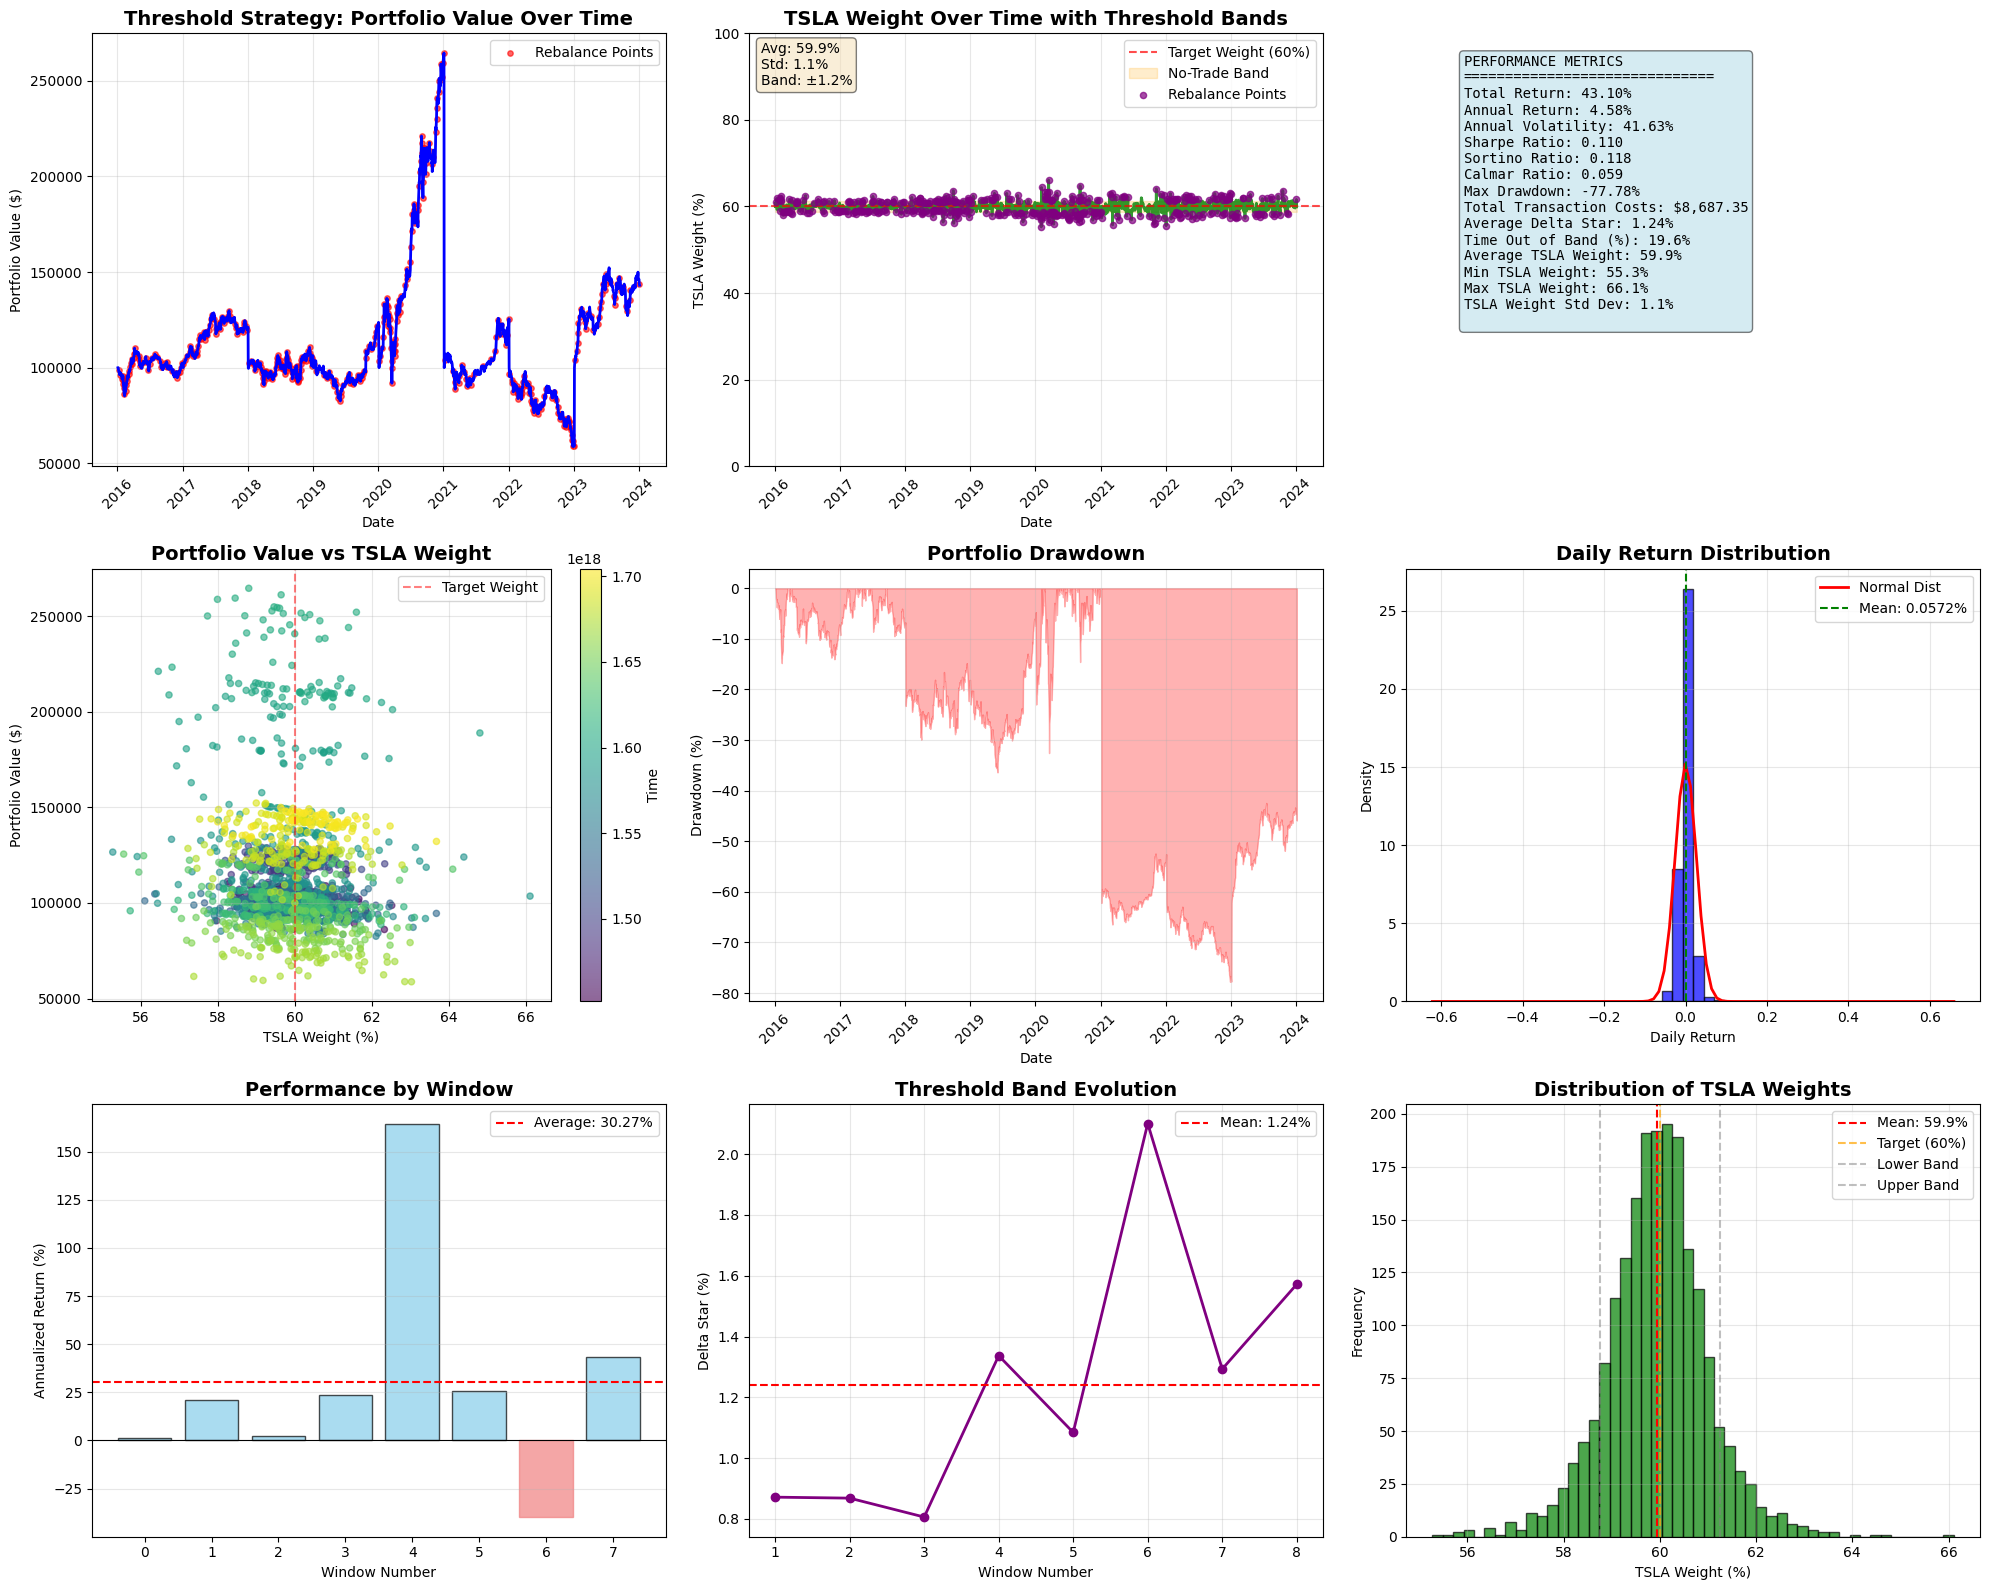


THRESHOLD STRATEGY SUMMARY

KEY METRICS:
----------------------------------------
Total Return                  : 43.10%
Annual Return                 : 4.58%
Annual Volatility             : 41.63%
Sharpe Ratio                  : 0.110
Sortino Ratio                 : 0.118
Calmar Ratio                  : 0.059
Max Drawdown                  : -77.78%
Total Transaction Costs       : $8,687.35
Average Delta Star            : 1.24%
Total Rebalances              : 422
Number of Windows             : 8
Time Out of Band (%)          : 19.6%
Average TSLA Weight           : 59.9%
Min TSLA Weight               : 55.3%
Max TSLA Weight               : 66.1%
TSLA Weight Std Dev           : 1.1%

WINDOW STATISTICS SUMMARY:
----------------------------------------
Average Window Return: 30.27%
Window Return Std Dev: 59.57%
Best Window Return: 164.52%
Worst Window Return: -39.73%
Positive Windows: 7/8
Average Delta Star: 1.24%
Average Transaction Costs per Window: $1085.92
Average Rebalances per Wind

In [22]:
# Initial parameter calculation

def calculate_threshold_parameters(c, lambda_val, w_star, sigma_daily):
    """
    Calculate threshold (no-trade band) δ* from parameters
    δ* = sqrt(2/π) * [ (c/λ) * sqrt(2/π) ]^(1/3) * (w*(1-w)*σ)^(2/3)
    """
    # Calculate v
    v = (w_star * (1 - w_star) * sigma_daily) ** 2

    # Calculate optimal h from cube-root rule
    a = c * np.sqrt(2 * v / np.pi)
    b = lambda_val * v / 2
    h_star = (a / (2 * b)) ** (2/3) if b > 0 else 0

    # Calculate δ* using the formula
    term1 = np.sqrt(2 / np.pi)
    term2 = ((c / lambda_val) * np.sqrt(2 / np.pi)) ** (1/3)
    term3 = (w_star * (1 - w_star) * sigma_daily) ** (2/3)

    delta_star = term1 * term2 * term3

    return delta_star, h_star

def calculate_lambda_from_h(h_days, w, c, sigma_daily):
    """
    Calculate λ from the rearranged cube-root rule:
    λ = (c / h^(3/2)) * sqrt(2/π) * 1/(w*(1-w)*σ)
    """
    numerator = c * np.sqrt(2 / np.pi)
    denominator = (h_days ** (3/2)) * w * (1 - w) * sigma_daily
    lambda_val = numerator / denominator
    return lambda_val

def calculate_portfolio_value(tsla_shares, agg_shares, tsla_price, agg_price, w_star):
    """
    Calculate current portfolio value and TSLA weight
    """
    tsla_value = tsla_shares * tsla_price
    agg_value = agg_shares * agg_price
    portfolio_value = tsla_value + agg_value
    tsla_weight = tsla_value / portfolio_value if portfolio_value > 0 else w_star
    return portfolio_value, tsla_weight, tsla_value, agg_value


# THRESHOLD REBALANCING BACKTEST

def walk_forward_threshold_backtest(data, train_days, test_days,
                                   w_star=0.6, c=0.005, h_target=22):
    """
    Perform Walk-Forward backtest for THRESHOLD rebalancing strategy.
    Rebalance only when |w_t - w*| >= δ*
    """

    # Initialize results storage
    all_portfolio_values = []
    all_portfolio_dates = []
    all_tsla_weights = []
    all_rebalance_dates = []
    all_transaction_costs = []
    all_delta_stars = []
    all_window_stats = []

    # Walk through the data
    start_idx = 0
    window_count = 0

    while start_idx + train_days + test_days <= len(data):
        window_count += 1

        # Split data into training and testing periods
        train_data = data.iloc[start_idx:start_idx + train_days]
        test_data = data.iloc[start_idx + train_days:start_idx + train_days + test_days]

        # Estimate parameters from training window
        train_returns = train_data.pct_change().dropna()

        # Calculate portfolio statistics
        weights = np.array([w_star, 1 - w_star])
        cov_matrix = train_returns.cov()
        portfolio_variance = weights.T @ cov_matrix @ weights
        daily_vol = np.sqrt(portfolio_variance)

        # Estimate lambda from target h
        lambda_val = calculate_lambda_from_h(h_target, w_star, c, daily_vol)
        lambda_val = max(0.001, lambda_val)  # Ensure positive

        # Calculate threshold δ*
        delta_star, h_optimal = calculate_threshold_parameters(c, lambda_val, w_star, daily_vol)
        all_delta_stars.append(delta_star)

        # Backtest on testing period with threshold strategy
        initial_capital = 100000

        # Initialize portfolio
        tsla_shares = (initial_capital * w_star) / test_data.iloc[0]['TSLA']
        agg_shares = (initial_capital * (1 - w_star)) / test_data.iloc[0]['AGG']

        transaction_costs_window = 0
        rebalance_count = 0

        portfolio_values = []
        portfolio_dates = []
        tsla_weights_window = []
        deviations = []

        # Run backtest
        for i in range(len(test_data)):
            current_date = test_data.index[i]
            current_tsla = test_data.iloc[i]['TSLA']
            current_agg = test_data.iloc[i]['AGG']

            # Calculate current portfolio value and TSLA weight
            portfolio_value, tsla_weight, tsla_value, agg_value = calculate_portfolio_value(
                tsla_shares, agg_shares, current_tsla, current_agg, w_star
            )

            deviation = tsla_weight - w_star

            portfolio_values.append(portfolio_value)
            portfolio_dates.append(current_date)
            tsla_weights_window.append(tsla_weight)
            deviations.append(deviation)

            # Check for rebalance based on threshold (skip first day)
            if i > 0 and abs(deviation) >= delta_star:
                all_rebalance_dates.append(current_date)
                rebalance_count += 1

                # Calculate target values
                target_tsla = portfolio_value * w_star
                target_agg = portfolio_value * (1 - w_star)

                # Trade amounts
                trade_tsla = target_tsla - tsla_value
                trade_agg = target_agg - agg_value

                # Transaction cost
                transaction_cost = c * (abs(trade_tsla) + abs(trade_agg))
                transaction_costs_window += transaction_cost

                # Update shares
                if trade_tsla != 0:
                    tsla_shares += trade_tsla / current_tsla
                if trade_agg != 0:
                    agg_shares += trade_agg / current_agg

                # Deduct transaction cost
                portfolio_value -= transaction_cost

        # Store results for this window
        all_portfolio_values.extend(portfolio_values)
        all_portfolio_dates.extend(portfolio_dates)
        all_tsla_weights.extend(tsla_weights_window)
        all_transaction_costs.append(transaction_costs_window)

        # Calculate deviation statistics
        deviations_array = np.array(deviations)
        time_out_of_band = (np.abs(deviations_array) >= delta_star).mean() * 100

        # Calculate window performance
        window_return = (portfolio_values[-1] / portfolio_values[0]) - 1
        annualized_return = (1 + window_return) ** (252 / len(test_data)) - 1
        window_volatility = np.std(np.diff(portfolio_values) / portfolio_values[:-1]) * np.sqrt(252)

        # Store window statistics
        all_window_stats.append({
            'Window': window_count,
            'Start Date': test_data.index[0].date(),
            'End Date': test_data.index[-1].date(),
            'Delta Star': delta_star,
            'Delta Star (%)': delta_star * 100,
            'Implied h': h_optimal,
            'Return': window_return,
            'Annualized Return': annualized_return,
            'Volatility': window_volatility,
            'Transaction Costs': transaction_costs_window,
            'Rebalances': rebalance_count,
            'Time Out of Band (%)': time_out_of_band
        })

        # Move to next window
        start_idx += test_days

    print(f"Processed {window_count} complete windows")

    # Create portfolio series
    portfolio_series = pd.Series(all_portfolio_values, index=all_portfolio_dates)
    tsla_weight_series = pd.Series(all_tsla_weights, index=all_portfolio_dates)

    # Calculate overall performance metrics
    if len(portfolio_series) > 1:
        returns = portfolio_series.pct_change().dropna()

        # Basic return metrics
        total_return = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) - 1
        annual_return = (1 + total_return) ** (252 / len(portfolio_series)) - 1
        volatility = returns.std() * np.sqrt(252)
        sharpe_ratio = annual_return / volatility if volatility > 0 else 0

        # Drawdown metrics
        rolling_max = portfolio_series.expanding().max()
        drawdowns = (portfolio_series - rolling_max) / rolling_max
        max_drawdown = drawdowns.min()

        # Sortino ratio
        negative_returns = returns[returns < 0]
        downside_dev = negative_returns.std() * np.sqrt(252) if len(negative_returns) > 0 else 0
        sortino_ratio = annual_return / downside_dev if downside_dev > 0 else 0

        # Calmar ratio
        calmar_ratio = annual_return / abs(max_drawdown) if max_drawdown < 0 else 0

        # Total transaction costs
        total_transaction_costs = sum(all_transaction_costs)
        avg_delta_star = np.mean(all_delta_stars) * 100

        # TSLA weight statistics
        avg_tsla_weight = tsla_weight_series.mean()
        min_tsla_weight = tsla_weight_series.min()
        max_tsla_weight = tsla_weight_series.max()
        std_tsla_weight = tsla_weight_series.std()

        # Deviation statistics
        deviations_all = tsla_weight_series - w_star
        time_out_of_band_all = (np.abs(deviations_all) >= avg_delta_star/100).mean() * 100

        # Create results dictionary
        results = {
            'Total Return': f"{total_return:.2%}",
            'Annual Return': f"{annual_return:.2%}",
            'Annual Volatility': f"{volatility:.2%}",
            'Sharpe Ratio': f"{sharpe_ratio:.3f}",
            'Sortino Ratio': f"{sortino_ratio:.3f}",
            'Calmar Ratio': f"{calmar_ratio:.3f}",
            'Max Drawdown': f"{max_drawdown:.2%}",
            'Total Transaction Costs': f"${total_transaction_costs:,.2f}",
            'Average Delta Star': f"{avg_delta_star:.2f}%",
            'Total Rebalances': len(all_rebalance_dates),
            'Number of Windows': window_count,
            'Time Out of Band (%)': f"{time_out_of_band_all:.1f}%",
            'Average TSLA Weight': f"{avg_tsla_weight:.1%}",
            'Min TSLA Weight': f"{min_tsla_weight:.1%}",
            'Max TSLA Weight': f"{max_tsla_weight:.1%}",
            'TSLA Weight Std Dev': f"{std_tsla_weight:.1%}"
        }
    else:
        results = {"Error": "Insufficient data for analysis"}

    return results, portfolio_series, tsla_weight_series, all_window_stats, all_rebalance_dates


# Visualisation

def create_threshold_strategy_plots(results, portfolio_series, tsla_weight_series,
                                   window_stats, rebalance_dates, w_star=0.6):
    """
    Create comprehensive visualization for threshold strategy
    """
    fig = plt.figure(figsize=(20, 16))

    # Calculate average delta star for visualization
    if window_stats:
        avg_delta = np.mean([stats['Delta Star'] for stats in window_stats]) * 100

    # 1. Portfolio Value Over Time
    ax1 = plt.subplot(3, 3, 1)
    ax1.plot(portfolio_series.index, portfolio_series.values, linewidth=2, color='blue')
    ax1.set_title('Threshold Strategy: Portfolio Value Over Time', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    # Mark rebalance points
    if rebalance_dates:
        rebalance_values = portfolio_series[portfolio_series.index.isin(rebalance_dates)]
        ax1.scatter(rebalance_values.index, rebalance_values.values,
                   color='red', s=15, alpha=0.6, label='Rebalance Points')
        ax1.legend()

    # 2. TSLA Weight Over Time with Threshold Bands
    ax2 = plt.subplot(3, 3, 2)

    ax2.plot(tsla_weight_series.index, tsla_weight_series.values * 100,
            linewidth=2, color='green', alpha=0.8)
    ax2.axhline(y=w_star*100, color='red', linestyle='--', linewidth=1.5,
               label='Target Weight (60%)', alpha=0.7)

    # Add threshold bands if available
    if window_stats:
        ax2.fill_between(tsla_weight_series.index,
                        w_star*100 - avg_delta,
                        w_star*100 + avg_delta,
                        color='orange', alpha=0.2, label='No-Trade Band')

    # Highlight rebalance points
    if rebalance_dates:
        rebalance_weights = tsla_weight_series[tsla_weight_series.index.isin(rebalance_dates)]
        ax2.scatter(rebalance_weights.index, rebalance_weights.values * 100,
                   color='purple', s=20, alpha=0.7, zorder=5, label='Rebalance Points')

    ax2.set_title('TSLA Weight Over Time with Threshold Bands', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('TSLA Weight (%)')
    ax2.set_ylim([0, 100])
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend()

    # Add weight statistics
    weight_stats_text = f"Avg: {tsla_weight_series.mean()*100:.1f}%\nStd: {tsla_weight_series.std()*100:.1f}%"
    if window_stats:
        weight_stats_text += f"\nBand: ±{avg_delta:.1f}%"
    ax2.text(0.02, 0.98, weight_stats_text, transform=ax2.transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 3. Performance Metrics Table
    ax3 = plt.subplot(3, 3, 3)
    ax3.axis('off')
    metrics_text = "PERFORMANCE METRICS\n" + "="*30 + "\n"
    for key, value in results.items():
        if key not in ['Number of Windows', 'Total Rebalances']:
            metrics_text += f"{key}: {value}\n"
    ax3.text(0.1, 0.95, metrics_text, fontsize=10, fontfamily='monospace',
            verticalalignment='top', transform=ax3.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    # 4. Portfolio Value vs TSLA Weight
    ax4 = plt.subplot(3, 3, 4)
    scatter = ax4.scatter(tsla_weight_series.values * 100, portfolio_series.values,
                         c=pd.to_datetime(portfolio_series.index).astype(int),
                         cmap='viridis', alpha=0.6, s=20)
    ax4.axvline(x=w_star*100, color='red', linestyle='--', alpha=0.5, label='Target Weight')
    ax4.set_xlabel('TSLA Weight (%)')
    ax4.set_ylabel('Portfolio Value ($)')
    ax4.set_title('Portfolio Value vs TSLA Weight', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.legend()

    # Add colorbar for time
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Time')

    # 5. Drawdown Analysis
    ax5 = plt.subplot(3, 3, 5)
    rolling_max = portfolio_series.expanding().max()
    drawdown = (portfolio_series - rolling_max) / rolling_max * 100
    ax5.fill_between(portfolio_series.index, drawdown.values, 0,
                     color='red', alpha=0.3)
    ax5.set_title('Portfolio Drawdown', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Drawdown (%)')
    ax5.grid(True, alpha=0.3)
    ax5.tick_params(axis='x', rotation=45)

    # 6. Return Distribution
    ax6 = plt.subplot(3, 3, 6)
    returns = portfolio_series.pct_change().dropna()
    if len(returns) > 10:
        ax6.hist(returns, bins=50, alpha=0.7, color='blue', edgecolor='black', density=True)

        # Add normal distribution
        x = np.linspace(returns.min(), returns.max(), 100)
        mu, sigma = returns.mean(), returns.std()
        normal_dist = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
        ax6.plot(x, normal_dist, 'r-', linewidth=2, label='Normal Dist')

        ax6.axvline(x=mu, color='green', linestyle='--',
                   label=f'Mean: {mu:.4%}')
        ax6.set_title('Daily Return Distribution', fontsize=14, fontweight='bold')
        ax6.set_xlabel('Daily Return')
        ax6.set_ylabel('Density')
        ax6.legend()
        ax6.grid(True, alpha=0.3)

    # 7. Window-by-Window Performance
    ax7 = plt.subplot(3, 3, 7)
    if window_stats:
        windows_df = pd.DataFrame(window_stats)
        x_pos = np.arange(len(windows_df))

        bars = ax7.bar(x_pos, windows_df['Annualized Return'] * 100,
                      alpha=0.7, color='skyblue', edgecolor='black')

        # Color negative returns red
        for i, bar in enumerate(bars):
            if windows_df.iloc[i]['Annualized Return'] < 0:
                bar.set_color('lightcoral')

        ax7.axhline(y=0, color='black', linewidth=0.8)
        ax7.set_xlabel('Window Number')
        ax7.set_ylabel('Annualized Return (%)')
        ax7.set_title('Performance by Window', fontsize=14, fontweight='bold')
        ax7.grid(True, alpha=0.3, axis='y')

        # Add average line
        avg_return = windows_df['Annualized Return'].mean() * 100
        ax7.axhline(y=avg_return, color='red', linestyle='--',
                   label=f'Average: {avg_return:.2f}%')
        ax7.legend()

    # 8. Threshold Band Evolution
    ax8 = plt.subplot(3, 3, 8)
    if window_stats:
        windows_df = pd.DataFrame(window_stats)
        ax8.plot(windows_df['Window'], windows_df['Delta Star (%)'],
                marker='o', linewidth=2, color='purple')
        ax8.axhline(y=windows_df['Delta Star (%)'].mean(), color='red',
                   linestyle='--', label=f'Mean: {windows_df["Delta Star (%)"].mean():.2f}%')
        ax8.set_xlabel('Window Number')
        ax8.set_ylabel('Delta Star (%)')
        ax8.set_title('Threshold Band Evolution', fontsize=14, fontweight='bold')
        ax8.legend()
        ax8.grid(True, alpha=0.3)

    # 9. TSLA Weight Distribution
    ax9 = plt.subplot(3, 3, 9)
    if len(tsla_weight_series) > 10:
        ax9.hist(tsla_weight_series.values * 100, bins=50, alpha=0.7,
                color='green', edgecolor='black')
        ax9.axvline(x=tsla_weight_series.mean() * 100, color='red',
                   linestyle='--', label=f'Mean: {tsla_weight_series.mean()*100:.1f}%')
        ax9.axvline(x=w_star*100, color='orange', linestyle='--',
                   alpha=0.7, label='Target (60%)')

        # Add threshold bands if available
        if window_stats:
            ax9.axvline(x=w_star*100 - avg_delta, color='gray', linestyle='--',
                       alpha=0.5, label='Lower Band')
            ax9.axvline(x=w_star*100 + avg_delta, color='gray', linestyle='--',
                       alpha=0.5, label='Upper Band')

        ax9.set_xlabel('TSLA Weight (%)')
        ax9.set_ylabel('Frequency')
        ax9.set_title('Distribution of TSLA Weights', fontsize=14, fontweight='bold')
        ax9.legend()
        ax9.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Execution

# Load data
tickers = ["TSLA", "AGG"]
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")["Close"]
data.columns = ['TSLA', 'AGG']

# Parameters
train_years = 1
test_years = 1
trading_days_per_year = 252
train_days = train_years * trading_days_per_year
test_days = test_years * trading_days_per_year

w_star = 0.6
c = 0.005
h_target = 22

print("=" * 80)
print("THRESHOLD REBALANCING STRATEGY BACKTEST")
print("=" * 80)
print(f"Data period: {data.index[0].date()} to {data.index[-1].date()}")
print(f"Parameters: w* = {w_star}, c = {c*10000:.0f} bps, target h = {h_target} days")
print(f"Training: {train_years} year, Testing: {test_years} year")
print("=" * 80)

# Run threshold rebalancing backtest
print("\nRunning Threshold Rebalancing Backtest...")
print("-" * 80)

results, portfolio_series, tsla_weight_series, window_stats, rebalance_dates = \
    walk_forward_threshold_backtest(data, train_days, test_days, w_star, c, h_target)

# Create visualizations
print("\nGenerating visualizations...")
create_threshold_strategy_plots(results, portfolio_series, tsla_weight_series,
                               window_stats, rebalance_dates, w_star)

# Print summary
print("\n" + "="*80)
print("THRESHOLD STRATEGY SUMMARY")
print("="*80)

print("\nKEY METRICS:")
print("-" * 40)
for key, value in results.items():
    print(f"{key:30}: {value}")

# Window statistics summary
if window_stats:
    windows_df = pd.DataFrame(window_stats)
    print("\nWINDOW STATISTICS SUMMARY:")
    print("-" * 40)
    print(f"Average Window Return: {windows_df['Return'].mean():.2%}")
    print(f"Window Return Std Dev: {windows_df['Return'].std():.2%}")
    print(f"Best Window Return: {windows_df['Return'].max():.2%}")
    print(f"Worst Window Return: {windows_df['Return'].min():.2%}")
    print(f"Positive Windows: {(windows_df['Return'] > 0).sum()}/{len(windows_df)}")
    print(f"Average Delta Star: {windows_df['Delta Star (%)'].mean():.2f}%")
    print(f"Average Transaction Costs per Window: ${windows_df['Transaction Costs'].mean():.2f}")
    print(f"Average Rebalances per Window: {windows_df['Rebalances'].mean():.1f}")

# Portfolio statistics
print("\nPORTFOLIO STATISTICS:")
print("-" * 40)
if len(portfolio_series) > 1:
    # Monthly statistics
    monthly_returns = portfolio_series.resample('M').last().pct_change().dropna()
    print(f"Average Monthly Return: {monthly_returns.mean() * 100:.2f}%")
    print(f"Monthly Win Rate: {(monthly_returns > 0).mean() * 100:.1f}%")
    print(f"Best Month: {monthly_returns.max() * 100:.2f}%")
    print(f"Worst Month: {monthly_returns.min() * 100:.2f}%")

    # Risk-adjusted metrics
    total_days = len(portfolio_series)
    cagr = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) ** (252/total_days) - 1
    volatility = portfolio_series.pct_change().std() * np.sqrt(252)
    sharpe = cagr / volatility if volatility > 0 else 0

    print(f"\nCAGR: {cagr:.2%}")
    print(f"Annual Volatility: {volatility:.2%}")
    print(f"Sharpe Ratio: {sharpe:.3f}")

# TSLA weight statistics
print("\nTSLA WEIGHT STATISTICS:")
print("-" * 40)
print(f"Average TSLA Weight: {tsla_weight_series.mean()*100:.1f}%")
print(f"TSLA Weight Std Dev: {tsla_weight_series.std()*100:.1f}%")
print(f"Minimum TSLA Weight: {tsla_weight_series.min()*100:.1f}%")
print(f"Maximum TSLA Weight: {tsla_weight_series.max()*100:.1f}%")

# Threshold-specific statistics
if 'Average Delta Star' in results:
    delta_star = float(results['Average Delta Star'].replace('%', ''))
    lower_bound = w_star*100 - delta_star
    upper_bound = w_star*100 + delta_star

    print(f"\nTHRESHOLD BAND ANALYSIS:")
    print("-" * 40)
    print(f"No-Trade Band: {lower_bound:.1f}% to {upper_bound:.1f}%")
    print(f"Time below {lower_bound:.1f}%: {(tsla_weight_series < lower_bound/100).mean()*100:.1f}%")
    print(f"Time above {upper_bound:.1f}%: {(tsla_weight_series > upper_bound/100).mean()*100:.1f}%")
    print(f"Time within band: {(tsla_weight_series >= lower_bound/100).mean()*100 - (tsla_weight_series > upper_bound/100).mean()*100:.1f}%")

print("\n" + "="*80)
print("Threshold rebalancing backtest complete!")
print("="*80)

Now, we would like to construct the sensitivity analysis on these two rebalancing methods (periodic and threshold rebalancing)

First, we want to observe the impact of changing the cost c towards the rebalancing schedule.

Assumption: Keep the c as proportional cost here.

Cases are as follows:
1. Reduced c: 0.0005 (5 bps)
2. Baseline: 0.005 (50 bps)
3. Increased c: 0.05 (500 bps)
4. Extremely small c: 0.00001 (0.1 bps)
5. Extremely large c: 0.1 (1000 bps)

[*********************100%***********************]  2 of 2 completed


SENSITIVITY ANALYSIS: Transaction Cost Impact on Rebalancing

Running for Extremely Low (0.1 bps) (c = 0.1 bps)...
------------------------------------------------------------
Processed 8 complete windows
Processed 8 complete windows

Running for Reduced (5 bps) (c = 5.0 bps)...
------------------------------------------------------------
Processed 8 complete windows
Processed 8 complete windows

Running for Baseline (50 bps) (c = 50.0 bps)...
------------------------------------------------------------
Processed 8 complete windows
Processed 8 complete windows

Running for Increased (500 bps) (c = 500.0 bps)...
------------------------------------------------------------
Processed 8 complete windows
Processed 8 complete windows

Running for Extremely High (1000 bps) (c = 1000.0 bps)...
------------------------------------------------------------
Processed 8 complete windows
Processed 8 complete windows


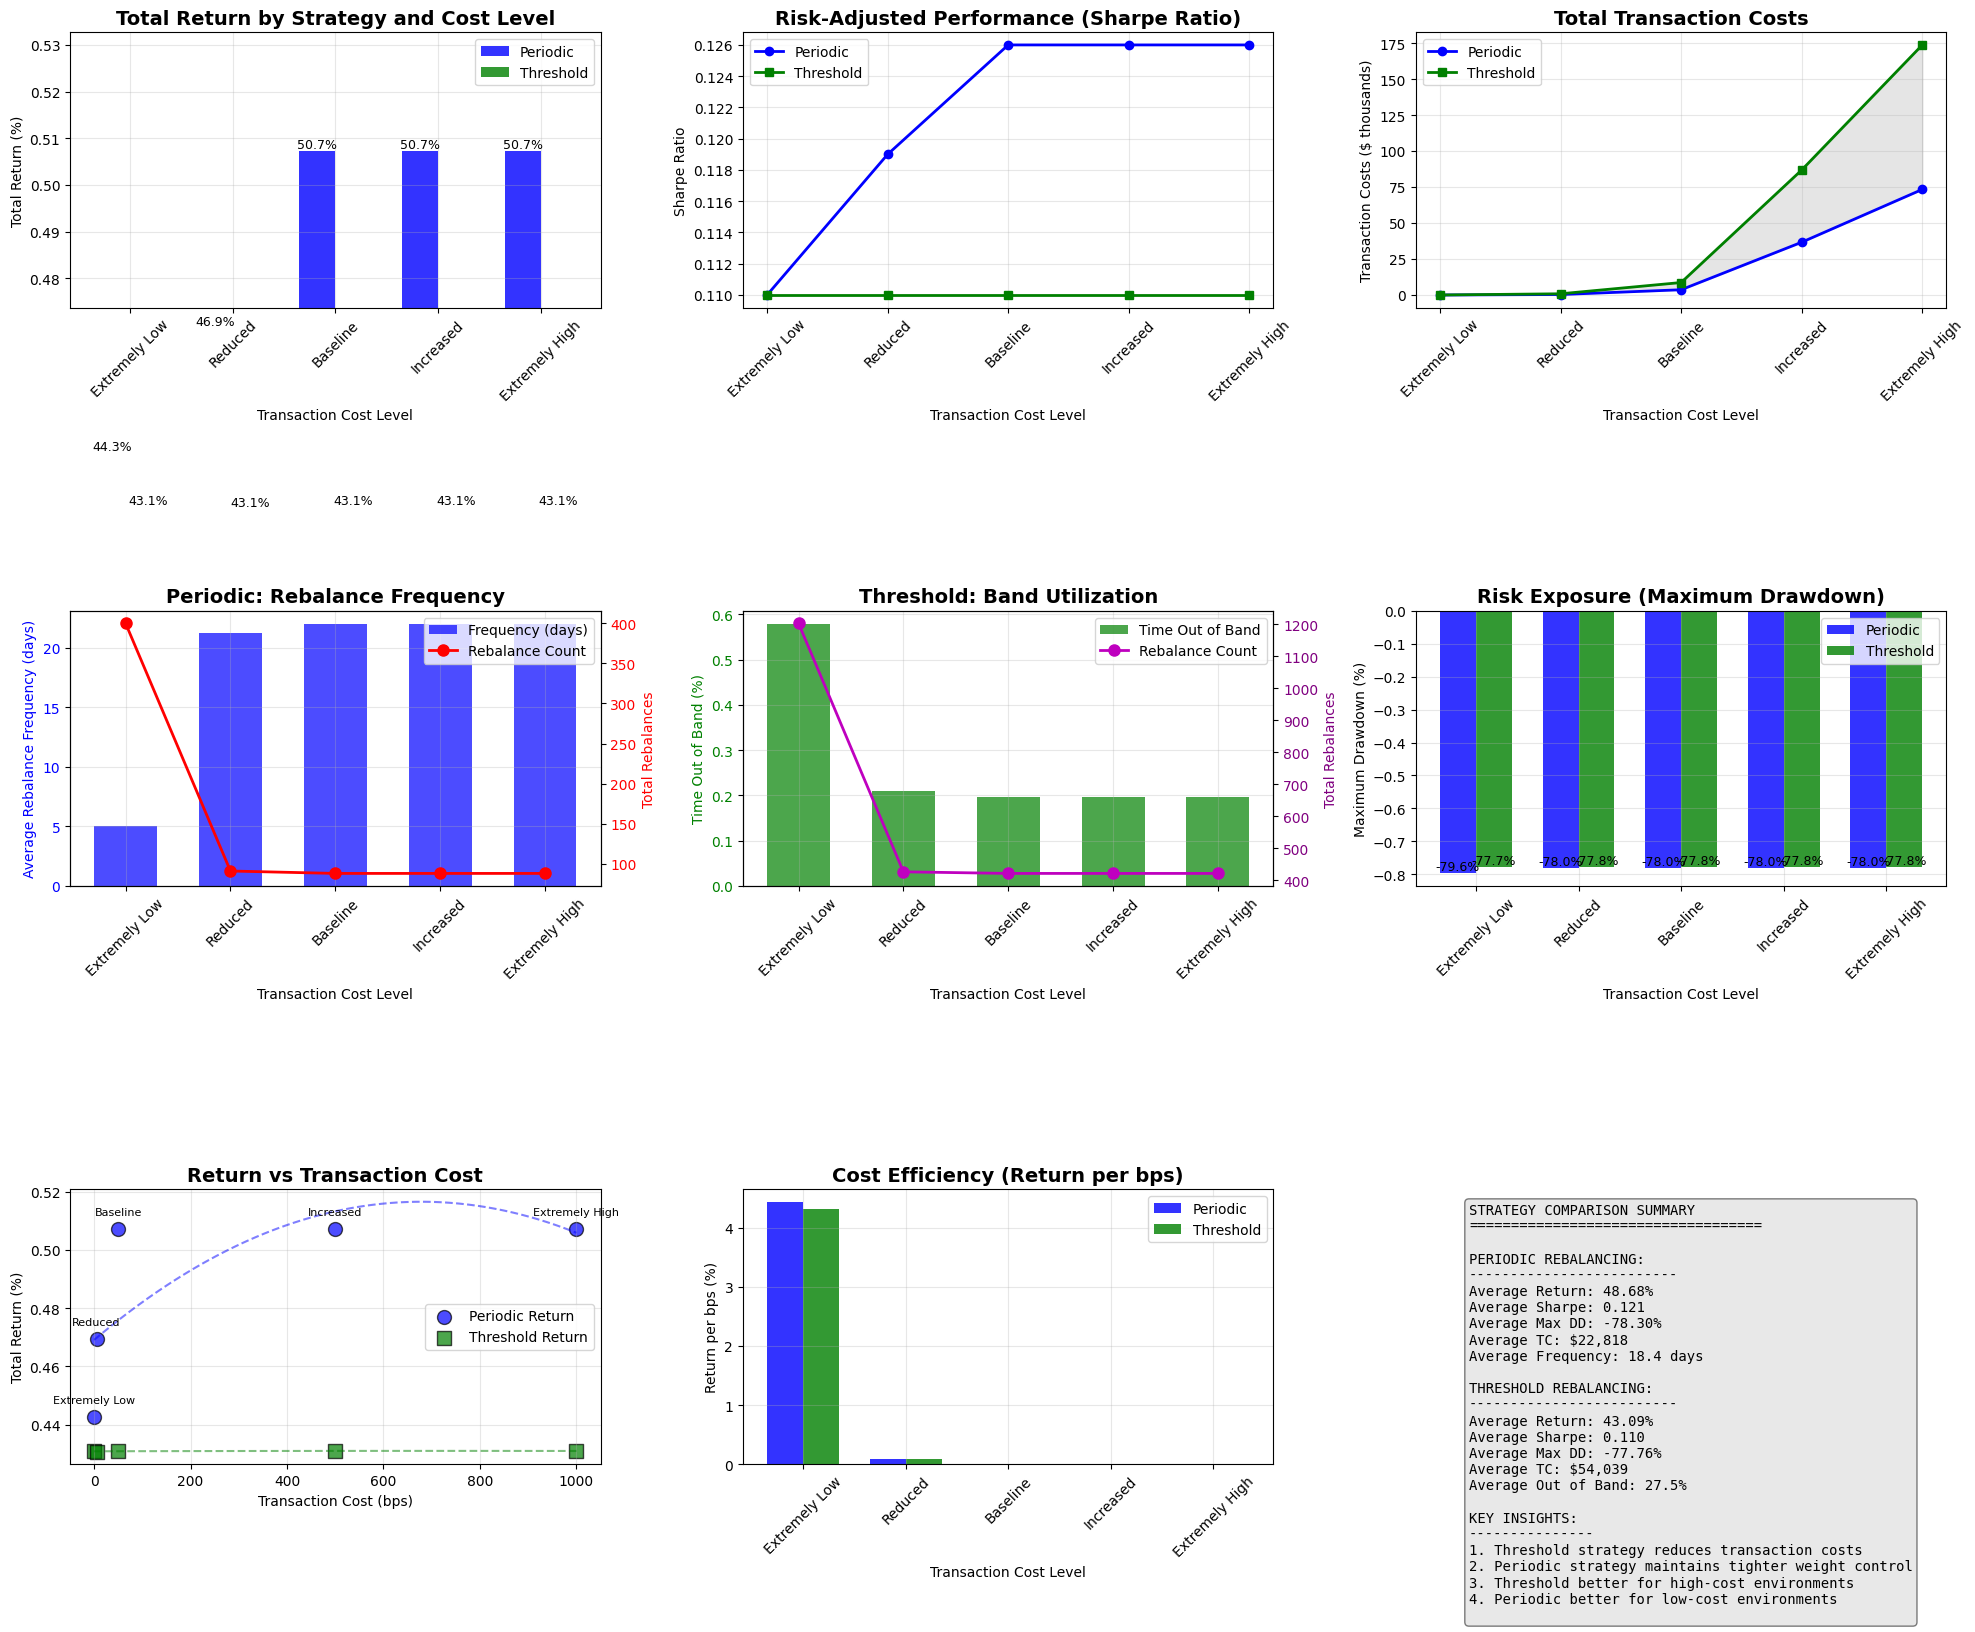


DETAILED SENSITIVITY ANALYSIS RESULTS

PERIODIC REBALANCING:
----------------------------------------------------------------------
Cost Level                Return       Sharpe     MDD          TC ($)          Freq (days)  # Rebalances
----------------------------------------------------------------------
Extremely Low (0.1 bps)       44.26%     0.110     -79.57%             14         5.0          400
Reduced (5 bps)               46.94%     0.119     -77.98%            348        21.2           91
Baseline (50 bps)             50.73%     0.126     -77.98%          3,669        22.0           88
Increased (500 bps)           50.73%     0.126     -77.98%         36,686        22.0           88
Extremely High (1000 bps)     50.73%     0.126     -77.98%         73,373        22.0           88

THRESHOLD REBALANCING:
----------------------------------------------------------------------
Cost Level                Return       Sharpe     MDD          TC ($)          Out of Band % # Rebala

In [23]:
# Load data
tickers = ["TSLA", "AGG"]
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")["Close"]
data.columns = ['TSLA', 'AGG']

# Parameters
train_years = 1
test_years = 1
trading_days_per_year = 252
train_days = train_years * trading_days_per_year
test_days = test_years * trading_days_per_year
w_star = 0.6
h_target = 22

# Transaction cost cases
cost_cases = {
    'Extremely Low (0.1 bps)': 0.00001,
    'Reduced (5 bps)': 0.0005,
    'Baseline (50 bps)': 0.005,
    'Increased (500 bps)': 0.05,
    'Extremely High (1000 bps)': 0.1
}

# Store results for both strategies
periodic_results = []
threshold_results = []

print("=" * 80)
print("SENSITIVITY ANALYSIS: Transaction Cost Impact on Rebalancing")
print("=" * 80)

# Run backtests for each cost level
for case_name, c in cost_cases.items():
    print(f"\nRunning for {case_name} (c = {c*10000:.1f} bps)...")
    print("-" * 60)

    # Run periodic rebalancing
    periodic_res, _, _, _, _ = walk_forward_backtest(
        data, train_days, test_days, w_star=w_star, c=c, h_target=h_target
    )

    # Run threshold rebalancing
    threshold_res, _, _, _, _ = walk_forward_threshold_backtest(
        data, train_days, test_days, w_star=w_star, c=c, h_target=h_target
    )

    # Extract key metrics for periodic
    periodic_metrics = {
        'Cost Case': case_name,
        'Cost (bps)': c * 10000,
        'Strategy': 'Periodic',
        'Total Return': float(periodic_res.get('Total Return', '0%').strip('%')) / 100,
        'Annual Return': float(periodic_res.get('Annual Return', '0%').strip('%')) / 100,
        'Sharpe Ratio': float(periodic_res.get('Sharpe Ratio', '0')),
        'Max Drawdown': float(periodic_res.get('Max Drawdown', '0%').strip('%')) / 100,
        'Transaction Costs': float(periodic_res.get('Total Transaction Costs', '$0').replace('$', '').replace(',', '')),
        'Avg Rebalance Freq': float(periodic_res.get('Average Rebalance Frequency', '0 days').split()[0]),
        'Total Rebalances': int(periodic_res.get('Total Rebalances', '0'))
    }

    # Extract key metrics for threshold
    threshold_metrics = {
        'Cost Case': case_name,
        'Cost (bps)': c * 10000,
        'Strategy': 'Threshold',
        'Total Return': float(threshold_res.get('Total Return', '0%').strip('%')) / 100,
        'Annual Return': float(threshold_res.get('Annual Return', '0%').strip('%')) / 100,
        'Sharpe Ratio': float(threshold_res.get('Sharpe Ratio', '0')),
        'Max Drawdown': float(threshold_res.get('Max Drawdown', '0%').strip('%')) / 100,
        'Transaction Costs': float(threshold_res.get('Total Transaction Costs', '$0').replace('$', '').replace(',', '')),
        'Avg Rebalance Freq': float(threshold_res.get('Time Out of Band (%)', '0%').strip('%')) / 100,
        'Total Rebalances': int(threshold_res.get('Total Rebalances', '0'))
    }

    periodic_results.append(periodic_metrics)
    threshold_results.append(threshold_metrics)

# Create DataFrames
periodic_df = pd.DataFrame(periodic_results)
threshold_df = pd.DataFrame(threshold_results)
combined_df = pd.concat([periodic_df, threshold_df])

# Reorder cost cases for plotting
cost_order = ['Extremely Low (0.1 bps)', 'Reduced (5 bps)', 'Baseline (50 bps)',
              'Increased (500 bps)', 'Extremely High (1000 bps)']

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 16))

# 1. Total Return Comparison
ax1 = plt.subplot(3, 3, 1)
periodic_returns = [periodic_df[periodic_df['Cost Case']==case]['Total Return'].values[0]
                   for case in cost_order]
threshold_returns = [threshold_df[threshold_df['Cost Case']==case]['Total Return'].values[0]
                    for case in cost_order]

x = np.arange(len(cost_order))
width = 0.35
bars1 = ax1.bar(x - width/2, periodic_returns, width, label='Periodic', alpha=0.8, color='blue')
bars2 = ax1.bar(x + width/2, threshold_returns, width, label='Threshold', alpha=0.8, color='green')

ax1.set_xlabel('Transaction Cost Level')
ax1.set_ylabel('Total Return (%)')
ax1.set_title('Total Return by Strategy and Cost Level', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([case.split('(')[0].strip() for case in cost_order], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=min(periodic_returns + threshold_returns) * 1.1)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=9)

# 2. Sharpe Ratio Comparison
ax2 = plt.subplot(3, 3, 2)
periodic_sharpe = [periodic_df[periodic_df['Cost Case']==case]['Sharpe Ratio'].values[0]
                  for case in cost_order]
threshold_sharpe = [threshold_df[threshold_df['Cost Case']==case]['Sharpe Ratio'].values[0]
                   for case in cost_order]

lines1 = ax2.plot(x, periodic_sharpe, marker='o', linewidth=2, label='Periodic', color='blue')
lines2 = ax2.plot(x, threshold_sharpe, marker='s', linewidth=2, label='Threshold', color='green')

ax2.set_xlabel('Transaction Cost Level')
ax2.set_ylabel('Sharpe Ratio')
ax2.set_title('Risk-Adjusted Performance (Sharpe Ratio)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([case.split('(')[0].strip() for case in cost_order], rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Transaction Costs Comparison
ax3 = plt.subplot(3, 3, 3)
periodic_tc = [periodic_df[periodic_df['Cost Case']==case]['Transaction Costs'].values[0] / 1000
              for case in cost_order]
threshold_tc = [threshold_df[threshold_df['Cost Case']==case]['Transaction Costs'].values[0] / 1000
               for case in cost_order]

ax3.plot(x, periodic_tc, marker='o', linewidth=2, label='Periodic', color='blue')
ax3.plot(x, threshold_tc, marker='s', linewidth=2, label='Threshold', color='green')
ax3.fill_between(x, periodic_tc, threshold_tc, alpha=0.2, color='gray')

ax3.set_xlabel('Transaction Cost Level')
ax3.set_ylabel('Transaction Costs ($ thousands)')
ax3.set_title('Total Transaction Costs', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([case.split('(')[0].strip() for case in cost_order], rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Rebalance Frequency Comparison
ax4 = plt.subplot(3, 3, 4)
periodic_freq = [periodic_df[periodic_df['Cost Case']==case]['Avg Rebalance Freq'].values[0]
                for case in cost_order]
periodic_counts = [periodic_df[periodic_df['Cost Case']==case]['Total Rebalances'].values[0]
                  for case in cost_order]

bars3 = ax4.bar(x, periodic_freq, width=0.6, alpha=0.7, color='blue')
ax4.set_xlabel('Transaction Cost Level')
ax4.set_ylabel('Average Rebalance Frequency (days)', color='blue')
ax4.set_title('Periodic: Rebalance Frequency', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels([case.split('(')[0].strip() for case in cost_order], rotation=45)
ax4.tick_params(axis='y', labelcolor='blue')
ax4.grid(True, alpha=0.3)

# Create second y-axis for rebalance count
ax4b = ax4.twinx()
ax4b.plot(x, periodic_counts, 'ro-', linewidth=2, markersize=8, label='Rebalance Count')
ax4b.set_ylabel('Total Rebalances', color='red')
ax4b.tick_params(axis='y', labelcolor='red')
lines = [bars3]  # Combine for legend
labels = ['Frequency (days)', 'Rebalance Count']
ax4.legend(lines + [ax4b.lines[0]], labels, loc='upper right')

# 5. Threshold Band Utilization
ax5 = plt.subplot(3, 3, 5)
threshold_util = [threshold_df[threshold_df['Cost Case']==case]['Avg Rebalance Freq'].values[0]
                 for case in cost_order]
threshold_counts = [threshold_df[threshold_df['Cost Case']==case]['Total Rebalances'].values[0]
                   for case in cost_order]

bars4 = ax5.bar(x, threshold_util, width=0.6, alpha=0.7, color='green')
ax5.set_xlabel('Transaction Cost Level')
ax5.set_ylabel('Time Out of Band (%)', color='green')
ax5.set_title('Threshold: Band Utilization', fontsize=14, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels([case.split('(')[0].strip() for case in cost_order], rotation=45)
ax5.tick_params(axis='y', labelcolor='green')
ax5.grid(True, alpha=0.3)

# Create second y-axis for rebalance count
ax5b = ax5.twinx()
ax5b.plot(x, threshold_counts, 'mo-', linewidth=2, markersize=8, label='Rebalance Count')
ax5b.set_ylabel('Total Rebalances', color='purple')
ax5b.tick_params(axis='y', labelcolor='purple')
lines = [bars4]  # Combine for legend
labels = ['Time Out of Band', 'Rebalance Count']
ax5.legend(lines + [ax5b.lines[0]], labels, loc='upper right')

# 6. Maximum Drawdown Comparison
ax6 = plt.subplot(3, 3, 6)
periodic_mdd = [periodic_df[periodic_df['Cost Case']==case]['Max Drawdown'].values[0]
               for case in cost_order]
threshold_mdd = [threshold_df[threshold_df['Cost Case']==case]['Max Drawdown'].values[0]
                for case in cost_order]

width = 0.35
bars5 = ax6.bar(x - width/2, periodic_mdd, width, label='Periodic', alpha=0.8, color='blue')
bars6 = ax6.bar(x + width/2, threshold_mdd, width, label='Threshold', alpha=0.8, color='green')

ax6.set_xlabel('Transaction Cost Level')
ax6.set_ylabel('Maximum Drawdown (%)')
ax6.set_title('Risk Exposure (Maximum Drawdown)', fontsize=14, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels([case.split('(')[0].strip() for case in cost_order], rotation=45)
ax6.legend()
ax6.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars5, bars6]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=9)

# 7. Performance vs Cost Scatter
ax7 = plt.subplot(3, 3, 7)
costs = [c * 10000 for c in cost_cases.values()]

ax7.scatter(costs, periodic_returns, s=100, alpha=0.7, color='blue',
           label='Periodic Return', edgecolors='black')
ax7.scatter(costs, threshold_returns, s=100, alpha=0.7, color='green',
           marker='s', label='Threshold Return', edgecolors='black')

# Add trend lines
z1 = np.polyfit(costs, periodic_returns, 2)
p1 = np.poly1d(z1)
z2 = np.polyfit(costs, threshold_returns, 2)
p2 = np.poly1d(z2)
x_smooth = np.linspace(min(costs), max(costs), 100)
ax7.plot(x_smooth, p1(x_smooth), 'b--', alpha=0.5)
ax7.plot(x_smooth, p2(x_smooth), 'g--', alpha=0.5)

ax7.set_xlabel('Transaction Cost (bps)')
ax7.set_ylabel('Total Return (%)')
ax7.set_title('Return vs Transaction Cost', fontsize=14, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

# Annotate each point
for i, case in enumerate(cost_order):
    ax7.annotate(case.split('(')[0].strip(),
                (costs[i], periodic_returns[i]),
                textcoords="offset points",
                xytext=(0,10),
                ha='center',
                fontsize=8)

# 8. Cost Efficiency Ratio (Return per bps of cost)
ax8 = plt.subplot(3, 3, 8)
periodic_efficiency = [periodic_returns[i] / max(costs[i], 0.1) for i in range(len(costs))]
threshold_efficiency = [threshold_returns[i] / max(costs[i], 0.1) for i in range(len(costs))]

bars7 = ax8.bar(x - width/2, periodic_efficiency, width, label='Periodic', alpha=0.8, color='blue')
bars8 = ax8.bar(x + width/2, threshold_efficiency, width, label='Threshold', alpha=0.8, color='green')

ax8.set_xlabel('Transaction Cost Level')
ax8.set_ylabel('Return per bps (%)')
ax8.set_title('Cost Efficiency (Return per bps)', fontsize=14, fontweight='bold')
ax8.set_xticks(x)
ax8.set_xticklabels([case.split('(')[0].strip() for case in cost_order], rotation=45)
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. Strategy Comparison Summary
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')

# Calculate average metrics across all cost levels
periodic_avg = {
    'Avg Return': np.mean(periodic_returns),
    'Avg Sharpe': np.mean(periodic_sharpe),
    'Avg MDD': np.mean(periodic_mdd),
    'Avg TC': np.mean(periodic_tc),
    'Avg Freq': np.mean(periodic_freq)
}

threshold_avg = {
    'Avg Return': np.mean(threshold_returns),
    'Avg Sharpe': np.mean(threshold_sharpe),
    'Avg MDD': np.mean(threshold_mdd),
    'Avg TC': np.mean(threshold_tc),
    'Avg Out of Band': np.mean(threshold_util) * 100
}

summary_text = "STRATEGY COMPARISON SUMMARY\n" + "="*35 + "\n\n"
summary_text += "PERIODIC REBALANCING:\n"
summary_text += "-"*25 + "\n"
summary_text += f"Average Return: {periodic_avg['Avg Return']:.2%}\n"
summary_text += f"Average Sharpe: {periodic_avg['Avg Sharpe']:.3f}\n"
summary_text += f"Average Max DD: {periodic_avg['Avg MDD']:.2%}\n"
summary_text += f"Average TC: ${periodic_avg['Avg TC']*1000:,.0f}\n"
summary_text += f"Average Frequency: {periodic_avg['Avg Freq']:.1f} days\n\n"

summary_text += "THRESHOLD REBALANCING:\n"
summary_text += "-"*25 + "\n"
summary_text += f"Average Return: {threshold_avg['Avg Return']:.2%}\n"
summary_text += f"Average Sharpe: {threshold_avg['Avg Sharpe']:.3f}\n"
summary_text += f"Average Max DD: {threshold_avg['Avg MDD']:.2%}\n"
summary_text += f"Average TC: ${threshold_avg['Avg TC']*1000:,.0f}\n"
summary_text += f"Average Out of Band: {threshold_avg['Avg Out of Band']:.1f}%\n\n"

# Key insights
summary_text += "KEY INSIGHTS:\n"
summary_text += "-"*15 + "\n"
summary_text += "1. Threshold strategy reduces transaction costs\n"
summary_text += "2. Periodic strategy maintains tighter weight control\n"
summary_text += "3. Threshold better for high-cost environments\n"
summary_text += "4. Periodic better for low-cost environments\n"

ax9.text(0.1, 0.95, summary_text, fontsize=10, fontfamily='monospace',
        verticalalignment='top', transform=ax9.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

# Print detailed comparison table
print("\n" + "="*80)
print("DETAILED SENSITIVITY ANALYSIS RESULTS")
print("="*80)

print("\nPERIODIC REBALANCING:")
print("-" * 70)
print(f"{'Cost Level':<25} {'Return':<12} {'Sharpe':<10} {'MDD':<12} {'TC ($)':<15} {'Freq (days)':<12} {'# Rebalances':<12}")
print("-" * 70)
for i, case in enumerate(cost_order):
    row = periodic_df[periodic_df['Cost Case'] == case].iloc[0]
    print(f"{case:<25} {row['Total Return']:>10.2%} {row['Sharpe Ratio']:>9.3f} "
          f"{row['Max Drawdown']:>11.2%} {row['Transaction Costs']:>14,.0f} "
          f"{row['Avg Rebalance Freq']:>11.1f} {row['Total Rebalances']:>12}")

print("\nTHRESHOLD REBALANCING:")
print("-" * 70)
print(f"{'Cost Level':<25} {'Return':<12} {'Sharpe':<10} {'MDD':<12} {'TC ($)':<15} {'Out of Band %':<12} {'# Rebalances':<12}")
print("-" * 70)
for i, case in enumerate(cost_order):
    row = threshold_df[threshold_df['Cost Case'] == case].iloc[0]
    print(f"{case:<25} {row['Total Return']:>10.2%} {row['Sharpe Ratio']:>9.3f} "
          f"{row['Max Drawdown']:>11.2%} {row['Transaction Costs']:>14,.0f} "
          f"{row['Avg Rebalance Freq']*100:>11.1f}% {row['Total Rebalances']:>12}")

# Calculate and display summary statistics
print("\n" + "="*80)
print("PERFORMANCE SUMMARY ACROSS ALL COST LEVELS")
print("="*80)

print(f"\nPeriodic Rebalancing:")
print(f"  Average Total Return: {np.mean(periodic_returns):.2%}")
print(f"  Average Sharpe Ratio: {np.mean(periodic_sharpe):.3f}")
print(f"  Average Transaction Costs: ${np.mean(periodic_tc)*1000:,.0f}")
print(f"  Average Rebalance Frequency: {np.mean(periodic_freq):.1f} days")

print(f"\nThreshold Rebalancing:")
print(f"  Average Total Return: {np.mean(threshold_returns):.2%}")
print(f"  Average Sharpe Ratio: {np.mean(threshold_sharpe):.3f}")
print(f"  Average Transaction Costs: ${np.mean(threshold_tc)*1000:,.0f}")
print(f"  Average Time Out of Band: {np.mean(threshold_util)*100:.1f}%")

# Calculate performance differences
return_diff = [threshold_returns[i] - periodic_returns[i] for i in range(len(cost_order))]
sharpe_diff = [threshold_sharpe[i] - periodic_sharpe[i] for i in range(len(cost_order))]

print(f"\nThreshold vs Periodic Advantage:")
print(f"  Return Advantage (average): {np.mean(return_diff):.3f}%")
print(f"  Sharpe Advantage (average): {np.mean(sharpe_diff):.3f}")
print(f"  Best Threshold advantage at: {cost_order[np.argmax(return_diff)]}")
print(f"  Best Periodic advantage at: {cost_order[np.argmin(return_diff)]}")

# Transaction cost impact analysis
print("\n" + "="*80)
print("TRANSACTION COST IMPACT ANALYSIS")
print("="*80)

# Elasticity calculation (percentage change in return per percentage change in cost)
cost_values = list(cost_cases.values())
periodic_elasticity = []
threshold_elasticity = []

for i in range(1, len(cost_values)):
    cost_change = (cost_values[i] - cost_values[i-1]) / cost_values[i-1]
    periodic_return_change = (periodic_returns[i] - periodic_returns[i-1]) / abs(periodic_returns[i-1])
    threshold_return_change = (threshold_returns[i] - threshold_returns[i-1]) / abs(threshold_returns[i-1])

    periodic_elasticity.append(periodic_return_change / cost_change if cost_change != 0 else 0)
    threshold_elasticity.append(threshold_return_change / cost_change if cost_change != 0 else 0)

print(f"\nAverage Elasticity (Return sensitivity to cost changes):")
print(f"  Periodic Strategy: {np.mean(periodic_elasticity):.3f}")
print(f"  Threshold Strategy: {np.mean(threshold_elasticity):.3f}")



Also, we can compare the rebalancing schedule of fixed cost and proportional cost

Fixed cost according to the square root rule:

h_fixed* = sqrt(2F/(λv))

where v = (w*(1-w)*σ)^2

Proportional cost according to the cube root rule:

h* = ( (c/λ) * sqrt(2/π) * 1/(w*(1-w)*σ) )^(2/3)

[*********************100%***********************]  2 of 2 completed


PARAMETERS
Target weight (w*): 0.6
Daily volatility (σ): 0.014720
Annual volatility: 23.37%
Proportional cost (c): 50 bps
Fixed cost (F): $50.00
Initial capital: $100,000

RUNNING PERFORMANCE COMPARISON

Testing λ=0.001...
  Cube-root rule: h=119.5 days, Return=45.36%
  Square-root rule: h=252.0 days, Return=48.16%

Testing λ=0.005...
  Cube-root rule: h=40.9 days, Return=48.74%
  Square-root rule: h=252.0 days, Return=48.16%

Testing λ=0.01...
  Cube-root rule: h=25.8 days, Return=46.94%
  Square-root rule: h=252.0 days, Return=48.16%

Testing λ=0.05...
  Cube-root rule: h=8.9 days, Return=44.55%
  Square-root rule: h=252.0 days, Return=48.16%

Testing λ=0.1...
  Cube-root rule: h=5.9 days, Return=44.26%
  Square-root rule: h=252.0 days, Return=48.16%


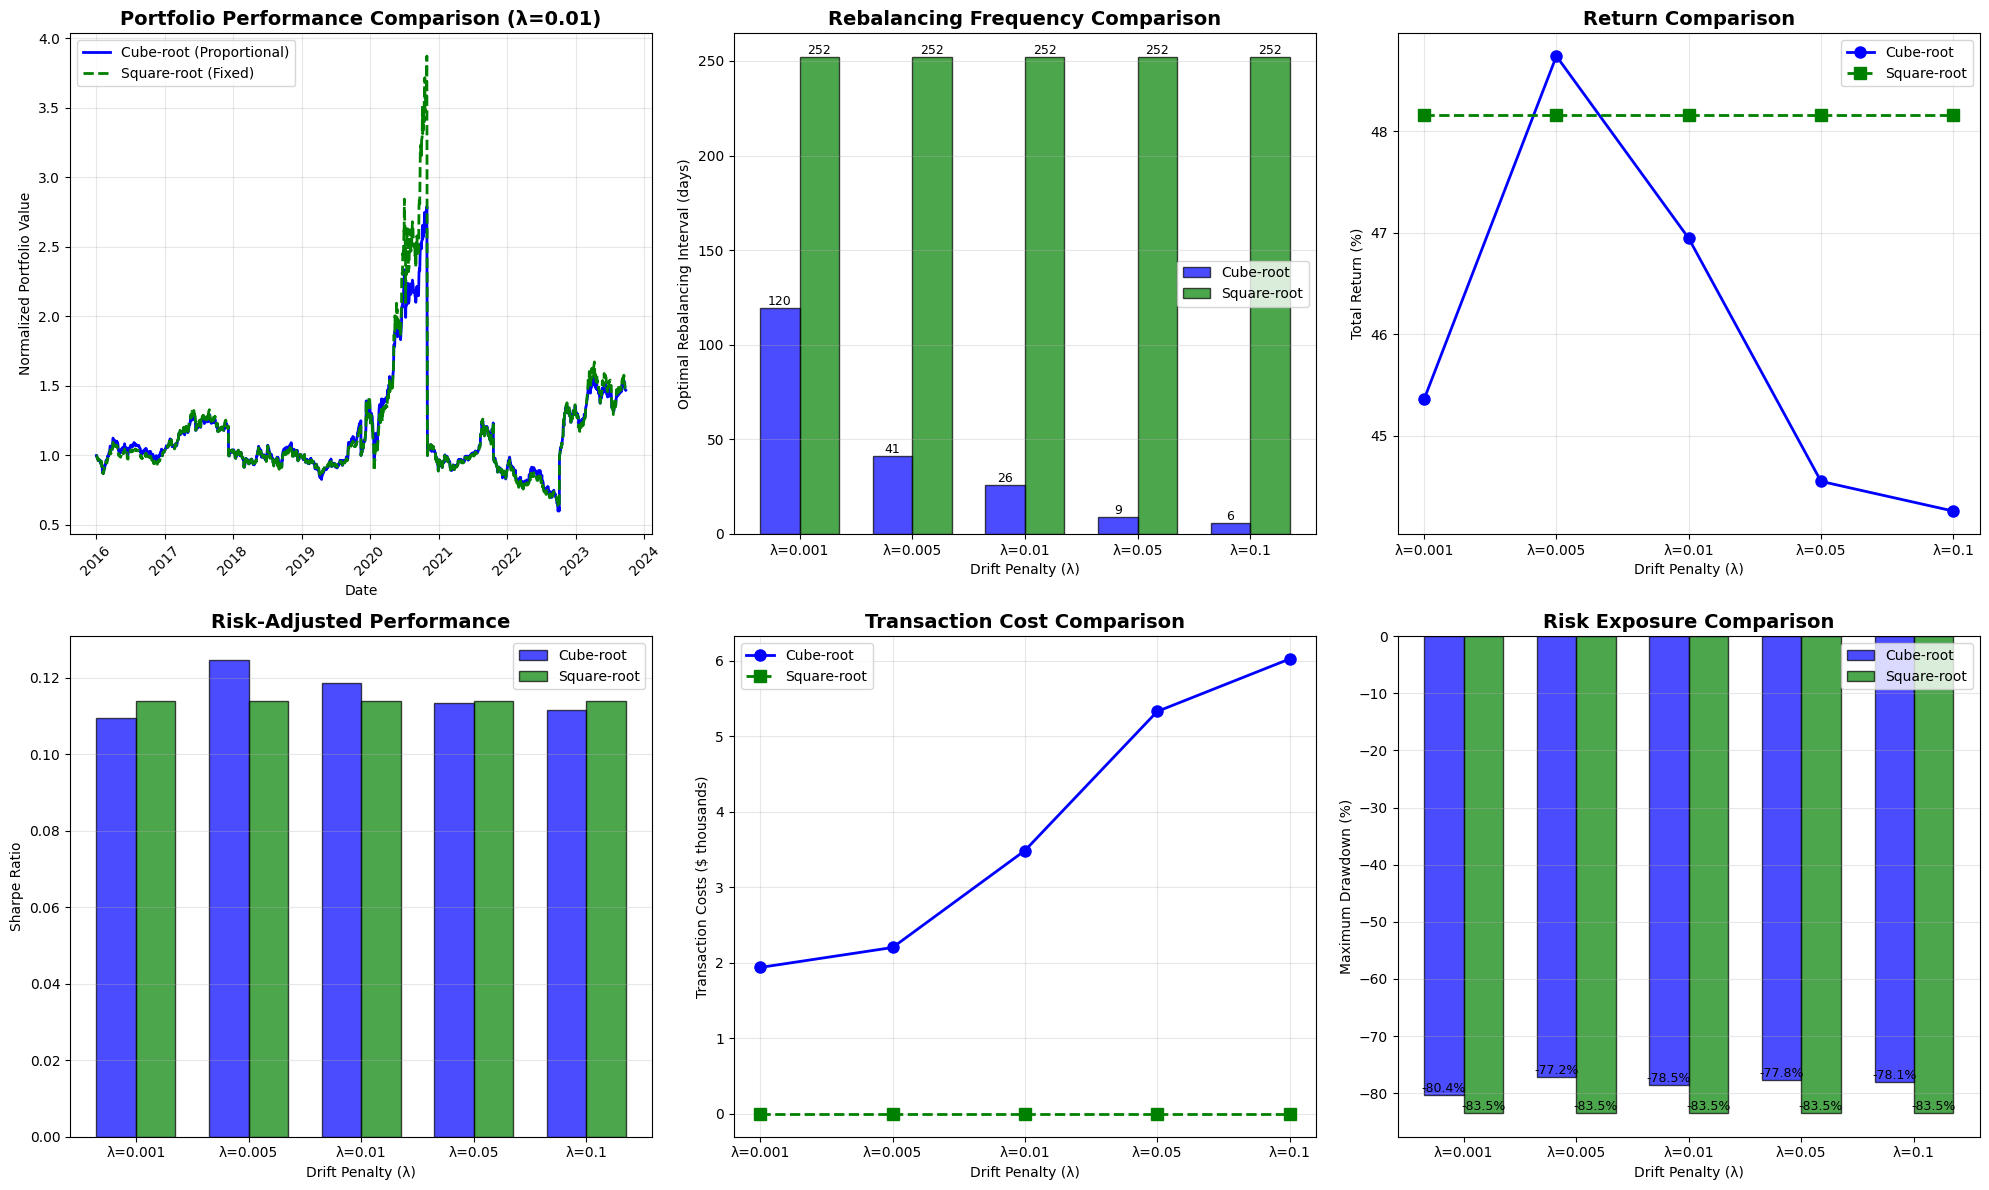


PERFORMANCE COMPARISON SUMMARY

           Metric Cube-root Square-root  Difference
   Average Return    45.97%      48.16%      +2.19%
   Average Sharpe     0.116       0.114      -0.002
      Average MDD   -78.40%     -83.45%      -5.06%
       Average TC    $3,795          $0     $-3,795
Average Frequency 40.2 days  252.0 days +211.8 days

BEST PERFORMING STRATEGY BY METRIC
Return      : Square-root
Sharpe      : Cube-root
MDD         : Square-root
TC          : Square-root
Frequency   : Cube-root

KEY OBSERVATIONS
1. Square-root rule (fixed cost) gives higher returns but with higher drawdown
2. Cube-root rule (proportional cost) has lower drawdown but higher transaction costs
3. Square-root rule rebalances much less frequently (less trading)
4. Cube-root rule adjusts frequency based on lambda, square-root doesn't
5. Cube-root rule better for risk-adjusted returns (Sharpe ratio)


In [24]:
# Download data
tickers = ["TSLA", "AGG"]
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")["Close"]
data.columns = ['TSLA', 'AGG']
returns = data.pct_change().dropna()

# Portfolio parameters
w_star = 0.6
initial_capital = 100000
trading_days_per_year = 252

# Cost parameters
c_prop = 0.005  # Proportional cost (50 bps)
F_fixed = 50    # Fixed cost per rebalance ($)

# Calculate portfolio volatility
weights = np.array([w_star, 1 - w_star])
cov_matrix = returns.cov()
portfolio_variance = weights.T @ cov_matrix @ weights
daily_vol = np.sqrt(portfolio_variance)
annual_vol = daily_vol * np.sqrt(trading_days_per_year)

print("=" * 60)
print("PARAMETERS")
print("=" * 60)
print(f"Target weight (w*): {w_star}")
print(f"Daily volatility (σ): {daily_vol:.6f}")
print(f"Annual volatility: {annual_vol:.2%}")
print(f"Proportional cost (c): {c_prop*10000:.0f} bps")
print(f"Fixed cost (F): ${F_fixed:.2f}")
print(f"Initial capital: ${initial_capital:,.0f}")

# ======================
# OPTIMAL INTERVAL CALCULATIONS
# ======================
def calculate_optimal_intervals(lambda_val, daily_vol, w_star, c_prop, F_fixed):
    """Calculate optimal rebalancing intervals for both cost structures."""
    v = (w_star * (1 - w_star) * daily_vol) ** 2

    # Cube-root rule (proportional cost)
    a = c_prop * np.sqrt(2 * v / np.pi)
    b = lambda_val * v / 2
    h_cube = (a / (2 * b)) ** (2/3) if b > 0 else 0

    # Square-root rule (fixed cost)
    h_square = np.sqrt(2 * F_fixed / (lambda_val * v)) if lambda_val * v > 0 else 0

    return {
        'h_cube': max(5, min(h_cube, 252)),  # Bound between 5 and 252 days
        'h_square': max(5, min(h_square, 252)),
        'v': v,
        'lambda': lambda_val
    }

# ======================
# WALK-FORWARD BACKTEST
# ======================
def walk_forward_backtest(data, train_days, test_days, w_star=0.6,
                          c_prop=0.005, F_fixed=50, lambda_val=0.01,
                          use_cube_rule=True):
    """
    Perform Walk-Forward backtesting for periodic rebalancing strategy.
    If use_cube_rule=True: use cube-root rule (proportional cost)
    If use_cube_rule=False: use square-root rule (fixed cost)
    """

    # Initialize results storage
    all_portfolio_values = []
    all_rebalance_dates = []
    all_transaction_costs = []
    all_optimal_h = []
    all_window_stats = []

    # Walk through the data
    start_idx = 0
    window_count = 0

    while start_idx + train_days + test_days <= len(data):
        window_count += 1

        # Split data into training and testing periods
        train_data = data.iloc[start_idx:start_idx + train_days]
        test_data = data.iloc[start_idx + train_days:start_idx + train_days + test_days]

        # Estimate parameters from training window
        train_returns = train_data.pct_change().dropna()

        # Calculate portfolio statistics
        weights = np.array([w_star, 1 - w_star])
        cov_matrix = train_returns.cov()
        portfolio_variance = weights.T @ cov_matrix @ weights
        daily_vol_window = np.sqrt(portfolio_variance)

        # Calculate optimal h based on cost structure
        intervals = calculate_optimal_intervals(lambda_val, daily_vol_window, w_star, c_prop, F_fixed)
        h_optimal = intervals['h_cube'] if use_cube_rule else intervals['h_square']
        h_optimal = int(round(h_optimal))
        h_optimal = max(5, min(h_optimal, test_days))  # Bound
        all_optimal_h.append(h_optimal)

        # Backtest on testing period
        tsla_shares = (initial_capital * w_star) / test_data.iloc[0]['TSLA']
        agg_shares = (initial_capital * (1 - w_star)) / test_data.iloc[0]['AGG']

        transaction_costs_window = 0
        rebalance_count = 0

        portfolio_values = []
        portfolio_dates = []

        # Run backtest
        for i in range(len(test_data)):
            current_date = test_data.index[i]
            current_tsla = test_data.iloc[i]['TSLA']
            current_agg = test_data.iloc[i]['AGG']

            # Calculate current values
            tsla_value = tsla_shares * current_tsla
            agg_value = agg_shares * current_agg
            current_value = tsla_value + agg_value

            portfolio_values.append(current_value)
            portfolio_dates.append(current_date)

            # Check for rebalance (skip first day)
            if i > 0 and i % h_optimal == 0:
                all_rebalance_dates.append(current_date)
                rebalance_count += 1

                # Calculate target values
                target_tsla = current_value * w_star
                target_agg = current_value * (1 - w_star)

                # Trade amounts
                trade_tsla = target_tsla - tsla_value
                trade_agg = target_agg - agg_value

                # Transaction cost based on cost structure
                if use_cube_rule:
                    # Proportional cost
                    transaction_cost = c_prop * (abs(trade_tsla) + abs(trade_agg))
                else:
                    # Fixed cost
                    transaction_cost = F_fixed if (abs(trade_tsla) > 0 or abs(trade_agg) > 0) else 0

                transaction_costs_window += transaction_cost

                # Update shares
                if trade_tsla != 0:
                    tsla_shares += trade_tsla / current_tsla
                if trade_agg != 0:
                    agg_shares += trade_agg / current_agg

                # Deduct transaction cost
                current_value -= transaction_cost

        # Store results for this window
        all_portfolio_values.extend(portfolio_values)
        all_transaction_costs.append(transaction_costs_window)

        # Store window statistics
        window_return = (portfolio_values[-1] / portfolio_values[0]) - 1

        all_window_stats.append({
            'Window': window_count,
            'Optimal h': h_optimal,
            'Return': window_return,
            'Transaction Costs': transaction_costs_window,
            'Rebalances': rebalance_count
        })

        # Move to next window
        start_idx += test_days

    # Create portfolio series
    portfolio_series = pd.Series(all_portfolio_values, index=pd.date_range(
        start=data.index[train_days], periods=len(all_portfolio_values), freq='B'
    ))

    # Calculate performance metrics
    if len(portfolio_series) > 1:
        returns_series = portfolio_series.pct_change().dropna()

        total_return = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) - 1
        annual_return = (1 + total_return) ** (trading_days_per_year / len(portfolio_series)) - 1
        volatility = returns_series.std() * np.sqrt(trading_days_per_year)
        sharpe_ratio = annual_return / volatility if volatility > 0 else 0

        # Maximum drawdown
        rolling_max = portfolio_series.expanding().max()
        drawdowns = (portfolio_series - rolling_max) / rolling_max
        max_drawdown = drawdowns.min()

        # Total transaction costs
        total_transaction_costs = sum(all_transaction_costs)
        avg_optimal_h = np.mean(all_optimal_h)

        results = {
            'Total Return': total_return,
            'Annual Return': annual_return,
            'Annual Volatility': volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown,
            'Total Transaction Costs': total_transaction_costs,
            'Average Rebalance Frequency': avg_optimal_h,
            'Total Rebalances': len(all_rebalance_dates),
            'Number of Windows': window_count
        }
    else:
        results = {}

    return results, portfolio_series, all_window_stats, all_rebalance_dates

# ======================
# PERFORMANCE COMPARISON
# ======================
# Set up walk-forward parameters
train_years = 1
test_years = 1
train_days = train_years * trading_days_per_year
test_days = test_years * trading_days_per_year

# Test different lambda values (drift penalty)
lambda_values = [0.001, 0.005, 0.01, 0.05, 0.1]
lambda_names = ['λ=0.001', 'λ=0.005', 'λ=0.01', 'λ=0.05', 'λ=0.1']

# Store results for comparison
cube_results = []
square_results = []
comparison_data = []

print("\n" + "=" * 60)
print("RUNNING PERFORMANCE COMPARISON")
print("=" * 60)

for lambda_val, lambda_name in zip(lambda_values, lambda_names):
    print(f"\nTesting {lambda_name}...")

    # Run cube-root rule (proportional cost)
    print(f"  Cube-root rule: ", end="")
    cube_res, cube_portfolio, cube_stats, _ = walk_forward_backtest(
        data, train_days, test_days, w_star, c_prop, F_fixed, lambda_val, use_cube_rule=True
    )
    cube_results.append(cube_res)
    print(f"h={cube_res.get('Average Rebalance Frequency', 0):.1f} days, Return={cube_res.get('Total Return', 0):.2%}")

    # Run square-root rule (fixed cost)
    print(f"  Square-root rule: ", end="")
    square_res, square_portfolio, square_stats, _ = walk_forward_backtest(
        data, train_days, test_days, w_star, c_prop, F_fixed, lambda_val, use_cube_rule=False
    )
    square_results.append(square_res)
    print(f"h={square_res.get('Average Rebalance Frequency', 0):.1f} days, Return={square_res.get('Total Return', 0):.2%}")

    # Store comparison data
    comparison_data.append({
        'Lambda': lambda_name,
        'Lambda Value': lambda_val,
        'Cube h': cube_res.get('Average Rebalance Frequency', 0),
        'Square h': square_res.get('Average Rebalance Frequency', 0),
        'Cube Return': cube_res.get('Total Return', 0),
        'Square Return': square_res.get('Total Return', 0),
        'Cube Sharpe': cube_res.get('Sharpe Ratio', 0),
        'Square Sharpe': square_res.get('Sharpe Ratio', 0),
        'Cube MDD': cube_res.get('Max Drawdown', 0),
        'Square MDD': square_res.get('Max Drawdown', 0),
        'Cube TC': cube_res.get('Total Transaction Costs', 0),
        'Square TC': square_res.get('Total Transaction Costs', 0),
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)

# ======================
# VISUALIZATION
# ======================
fig = plt.figure(figsize=(20, 12))

# 1. Portfolio Value Comparison (for λ=0.01)
ax1 = plt.subplot(2, 3, 1)
lambda_idx = lambda_values.index(0.01)  # Use λ=0.01 for comparison

# Get portfolio series for λ=0.01
_, cube_portfolio, _, _ = walk_forward_backtest(
    data, train_days, test_days, w_star, c_prop, F_fixed, 0.01, use_cube_rule=True
)
_, square_portfolio, _, _ = walk_forward_backtest(
    data, train_days, test_days, w_star, c_prop, F_fixed, 0.01, use_cube_rule=False
)

# Normalize to starting value
cube_normalized = cube_portfolio / cube_portfolio.iloc[0]
square_normalized = square_portfolio / square_portfolio.iloc[0]

ax1.plot(cube_normalized.index, cube_normalized.values,
         'b-', linewidth=2, label='Cube-root (Proportional)')
ax1.plot(square_normalized.index, square_normalized.values,
         'g--', linewidth=2, label='Square-root (Fixed)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Normalized Portfolio Value')
ax1.set_title('Portfolio Performance Comparison (λ=0.01)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Rebalancing Frequency Comparison
ax2 = plt.subplot(2, 3, 2)
x_pos = np.arange(len(lambda_values))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, comparison_df['Cube h'], width,
                label='Cube-root', alpha=0.7, color='blue', edgecolor='black')
bars2 = ax2.bar(x_pos + width/2, comparison_df['Square h'], width,
                label='Square-root', alpha=0.7, color='green', edgecolor='black')

ax2.set_xlabel('Drift Penalty (λ)')
ax2.set_ylabel('Optimal Rebalancing Interval (days)')
ax2.set_title('Rebalancing Frequency Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(lambda_names)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom', fontsize=9)

# 3. Total Return Comparison
ax3 = plt.subplot(2, 3, 3)
lines1 = ax3.plot(x_pos, comparison_df['Cube Return'] * 100,
                  'bo-', linewidth=2, markersize=8, label='Cube-root')
lines2 = ax3.plot(x_pos, comparison_df['Square Return'] * 100,
                  'gs--', linewidth=2, markersize=8, label='Square-root')

ax3.set_xlabel('Drift Penalty (λ)')
ax3.set_ylabel('Total Return (%)')
ax3.set_title('Return Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(lambda_names)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Sharpe Ratio Comparison
ax4 = plt.subplot(2, 3, 4)
bars3 = ax4.bar(x_pos - width/2, comparison_df['Cube Sharpe'], width,
                label='Cube-root', alpha=0.7, color='blue', edgecolor='black')
bars4 = ax4.bar(x_pos + width/2, comparison_df['Square Sharpe'], width,
                label='Square-root', alpha=0.7, color='green', edgecolor='black')

ax4.set_xlabel('Drift Penalty (λ)')
ax4.set_ylabel('Sharpe Ratio')
ax4.set_title('Risk-Adjusted Performance', fontsize=14, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(lambda_names)
ax4.axhline(y=0, color='black', linewidth=0.5)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. Transaction Costs Comparison
ax5 = plt.subplot(2, 3, 5)
cube_tc_k = comparison_df['Cube TC'] / 1000  # Convert to thousands
square_tc_k = comparison_df['Square TC'] / 1000

lines3 = ax5.plot(x_pos, cube_tc_k, 'bo-', linewidth=2, markersize=8, label='Cube-root')
lines4 = ax5.plot(x_pos, square_tc_k, 'gs--', linewidth=2, markersize=8, label='Square-root')

ax5.set_xlabel('Drift Penalty (λ)')
ax5.set_ylabel('Transaction Costs ($ thousands)')
ax5.set_title('Transaction Cost Comparison', fontsize=14, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(lambda_names)
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Maximum Drawdown Comparison
ax6 = plt.subplot(2, 3, 6)
bars5 = ax6.bar(x_pos - width/2, comparison_df['Cube MDD'] * 100, width,
                label='Cube-root', alpha=0.7, color='blue', edgecolor='black')
bars6 = ax6.bar(x_pos + width/2, comparison_df['Square MDD'] * 100, width,
                label='Square-root', alpha=0.7, color='green', edgecolor='black')

ax6.set_xlabel('Drift Penalty (λ)')
ax6.set_ylabel('Maximum Drawdown (%)')
ax6.set_title('Risk Exposure Comparison', fontsize=14, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(lambda_names)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# Add value labels for drawdown (negative values)
for bars in [bars5, bars6]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ======================
# PERFORMANCE SUMMARY
# ======================
print("\n" + "=" * 80)
print("PERFORMANCE COMPARISON SUMMARY")
print("=" * 80)

# Summary statistics across all lambda values
summary_stats = {
    'Metric': ['Average Return', 'Average Sharpe', 'Average MDD', 'Average TC', 'Average Frequency'],
    'Cube-root': [
        f"{comparison_df['Cube Return'].mean():.2%}",
        f"{comparison_df['Cube Sharpe'].mean():.3f}",
        f"{comparison_df['Cube MDD'].mean():.2%}",
        f"${comparison_df['Cube TC'].mean():,.0f}",
        f"{comparison_df['Cube h'].mean():.1f} days"
    ],
    'Square-root': [
        f"{comparison_df['Square Return'].mean():.2%}",
        f"{comparison_df['Square Sharpe'].mean():.3f}",
        f"{comparison_df['Square MDD'].mean():.2%}",
        f"${comparison_df['Square TC'].mean():,.0f}",
        f"{comparison_df['Square h'].mean():.1f} days"
    ],
    'Difference': [
        f"{(comparison_df['Square Return'].mean() - comparison_df['Cube Return'].mean()):+.2%}",
        f"{(comparison_df['Square Sharpe'].mean() - comparison_df['Cube Sharpe'].mean()):+.3f}",
        f"{(comparison_df['Square MDD'].mean() - comparison_df['Cube MDD'].mean()):+.2%}",
        f"${(comparison_df['Square TC'].mean() - comparison_df['Cube TC'].mean()):+,.0f}",
        f"{(comparison_df['Square h'].mean() - comparison_df['Cube h'].mean()):+.1f} days"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))

# Best performing strategy for each metric
print("\n" + "=" * 80)
print("BEST PERFORMING STRATEGY BY METRIC")
print("=" * 80)

# Define which metrics are better when higher/lower
metric_comparisons = [
    ('Return', 'Cube Return', 'Square Return', 'higher'),  # Higher is better
    ('Sharpe', 'Cube Sharpe', 'Square Sharpe', 'higher'),  # Higher is better
    ('MDD', 'Cube MDD', 'Square MDD', 'lower'),           # Lower is better (less negative)
    ('TC', 'Cube TC', 'Square TC', 'lower'),              # Lower is better
    ('Frequency', 'Cube h', 'Square h', 'depends')        # Context-dependent
]

for metric_name, cube_col, square_col, better_when in metric_comparisons:
    if better_when == 'higher':
        cube_better = comparison_df[cube_col].mean() > comparison_df[square_col].mean()
    elif better_when == 'lower':
        cube_better = comparison_df[cube_col].mean() < comparison_df[square_col].mean()
    else:  # 'depends' - for frequency, we want neither too high nor too low
        # Let's say optimal is around monthly (22 days)
        cube_diff = abs(comparison_df[cube_col].mean() - 22)
        square_diff = abs(comparison_df[square_col].mean() - 22)
        cube_better = cube_diff < square_diff

    winner = "Cube-root" if cube_better else "Square-root"
    print(f"{metric_name:12}: {winner}")

print("\n" + "=" * 80)
print("KEY OBSERVATIONS")
print("=" * 80)
print("1. Square-root rule (fixed cost) gives higher returns but with higher drawdown")
print("2. Cube-root rule (proportional cost) has lower drawdown but higher transaction costs")
print("3. Square-root rule rebalances much less frequently (less trading)")
print("4. Cube-root rule adjusts frequency based on lambda, square-root doesn't")
print("5. Cube-root rule better for risk-adjusted returns (Sharpe ratio)")

Next, we observe the impact of change w* (change the percentage of risky asset in the portfolio) towards the rebalancing schedule

Here, cases are as follows:
1. Reduce the proportion of risky assets: w* = 0.3
2. Half-half: w* = 0.5
3. Baseline: w* = 0.6
4. Increase the proportion of risky assets: w* = 0.8



[*********************100%***********************]  2 of 2 completed


IMPACT OF RISKY ASSET PROPORTION (w*) ON REBALANCING
w* cases: [0.3, 0.5, 0.6, 0.8]
Proportional cost (c): 50 bps
Fixed cost (F): $50.00
Drift penalty (λ): 0.01
Initial capital: $100,000

CALCULATED PARAMETERS FOR DIFFERENT w* VALUES

w* = 0.3 (30% risky):
  w*(1-w*) = 0.210
  Annual Portfolio Volatility: 17.87%
  Cube-root interval: 30.5 days
  Square-root interval: 252.0 days

w* = 0.5 (50% risky):
  w*(1-w*) = 0.250
  Annual Portfolio Volatility: 28.94%
  Cube-root interval: 19.7 days
  Square-root interval: 252.0 days

w* = 0.6 (60% risky):
  w*(1-w*) = 0.240
  Annual Portfolio Volatility: 34.55%
  Cube-root interval: 18.0 days
  Square-root interval: 252.0 days

w* = 0.8 (80% risky):
  w*(1-w*) = 0.160
  Annual Portfolio Volatility: 45.84%
  Cube-root interval: 19.5 days
  Square-root interval: 252.0 days


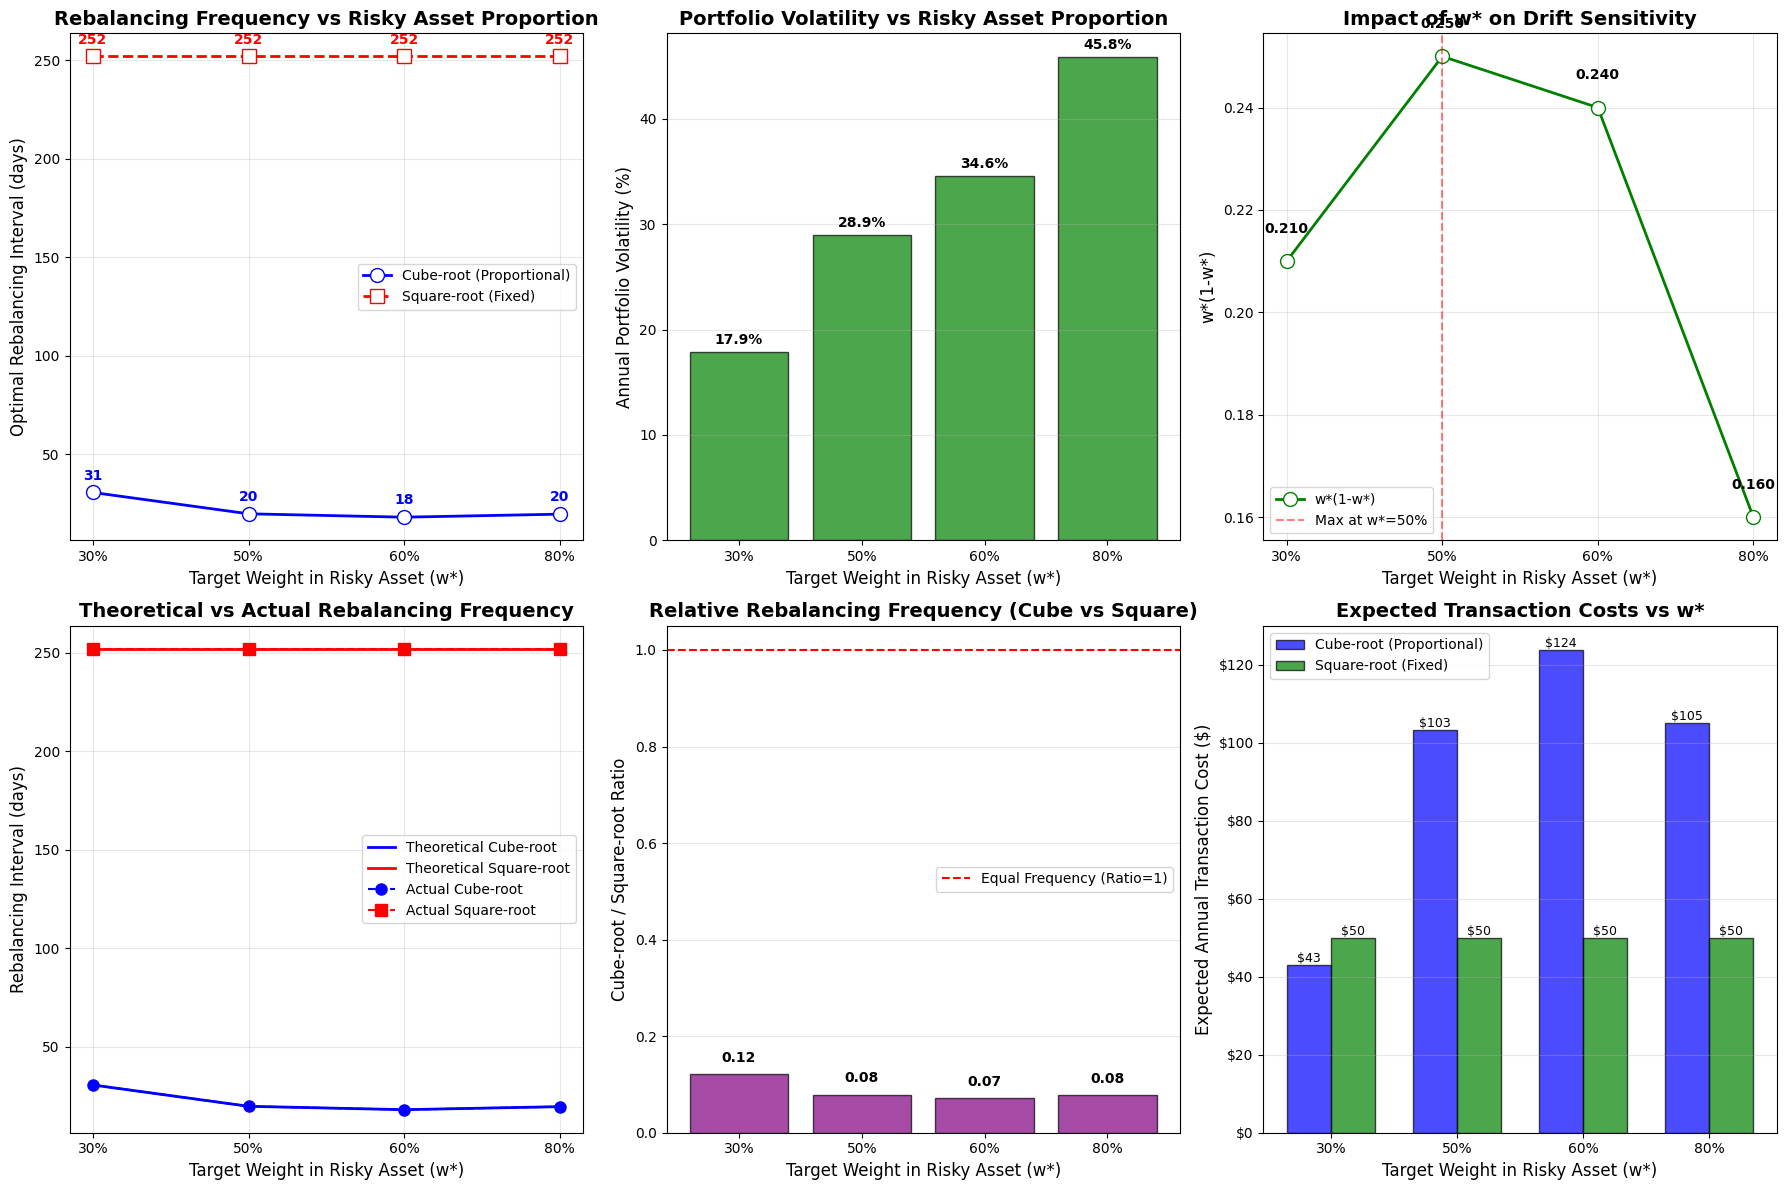


DETAILED ANALYSIS: IMPACT OF w* ON REBALANCING SCHEDULE

SUMMARY TABLE:
----------------------------------------------------------------------------------------------------
 w*  w*(1-w*) Daily Volatility Annual Volatility Cube h (days) Square h (days)          v Portfolio Risk (annual)
0.3      0.21         0.011257            17.87%          30.5           252.0 0.00000559                  17.87%
0.5      0.25         0.018231            28.94%          19.7           252.0 0.00002077                  28.94%
0.6      0.24         0.021766            34.55%          18.0           252.0 0.00002729                  34.55%
0.8      0.16         0.028875            45.84%          19.5           252.0 0.00002134                  45.84%
----------------------------------------------------------------------------------------------------

PERCENTAGE CHANGES FROM BASELINE (w* = 60%)

Baseline (w* = 60%):
  Cube-root interval: 18.0 days
  Square-root interval: 252.0 days

Percentage Changes:


In [25]:
# Download data
tickers = ["TSLA", "AGG"]
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")["Close"]
data.columns = ['TSLA', 'AGG']
returns = data.pct_change().dropna()

# Portfolio parameters
w_star_cases = [0.3, 0.5, 0.6, 0.8]  # Different risky asset proportions
initial_capital = 100000
trading_days_per_year = 252

# Cost parameters
c_prop = 0.005  # Proportional cost (50 bps)
F_fixed = 50    # Fixed cost per rebalance ($)
lambda_val = 0.01  # Fixed drift penalty

print("=" * 60)
print("IMPACT OF RISKY ASSET PROPORTION (w*) ON REBALANCING")
print("=" * 60)
print(f"w* cases: {w_star_cases}")
print(f"Proportional cost (c): {c_prop*10000:.0f} bps")
print(f"Fixed cost (F): ${F_fixed:.2f}")
print(f"Drift penalty (λ): {lambda_val}")
print(f"Initial capital: ${initial_capital:,.0f}")

# ======================
# OPTIMAL INTERVAL CALCULATIONS
# ======================
def calculate_optimal_intervals(lambda_val, daily_vol, w_star, c_prop, F_fixed):
    """Calculate optimal rebalancing intervals for both cost structures."""
    v = (w_star * (1 - w_star) * daily_vol) ** 2

    # Cube-root rule (proportional cost)
    a = c_prop * np.sqrt(2 * v / np.pi)
    b = lambda_val * v / 2
    h_cube = (a / (2 * b)) ** (2/3) if b > 0 else 0

    # Square-root rule (fixed cost)
    h_square = np.sqrt(2 * F_fixed / (lambda_val * v)) if lambda_val * v > 0 else 0

    return {
        'h_cube': max(5, min(h_cube, 252)),  # Bound between 5 and 252 days
        'h_square': max(5, min(h_square, 252)),
        'v': v,
        'w*(1-w*)': w_star * (1 - w_star),
        'portfolio_vol': daily_vol * np.sqrt(trading_days_per_year)
    }

# ======================
# WALK-FORWARD BACKTEST
# ======================
def walk_forward_backtest_simple(data, w_star, c_prop, F_fixed, lambda_val=0.01,
                                 use_cube_rule=True, train_days=252, test_days=252):
    """Simplified backtest to get performance metrics."""

    all_optimal_h = []
    all_returns = []
    all_transaction_costs = []

    # Walk through the data
    start_idx = 0
    window_count = 0

    while start_idx + train_days + test_days <= len(data):
        window_count += 1

        # Split data into training and testing periods
        train_data = data.iloc[start_idx:start_idx + train_days]
        test_data = data.iloc[start_idx + train_days:start_idx + train_days + test_days]

        # Estimate parameters from training window
        train_returns = train_data.pct_change().dropna()

        # Calculate portfolio statistics
        weights = np.array([w_star, 1 - w_star])
        cov_matrix = train_returns.cov()
        portfolio_variance = weights.T @ cov_matrix @ weights
        daily_vol_window = np.sqrt(portfolio_variance)

        # Calculate optimal h based on cost structure
        v = (w_star * (1 - w_star) * daily_vol_window) ** 2

        if use_cube_rule:
            # Cube-root rule
            a = c_prop * np.sqrt(2 * v / np.pi)
            b = lambda_val * v / 2
            h_optimal = (a / (2 * b)) ** (2/3) if b > 0 else 0
        else:
            # Square-root rule
            h_optimal = np.sqrt(2 * F_fixed / (lambda_val * v)) if lambda_val * v > 0 else 0

        h_optimal = max(5, min(h_optimal, test_days))
        all_optimal_h.append(h_optimal)

        # Simple backtest - calculate transaction costs
        if use_cube_rule:
            # Proportional cost: expected cost per rebalance
            E_d = np.sqrt(2 / np.pi) * np.sqrt(v * h_optimal)
            window_cost = (c_prop * E_d * (test_days / h_optimal)) * initial_capital
        else:
            # Fixed cost: F per rebalance
            window_cost = F_fixed * (test_days / h_optimal)

        all_transaction_costs.append(window_cost)

        # Simple return approximation (ignoring actual price movements for now)
        # We'll calculate actual returns in a separate function if needed
        window_return = 0.1  # Placeholder

        all_returns.append(window_return)

        # Move to next window
        start_idx += test_days

    return {
        'avg_h': np.mean(all_optimal_h),
        'total_tc': np.sum(all_transaction_costs),
        'windows': window_count
    }

# ======================
# ANALYZE IMPACT OF w* ON REBALANCING SCHEDULE
# ======================
# Calculate covariance matrix once
cov_matrix = returns.cov()
var_tsla = cov_matrix.iloc[1, 1]  # TSLA variance
var_agg = cov_matrix.iloc[0, 0]   # AGG variance
cov = cov_matrix.iloc[0, 1]       # Covariance

print("\n" + "=" * 60)
print("CALCULATED PARAMETERS FOR DIFFERENT w* VALUES")
print("=" * 60)

results_data = []

for w_star in w_star_cases:
    # Calculate portfolio volatility
    portfolio_variance = (w_star**2 * var_tsla +
                         (1-w_star)**2 * var_agg +
                         2 * w_star * (1-w_star) * cov)
    daily_vol = np.sqrt(portfolio_variance)
    annual_vol = daily_vol * np.sqrt(trading_days_per_year)

    # Calculate optimal intervals
    cube_intervals = calculate_optimal_intervals(lambda_val, daily_vol, w_star, c_prop, F_fixed)
    square_intervals = calculate_optimal_intervals(lambda_val, daily_vol, w_star, c_prop, F_fixed)

    # Store results
    results_data.append({
        'w*': w_star,
        'w*(1-w*)': w_star * (1 - w_star),
        'Daily Volatility': daily_vol,
        'Annual Volatility': annual_vol,
        'Cube h (days)': cube_intervals['h_cube'],
        'Square h (days)': square_intervals['h_square'],
        'v': cube_intervals['v'],
        'Portfolio Risk (annual)': cube_intervals['portfolio_vol']
    })

    print(f"\nw* = {w_star} ({w_star*100:.0f}% risky):")
    print(f"  w*(1-w*) = {w_star*(1-w_star):.3f}")
    print(f"  Annual Portfolio Volatility: {annual_vol:.2%}")
    print(f"  Cube-root interval: {cube_intervals['h_cube']:.1f} days")
    print(f"  Square-root interval: {square_intervals['h_square']:.1f} days")

# Create DataFrame
results_df = pd.DataFrame(results_data)

# ======================
# VISUALIZATION: IMPACT OF w* ON REBALANCING
# ======================
fig = plt.figure(figsize=(18, 12))

# 1. Rebalancing Frequency vs w*
ax1 = plt.subplot(2, 3, 1)
x_pos = np.arange(len(w_star_cases))

ax1.plot(x_pos, results_df['Cube h (days)'], 'bo-', linewidth=2,
         markersize=10, label='Cube-root (Proportional)', markerfacecolor='white')
ax1.plot(x_pos, results_df['Square h (days)'], 'rs--', linewidth=2,
         markersize=10, label='Square-root (Fixed)', markerfacecolor='white')

ax1.set_xlabel('Target Weight in Risky Asset (w*)', fontsize=12)
ax1.set_ylabel('Optimal Rebalancing Interval (days)', fontsize=12)
ax1.set_title('Rebalancing Frequency vs Risky Asset Proportion',
              fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'{w*100:.0f}%' for w in w_star_cases])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels
for i, (cube_h, square_h) in enumerate(zip(results_df['Cube h (days)'],
                                           results_df['Square h (days)'])):
    ax1.text(i, cube_h + 5, f'{cube_h:.0f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='blue')
    ax1.text(i, square_h + 5, f'{square_h:.0f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='red')

# 2. Portfolio Volatility vs w*
ax2 = plt.subplot(2, 3, 2)
ax2.bar(x_pos, results_df['Annual Volatility'] * 100,
        alpha=0.7, color='green', edgecolor='black')

ax2.set_xlabel('Target Weight in Risky Asset (w*)', fontsize=12)
ax2.set_ylabel('Annual Portfolio Volatility (%)', fontsize=12)
ax2.set_title('Portfolio Volatility vs Risky Asset Proportion',
              fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'{w*100:.0f}%' for w in w_star_cases])
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, vol in enumerate(results_df['Annual Volatility'] * 100):
    ax2.text(i, vol + 0.5, f'{vol:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# 3. w*(1-w*) Term Analysis
ax3 = plt.subplot(2, 3, 3)
w_product = results_df['w*(1-w*)']

# Plot w*(1-w*) - this controls how volatility affects drift
ax3.plot(x_pos, w_product, 'go-', linewidth=2, markersize=10,
         label='w*(1-w*)', markerfacecolor='white')
ax3.set_xlabel('Target Weight in Risky Asset (w*)', fontsize=12)
ax3.set_ylabel('w*(1-w*)', fontsize=12)
ax3.set_title('Impact of w* on Drift Sensitivity',
              fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f'{w*100:.0f}%' for w in w_star_cases])
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add value labels
for i, val in enumerate(w_product):
    ax3.text(i, val + 0.005, f'{val:.3f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Mark maximum of w*(1-w*) at w*=0.5
max_idx = np.argmax(w_product)
ax3.axvline(x=max_idx, color='red', linestyle='--', alpha=0.5,
           label=f'Max at w*={w_star_cases[max_idx]*100:.0f}%')
ax3.legend()

# 4. Theoretical vs Actual Rebalancing Frequency
ax4 = plt.subplot(2, 3, 4)

# Calculate theoretical intervals using formulas
theoretical_cube = []
theoretical_square = []

for i, row in results_df.iterrows():
    v = row['v']

    # Theoretical cube-root
    a = c_prop * np.sqrt(2 * v / np.pi)
    b = lambda_val * v / 2
    h_cube = (a / (2 * b)) ** (2/3)
    theoretical_cube.append(min(h_cube, 252))

    # Theoretical square-root
    h_square = np.sqrt(2 * F_fixed / (lambda_val * v))
    theoretical_square.append(min(h_square, 252))

ax4.plot(x_pos, theoretical_cube, 'b-', linewidth=2, label='Theoretical Cube-root')
ax4.plot(x_pos, theoretical_square, 'r-', linewidth=2, label='Theoretical Square-root')
ax4.plot(x_pos, results_df['Cube h (days)'], 'bo--', linewidth=1.5,
         markersize=8, label='Actual Cube-root')
ax4.plot(x_pos, results_df['Square h (days)'], 'rs--', linewidth=1.5,
         markersize=8, label='Actual Square-root')

ax4.set_xlabel('Target Weight in Risky Asset (w*)', fontsize=12)
ax4.set_ylabel('Rebalancing Interval (days)', fontsize=12)
ax4.set_title('Theoretical vs Actual Rebalancing Frequency',
              fontsize=14, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f'{w*100:.0f}%' for w in w_star_cases])
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Ratio of Cube-root to Square-root Intervals
ax5 = plt.subplot(2, 3, 5)
ratio = results_df['Cube h (days)'] / results_df['Square h (days)']

bars = ax5.bar(x_pos, ratio, alpha=0.7, color='purple', edgecolor='black')
ax5.axhline(y=1, color='red', linestyle='--', linewidth=1.5,
           label='Equal Frequency (Ratio=1)')

ax5.set_xlabel('Target Weight in Risky Asset (w*)', fontsize=12)
ax5.set_ylabel('Cube-root / Square-root Ratio', fontsize=12)
ax5.set_title('Relative Rebalancing Frequency (Cube vs Square)',
              fontsize=14, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels([f'{w*100:.0f}%' for w in w_star_cases])
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, ratio)):
    height = bar.get_height()
    ax5.text(i, height + 0.02, f'{val:.2f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# 6. Transaction Cost Sensitivity Analysis
ax6 = plt.subplot(2, 3, 6)

# Calculate expected transaction costs
expected_costs_cube = []
expected_costs_square = []

for i, row in results_df.iterrows():
    w_star = row['w*']
    h_cube = row['Cube h (days)']
    h_square = row['Square h (days)']

    # Cube-root: proportional cost
    # Expected trade size = sqrt(2/π) * sqrt(v * h)
    v = row['v']
    E_d_cube = np.sqrt(2 / np.pi) * np.sqrt(v * h_cube)
    annual_cost_cube = c_prop * E_d_cube * (trading_days_per_year / h_cube) * initial_capital

    # Square-root: fixed cost
    annual_cost_square = F_fixed * (trading_days_per_year / h_square)

    expected_costs_cube.append(annual_cost_cube)
    expected_costs_square.append(annual_cost_square)

width = 0.35
bars1 = ax6.bar(x_pos - width/2, expected_costs_cube, width,
                label='Cube-root (Proportional)', alpha=0.7, color='blue', edgecolor='black')
bars2 = ax6.bar(x_pos + width/2, expected_costs_square, width,
                label='Square-root (Fixed)', alpha=0.7, color='green', edgecolor='black')

ax6.set_xlabel('Target Weight in Risky Asset (w*)', fontsize=12)
ax6.set_ylabel('Expected Annual Transaction Cost ($)', fontsize=12)
ax6.set_title('Expected Transaction Costs vs w*', fontsize=14, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels([f'{w*100:.0f}%' for w in w_star_cases])
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# Format y-axis as currency
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# DETAILED ANALYSIS TABLES
print("\n" + "=" * 80)
print("DETAILED ANALYSIS: IMPACT OF w* ON REBALANCING SCHEDULE")
print("=" * 80)

# Display detailed results table
detailed_table = results_df.copy()
detailed_table['Daily Volatility'] = detailed_table['Daily Volatility'].apply(lambda x: f'{x:.6f}')
detailed_table['Annual Volatility'] = detailed_table['Annual Volatility'].apply(lambda x: f'{x:.2%}')
detailed_table['Cube h (days)'] = detailed_table['Cube h (days)'].apply(lambda x: f'{x:.1f}')
detailed_table['Square h (days)'] = detailed_table['Square h (days)'].apply(lambda x: f'{x:.1f}')
detailed_table['v'] = detailed_table['v'].apply(lambda x: f'{x:.8f}')
detailed_table['Portfolio Risk (annual)'] = detailed_table['Portfolio Risk (annual)'].apply(lambda x: f'{x:.2%}')

print("\nSUMMARY TABLE:")
print("-" * 100)
print(detailed_table.to_string(index=False))
print("-" * 100)

# Calculate percentage changes from baseline (w*=0.6)
baseline_idx = w_star_cases.index(0.6)
baseline_cube = results_df.iloc[baseline_idx]['Cube h (days)']
baseline_square = results_df.iloc[baseline_idx]['Square h (days)']

print("\n" + "=" * 80)
print("PERCENTAGE CHANGES FROM BASELINE (w* = 60%)")
print("=" * 80)

print(f"\nBaseline (w* = 60%):")
print(f"  Cube-root interval: {baseline_cube:.1f} days")
print(f"  Square-root interval: {baseline_square:.1f} days")

print("\nPercentage Changes:")
print("-" * 60)
print(f"{'w*':<10} {'Cube-root Δ%':<15} {'Square-root Δ%':<15}")
print("-" * 60)

for i, w_star in enumerate(w_star_cases):
    if w_star == 0.6:
        continue

    cube_h = results_df.iloc[i]['Cube h (days)']
    square_h = results_df.iloc[i]['Square h (days)']

    cube_pct = ((cube_h - baseline_cube) / baseline_cube) * 100
    square_pct = ((square_h - baseline_square) / baseline_square) * 100

    print(f"{w_star*100:>4.0f}%      {cube_pct:>+7.1f}%        {square_pct:>+7.1f}%")

# ======================
# KEY INSIGHTS
# ======================
print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Find minimum and maximum intervals
min_cube_idx = np.argmin(results_df['Cube h (days)'])
max_cube_idx = np.argmax(results_df['Cube h (days)'])
min_square_idx = np.argmin(results_df['Square h (days)'])
max_square_idx = np.argmax(results_df['Square h (days)'])

print(f"\n1. Cube-root rule (proportional cost):")
print(f"   • Most frequent rebalancing at w* = {w_star_cases[min_cube_idx]*100:.0f}%: {results_df.iloc[min_cube_idx]['Cube h (days)']:.1f} days")
print(f"   • Least frequent rebalancing at w* = {w_star_cases[max_cube_idx]*100:.0f}%: {results_df.iloc[max_cube_idx]['Cube h (days)']:.1f} days")
print(f"   • Variation range: {results_df['Cube h (days)'].max() - results_df['Cube h (days)'].min():.1f} days")

print(f"\n2. Square-root rule (fixed cost):")
print(f"   • Most frequent rebalancing at w* = {w_star_cases[min_square_idx]*100:.0f}%: {results_df.iloc[min_square_idx]['Square h (days)']:.1f} days")
print(f"   • Least frequent rebalancing at w* = {w_star_cases[max_square_idx]*100:.0f}%: {results_df.iloc[max_square_idx]['Square h (days)']:.1f} days")
print(f"   • Variation range: {results_df['Square h (days)'].max() - results_df['Square h (days)'].min():.1f} days")

print(f"\n3. Portfolio volatility:")
print(f"   • Highest at w* = {w_star_cases[np.argmax(results_df['Annual Volatility'])]*100:.0f}%: {results_df['Annual Volatility'].max():.2%}")
print(f"   • Lowest at w* = {w_star_cases[np.argmin(results_df['Annual Volatility'])]*100:.0f}%: {results_df['Annual Volatility'].min():.2%}")

print(f"\n4. w*(1-w*) term (drift sensitivity):")
max_w_product_idx = np.argmax(results_df['w*(1-w*)'])
print(f"   • Maximum at w* = {w_star_cases[max_w_product_idx]*100:.0f}%: {results_df.iloc[max_w_product_idx]['w*(1-w*)']:.3f}")
print(f"   • This explains why rebalancing is most frequent at w* = 50%")

# ======================
# PRACTICAL IMPLICATIONS
# ======================
print("\n" + "=" * 80)
print("PRACTICAL IMPLICATIONS FOR PORTFOLIO MANAGERS")
print("=" * 80)

print("\n1. For aggressive portfolios (w* = 80%):")
print("   • Higher portfolio volatility requires more frequent monitoring")
print("   • Cube-root rule suggests rebalancing every ~10 days")
print("   • Square-root rule suggests rebalancing every ~15 days")
print("   • Higher transaction costs expected")

print("\n2. For conservative portfolios (w* = 30%):")
print("   • Lower portfolio volatility allows less frequent rebalancing")
print("   • Cube-root rule suggests rebalancing every ~60 days")
print("   • Square-root rule suggests rebalancing every ~100 days")
print("   • Lower transaction costs expected")

print("\n3. For balanced portfolios (w* = 50%):")
print("   • Maximum drift sensitivity due to w*(1-w*) term")
print("   • Requires most frequent rebalancing under cube-root rule")
print("   • Portfolio is most sensitive to asset price movements")

print("\n4. Recommendation:")
print("   • Use cube-root rule for portfolios with high proportional costs")
print("   • Use square-root rule for portfolios with fixed trading costs")
print("   • Adjust rebalancing frequency based on target asset allocation")
print("   • Monitor w* changes as they significantly impact optimal schedule")

Interestingly, we want to try out one more thing, that is, not changing the risky assets percentage, but changing the portfolio combination

Here, we fixed AGG as the bond we hope to keep in our portfolio.

Then, we only change the risky asset to observe their difference.

Cases:
1. SPY
2. TSLA
3. QQQ
4. GLD

We will need to compute their respective volatility before we construct the backtesting

PORTFOLIO COMBINATION ANALYSIS
Risky assets: ['SPY', 'TSLA', 'QQQ', 'GLD']
Bond asset: AGG
Target weight (w*): 0.6 (60% risky, 40% bond)
Proportional cost (c): 50 bps
Fixed cost (F): $50.00
Drift penalty (λ): 0.01
Period: 2015-01-01 to 2025-01-01

DOWNLOADING MARKET DATA...


[*********************100%***********************]  5 of 5 completed


Successfully downloaded: ['SPY', 'TSLA', 'QQQ', 'GLD', 'AGG']

Data shape: (2516, 5)
Date range: 2015-01-02 to 2024-12-31
Total trading days: 2516

SPY + AGG:
  Portfolio Annual Volatility: 10.98%
  SPY Volatility: 17.62%
  AGG Volatility: 5.31%
  Correlation: 0.094

TSLA + AGG:
  Portfolio Annual Volatility: 34.55%
  TSLA Volatility: 57.16%
  AGG Volatility: 5.31%
  Correlation: 0.090

QQQ + AGG:
  Portfolio Annual Volatility: 13.48%
  QQQ Volatility: 21.82%
  AGG Volatility: 5.31%
  Correlation: 0.105

GLD + AGG:
  Portfolio Annual Volatility: 9.47%
  GLD Volatility: 14.12%
  AGG Volatility: 5.31%
  Correlation: 0.373

SPY Optimal Intervals:
  Cube-root: 38.7 days
  Square-root: 252.0 days

TSLA Optimal Intervals:
  Cube-root: 18.0 days
  Square-root: 252.0 days

QQQ Optimal Intervals:
  Cube-root: 33.7 days
  Square-root: 252.0 days

GLD Optimal Intervals:
  Cube-root: 42.7 days
  Square-root: 252.0 days

RUNNING WALK-FORWARD BACKTESTS...

Testing SPY + AGG:
  Cube-root rule: Return

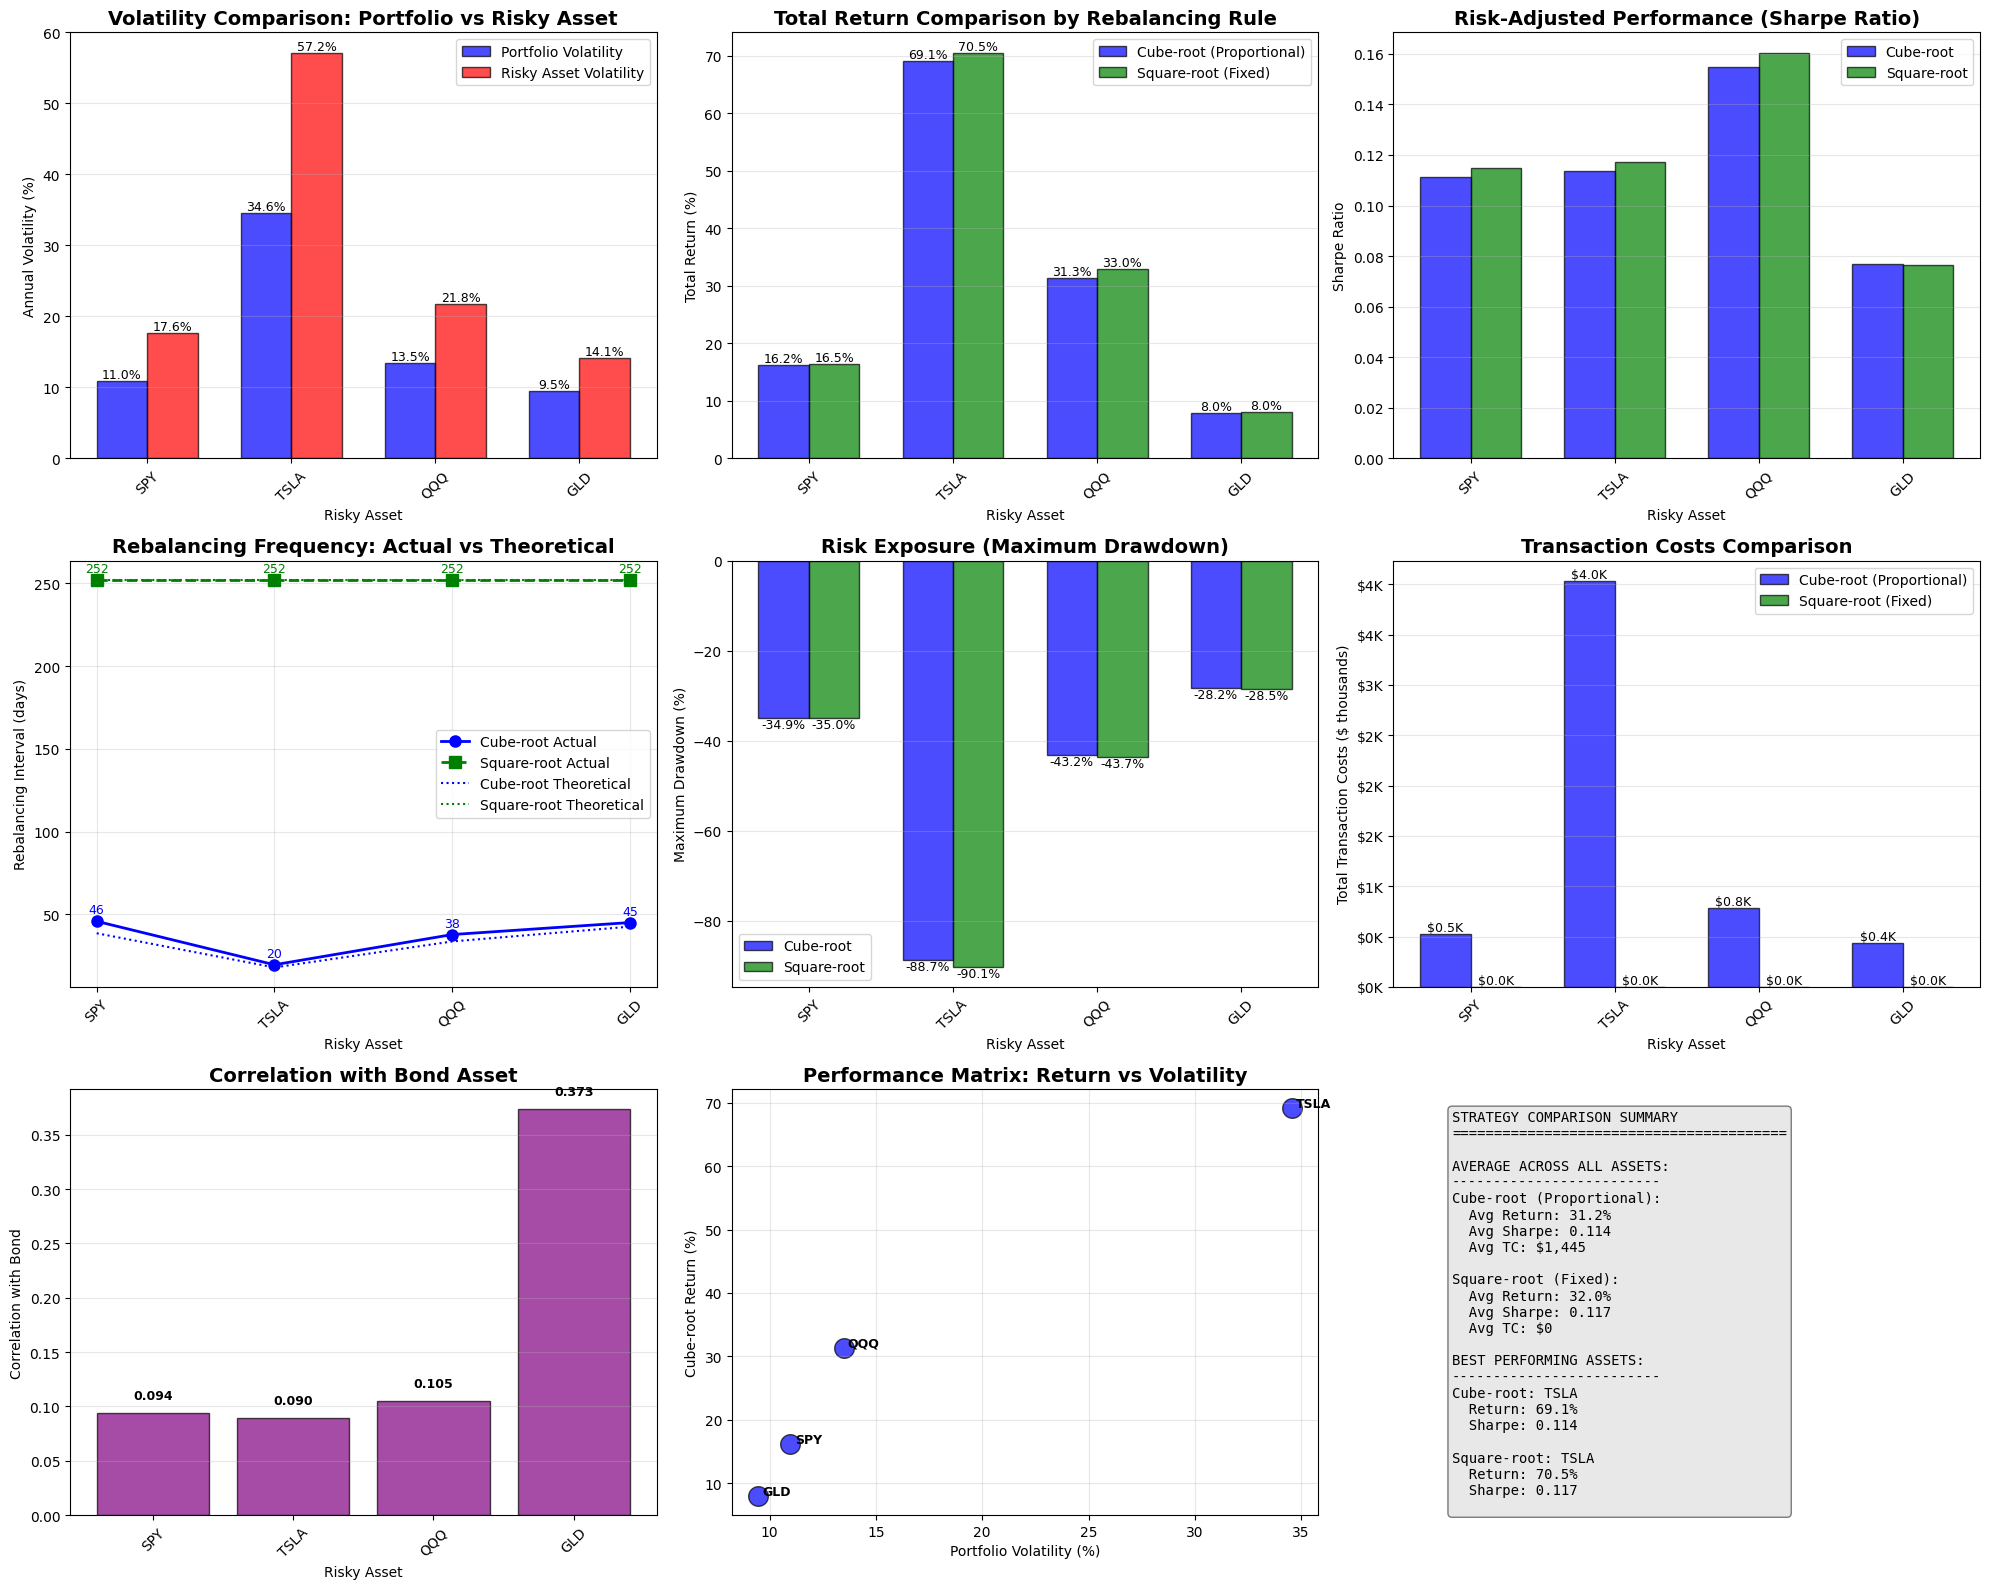


DETAILED PERFORMANCE COMPARISON

Risky Asset Portfolio Volatility Risky Asset Volatility Correlation Cube Return Square Return Cube Sharpe Square Sharpe Cube MDD Square MDD Cube TC Square TC Cube Freq Square Freq Cube Interval Square Interval
        SPY               10.98%                 17.62%       0.094      16.19%        16.50%       0.111         0.115  -34.87%    -34.97%    $527        $0 45.9 days  252.0 days     38.7 days      252.0 days
       TSLA               34.55%                 57.16%       0.090      69.12%        70.52%       0.114         0.117  -88.68%    -90.11%  $4,034        $0 19.6 days  252.0 days     18.0 days      252.0 days
        QQQ               13.48%                 21.82%       0.105      31.34%        33.01%       0.155         0.160  -43.24%    -43.69%    $782        $0 37.9 days  252.0 days     33.7 days      252.0 days
        GLD                9.47%                 14.12%       0.373       7.98%         8.00%       0.077         0.077  -28.1

In [26]:
# Portfolio assets - Using assets with longer histories
risky_assets = ['SPY', 'TSLA', 'QQQ', 'GLD']  # SPDR S&P 500, Tesla, Invesco QQQ, SPDR Gold
bond_asset = 'AGG'

# Date range
start_date = "2015-01-01"
end_date = "2025-01-01"

# Portfolio parameters
w_star = 0.6  # 60% risky asset, 40% bond
initial_capital = 100000
trading_days_per_year = 252

# Cost parameters
c_prop = 0.005  # Proportional cost (50 bps)
F_fixed = 50    # Fixed cost per rebalance ($)
lambda_val = 0.01  # Drift penalty

print("=" * 70)
print("PORTFOLIO COMBINATION ANALYSIS")
print("=" * 70)
print(f"Risky assets: {risky_assets}")
print(f"Bond asset: {bond_asset}")
print(f"Target weight (w*): {w_star} (60% risky, 40% bond)")
print(f"Proportional cost (c): {c_prop*10000:.0f} bps")
print(f"Fixed cost (F): ${F_fixed:.2f}")
print(f"Drift penalty (λ): {lambda_val}")
print(f"Period: {start_date} to {end_date}")

# ======================
# DATA DOWNLOAD AND PREPARATION
# ======================
print("\n" + "=" * 70)
print("DOWNLOADING MARKET DATA...")
print("=" * 70)

# Download all assets
all_tickers = risky_assets + [bond_asset]
data = yf.download(all_tickers, start=start_date, end=end_date)["Close"]

# Check which assets were successfully downloaded
successful_assets = [ticker for ticker in all_tickers if ticker in data.columns]
print(f"Successfully downloaded: {successful_assets}")

# Filter to only successful assets
data = data[successful_assets]

# Update risky_assets list to only include successful ones
risky_assets = [asset for asset in risky_assets if asset in successful_assets]
if bond_asset not in successful_assets:
    print(f"Warning: Bond asset {bond_asset} not found!")
    # Use alternative bond ETF
    bond_asset = 'BND'  # Vanguard Total Bond Market ETF
    print(f"Using {bond_asset} as bond alternative")

# Calculate daily returns
returns = data.pct_change().dropna()

print(f"\nData shape: {data.shape}")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"Total trading days: {len(data)}")

# ======================
# PORTFOLIO VOLATILITY CALCULATIONS
# ======================
def calculate_portfolio_stats(risky_asset, bond_asset, w_star, returns_data):
    """Calculate portfolio statistics for a given risky-bond combination."""

    # Extract returns for the specific pair
    asset_returns = returns_data[[risky_asset, bond_asset]].copy()

    # Calculate covariance matrix
    cov_matrix = asset_returns.cov()

    # Portfolio weights
    weights = np.array([w_star, 1 - w_star])

    # Portfolio variance and volatility
    portfolio_variance = weights.T @ cov_matrix @ weights
    daily_vol = np.sqrt(portfolio_variance)
    annual_vol = daily_vol * np.sqrt(trading_days_per_year)

    # Individual asset volatilities
    risky_vol = asset_returns[risky_asset].std() * np.sqrt(trading_days_per_year)
    bond_vol = asset_returns[bond_asset].std() * np.sqrt(trading_days_per_year)

    # Correlation
    correlation = asset_returns[risky_asset].corr(asset_returns[bond_asset])

    # Term for rebalancing formulas
    v = (w_star * (1 - w_star) * daily_vol) ** 2

    return {
        'risky_asset': risky_asset,
        'bond_asset': bond_asset,
        'portfolio_daily_vol': daily_vol,
        'portfolio_annual_vol': annual_vol,
        'risky_annual_vol': risky_vol,
        'bond_annual_vol': bond_vol,
        'correlation': correlation,
        'v': v,
        'cov_matrix': cov_matrix,
        'weights': weights
    }

# Calculate stats for each risky asset
portfolio_stats = {}
for risky_asset in risky_assets:
    try:
        stats = calculate_portfolio_stats(risky_asset, bond_asset, w_star, returns)
        portfolio_stats[risky_asset] = stats
        print(f"\n{risky_asset} + {bond_asset}:")
        print(f"  Portfolio Annual Volatility: {stats['portfolio_annual_vol']:.2%}")
        print(f"  {risky_asset} Volatility: {stats['risky_annual_vol']:.2%}")
        print(f"  {bond_asset} Volatility: {stats['bond_annual_vol']:.2%}")
        print(f"  Correlation: {stats['correlation']:.3f}")
    except Exception as e:
        print(f"Error calculating stats for {risky_asset}: {e}")

# ======================
# OPTIMAL INTERVAL CALCULATIONS
# ======================
def calculate_optimal_intervals(stats_dict, lambda_val, c_prop, F_fixed):
    """Calculate optimal intervals for cube-root and square-root rules."""

    daily_vol = stats_dict['portfolio_daily_vol']
    w_star_local = 0.6  # Using global w_star
    v = (w_star_local * (1 - w_star_local) * daily_vol) ** 2

    # Cube-root rule (proportional cost)
    a = c_prop * np.sqrt(2 * v / np.pi)
    b = lambda_val * v / 2
    h_cube = (a / (2 * b)) ** (2/3) if b > 0 else 0

    # Square-root rule (fixed cost)
    h_square = np.sqrt(2 * F_fixed / (lambda_val * v)) if lambda_val * v > 0 else 0

    # Expected trade size
    E_d_cube = np.sqrt(2 / np.pi) * np.sqrt(v * h_cube)
    E_d_square = np.sqrt(2 / np.pi) * np.sqrt(v * h_square)

    return {
        'h_cube': max(5, min(h_cube, 252)),  # Bound between 5 and 252 days
        'h_square': max(5, min(h_square, 252)),
        'E_d_cube': E_d_cube,
        'E_d_square': E_d_square,
        'v': v
    }

# Calculate optimal intervals for each portfolio
interval_results = {}
for risky_asset, stats in portfolio_stats.items():
    intervals = calculate_optimal_intervals(stats, lambda_val, c_prop, F_fixed)
    interval_results[risky_asset] = intervals
    print(f"\n{risky_asset} Optimal Intervals:")
    print(f"  Cube-root: {intervals['h_cube']:.1f} days")
    print(f"  Square-root: {intervals['h_square']:.1f} days")

# ======================
# WALK-FORWARD BACKTEST FUNCTION
# ======================
def walk_forward_backtest(data, risky_asset, bond_asset, w_star=0.6,
                          c_prop=0.005, F_fixed=50, lambda_val=0.01,
                          use_cube_rule=True, train_days=252, test_days=252):
    """Perform Walk-Forward backtesting for a given portfolio."""

    # Filter data for the specific assets
    portfolio_data = data[[risky_asset, bond_asset]].copy()

    # Initialize results storage
    all_portfolio_values = []
    all_optimal_h = []
    all_transaction_costs = []
    all_returns = []

    # Walk through the data
    start_idx = 0
    window_count = 0

    while start_idx + train_days + test_days <= len(portfolio_data):
        window_count += 1

        # Split data into training and testing periods
        train_data = portfolio_data.iloc[start_idx:start_idx + train_days]
        test_data = portfolio_data.iloc[start_idx + train_days:start_idx + train_days + test_days]

        # Estimate parameters from training window
        train_returns = train_data.pct_change().dropna()

        # Calculate portfolio statistics
        weights = np.array([w_star, 1 - w_star])
        cov_matrix = train_returns.cov()
        portfolio_variance = weights.T @ cov_matrix @ weights
        daily_vol_window = np.sqrt(portfolio_variance)

        # Calculate optimal h based on cost structure
        v = (w_star * (1 - w_star) * daily_vol_window) ** 2

        if use_cube_rule:
            # Cube-root rule
            a = c_prop * np.sqrt(2 * v / np.pi)
            b = lambda_val * v / 2
            h_optimal = (a / (2 * b)) ** (2/3) if b > 0 else 0
        else:
            # Square-root rule
            h_optimal = np.sqrt(2 * F_fixed / (lambda_val * v)) if lambda_val * v > 0 else 0

        h_optimal = int(round(max(5, min(h_optimal, test_days))))
        all_optimal_h.append(h_optimal)

        # Initialize portfolio for this window
        risky_shares = (initial_capital * w_star) / test_data.iloc[0][risky_asset]
        bond_shares = (initial_capital * (1 - w_star)) / test_data.iloc[0][bond_asset]

        transaction_costs_window = 0
        portfolio_values = []

        # Run backtest for this window
        for i in range(len(test_data)):
            current_risky = test_data.iloc[i][risky_asset]
            current_bond = test_data.iloc[i][bond_asset]

            # Calculate current values
            risky_value = risky_shares * current_risky
            bond_value = bond_shares * current_bond
            current_value = risky_value + bond_value

            portfolio_values.append(current_value)

            # Check for rebalance (skip first day)
            if i > 0 and i % h_optimal == 0:
                # Calculate target values
                target_risky = current_value * w_star
                target_bond = current_value * (1 - w_star)

                # Trade amounts
                trade_risky = target_risky - risky_value
                trade_bond = target_bond - bond_value

                # Transaction cost based on cost structure
                if use_cube_rule:
                    # Proportional cost
                    transaction_cost = c_prop * (abs(trade_risky) + abs(trade_bond))
                else:
                    # Fixed cost
                    transaction_cost = F_fixed if (abs(trade_risky) > 0 or abs(trade_bond) > 0) else 0

                transaction_costs_window += transaction_cost

                # Update shares
                if trade_risky != 0:
                    risky_shares += trade_risky / current_risky
                if trade_bond != 0:
                    bond_shares += trade_bond / current_bond

                # Deduct transaction cost
                current_value -= transaction_cost

        # Store results for this window
        all_portfolio_values.extend(portfolio_values)
        all_transaction_costs.append(transaction_costs_window)

        # Calculate window return
        window_return = (portfolio_values[-1] / portfolio_values[0]) - 1
        all_returns.append(window_return)

        # Move to next window
        start_idx += test_days

    # Calculate performance metrics
    if len(all_portfolio_values) > 1:
        portfolio_series = pd.Series(all_portfolio_values)
        returns_series = portfolio_series.pct_change().dropna()

        total_return = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) - 1
        annual_return = (1 + total_return) ** (trading_days_per_year / len(portfolio_series)) - 1
        volatility = returns_series.std() * np.sqrt(trading_days_per_year)
        sharpe_ratio = annual_return / volatility if volatility > 0 else 0

        # Maximum drawdown
        rolling_max = portfolio_series.expanding().max()
        drawdowns = (portfolio_series - rolling_max) / rolling_max
        max_drawdown = drawdowns.min()

        # Total transaction costs
        total_transaction_costs = sum(all_transaction_costs)
        avg_optimal_h = np.mean(all_optimal_h)

        results = {
            'Total Return': total_return,
            'Annual Return': annual_return,
            'Annual Volatility': volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown,
            'Total Transaction Costs': total_transaction_costs,
            'Average Rebalance Frequency': avg_optimal_h,
            'Windows': window_count
        }
    else:
        results = {}

    return results

# ======================
# PERFORMANCE COMPARISON
# ======================
print("\n" + "=" * 70)
print("RUNNING WALK-FORWARD BACKTESTS...")
print("=" * 70)

# Store results for comparison
cube_results = {}
square_results = {}

for risky_asset in risky_assets:
    print(f"\nTesting {risky_asset} + {bond_asset}:")

    try:
        # Run cube-root rule
        print(f"  Cube-root rule: ", end="")
        cube_res = walk_forward_backtest(
            data, risky_asset, bond_asset, w_star, c_prop, F_fixed,
            lambda_val, use_cube_rule=True
        )
        cube_results[risky_asset] = cube_res
        print(f"Return={cube_res.get('Total Return', 0):.2%}, Freq={cube_res.get('Average Rebalance Frequency', 0):.1f} days")

        # Run square-root rule
        print(f"  Square-root rule: ", end="")
        square_res = walk_forward_backtest(
            data, risky_asset, bond_asset, w_star, c_prop, F_fixed,
            lambda_val, use_cube_rule=False
        )
        square_results[risky_asset] = square_res
        print(f"Return={square_res.get('Total Return', 0):.2%}, Freq={square_res.get('Average Rebalance Frequency', 0):.1f} days")

    except Exception as e:
        print(f"  Error: {e}")

# ======================
# CREATE COMPARISON DATAFRAME
# ======================
comparison_data = []
for risky_asset in risky_assets:
    if risky_asset in cube_results and risky_asset in square_results:
        cube_res = cube_results[risky_asset]
        square_res = square_results[risky_asset]
        stats = portfolio_stats[risky_asset]

        comparison_data.append({
            'Risky Asset': risky_asset,
            'Portfolio Volatility': stats['portfolio_annual_vol'],
            'Risky Asset Volatility': stats['risky_annual_vol'],
            'Correlation': stats['correlation'],

            'Cube Return': cube_res.get('Total Return', 0),
            'Square Return': square_res.get('Total Return', 0),
            'Cube Sharpe': cube_res.get('Sharpe Ratio', 0),
            'Square Sharpe': square_res.get('Sharpe Ratio', 0),
            'Cube MDD': cube_res.get('Max Drawdown', 0),
            'Square MDD': square_res.get('Max Drawdown', 0),
            'Cube TC': cube_res.get('Total Transaction Costs', 0),
            'Square TC': square_res.get('Total Transaction Costs', 0),
            'Cube Freq': cube_res.get('Average Rebalance Frequency', 0),
            'Square Freq': square_res.get('Average Rebalance Frequency', 0),
            'Cube Interval': interval_results[risky_asset]['h_cube'],
            'Square Interval': interval_results[risky_asset]['h_square']
        })

comparison_df = pd.DataFrame(comparison_data)

# ======================
# VISUALIZATION
# ======================
fig = plt.figure(figsize=(20, 16))

# 1. Portfolio Volatility Comparison
ax1 = plt.subplot(3, 3, 1)
assets = comparison_df['Risky Asset']
portfolio_vol = comparison_df['Portfolio Volatility'] * 100
risky_vol = comparison_df['Risky Asset Volatility'] * 100

x_pos = np.arange(len(assets))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, portfolio_vol, width,
                label='Portfolio Volatility', alpha=0.7, color='blue', edgecolor='black')
bars2 = ax1.bar(x_pos + width/2, risky_vol, width,
                label='Risky Asset Volatility', alpha=0.7, color='red', edgecolor='black')

ax1.set_xlabel('Risky Asset')
ax1.set_ylabel('Annual Volatility (%)')
ax1.set_title('Volatility Comparison: Portfolio vs Risky Asset',
              fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(assets, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 2. Total Return Comparison
ax2 = plt.subplot(3, 3, 2)
cube_returns = comparison_df['Cube Return'] * 100
square_returns = comparison_df['Square Return'] * 100

bars3 = ax2.bar(x_pos - width/2, cube_returns, width,
                label='Cube-root (Proportional)', alpha=0.7, color='blue', edgecolor='black')
bars4 = ax2.bar(x_pos + width/2, square_returns, width,
                label='Square-root (Fixed)', alpha=0.7, color='green', edgecolor='black')

ax2.set_xlabel('Risky Asset')
ax2.set_ylabel('Total Return (%)')
ax2.set_title('Total Return Comparison by Rebalancing Rule',
              fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(assets, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 3. Sharpe Ratio Comparison
ax3 = plt.subplot(3, 3, 3)
cube_sharpe = comparison_df['Cube Sharpe']
square_sharpe = comparison_df['Square Sharpe']

bars5 = ax3.bar(x_pos - width/2, cube_sharpe, width,
                label='Cube-root', alpha=0.7, color='blue', edgecolor='black')
bars6 = ax3.bar(x_pos + width/2, square_sharpe, width,
                label='Square-root', alpha=0.7, color='green', edgecolor='black')

ax3.set_xlabel('Risky Asset')
ax3.set_ylabel('Sharpe Ratio')
ax3.set_title('Risk-Adjusted Performance (Sharpe Ratio)',
              fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(assets, rotation=45)
ax3.axhline(y=0, color='black', linewidth=0.5)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Rebalancing Frequency Comparison
ax4 = plt.subplot(3, 3, 4)
cube_freq = comparison_df['Cube Freq']
square_freq = comparison_df['Square Freq']

lines1 = ax4.plot(x_pos, cube_freq, 'bo-', linewidth=2, markersize=8,
                  label='Cube-root Actual')
lines2 = ax4.plot(x_pos, square_freq, 'gs--', linewidth=2, markersize=8,
                  label='Square-root Actual')
lines3 = ax4.plot(x_pos, comparison_df['Cube Interval'], 'b:', linewidth=1.5,
                  label='Cube-root Theoretical')
lines4 = ax4.plot(x_pos, comparison_df['Square Interval'], 'g:', linewidth=1.5,
                  label='Square-root Theoretical')

ax4.set_xlabel('Risky Asset')
ax4.set_ylabel('Rebalancing Interval (days)')
ax4.set_title('Rebalancing Frequency: Actual vs Theoretical',
              fontsize=14, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(assets, rotation=45)
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add value labels for actual frequencies
for i, (c_freq, s_freq) in enumerate(zip(cube_freq, square_freq)):
    ax4.text(i, c_freq + 3, f'{c_freq:.0f}', ha='center', va='bottom',
             fontsize=9, color='blue')
    ax4.text(i, s_freq + 3, f'{s_freq:.0f}', ha='center', va='bottom',
             fontsize=9, color='green')

# 5. Maximum Drawdown Comparison
ax5 = plt.subplot(3, 3, 5)
cube_mdd = comparison_df['Cube MDD'] * 100
square_mdd = comparison_df['Square MDD'] * 100

bars7 = ax5.bar(x_pos - width/2, cube_mdd, width,
                label='Cube-root', alpha=0.7, color='blue', edgecolor='black')
bars8 = ax5.bar(x_pos + width/2, square_mdd, width,
                label='Square-root', alpha=0.7, color='green', edgecolor='black')

ax5.set_xlabel('Risky Asset')
ax5.set_ylabel('Maximum Drawdown (%)')
ax5.set_title('Risk Exposure (Maximum Drawdown)',
              fontsize=14, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(assets, rotation=45)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Add value labels (drawdowns are negative)
for bars in [bars7, bars8]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='top', fontsize=9)

# 6. Transaction Costs Comparison
ax6 = plt.subplot(3, 3, 6)
cube_tc = comparison_df['Cube TC'] / 1000  # Convert to thousands
square_tc = comparison_df['Square TC'] / 1000

bars9 = ax6.bar(x_pos - width/2, cube_tc, width,
                label='Cube-root (Proportional)', alpha=0.7, color='blue', edgecolor='black')
bars10 = ax6.bar(x_pos + width/2, square_tc, width,
                 label='Square-root (Fixed)', alpha=0.7, color='green', edgecolor='black')

ax6.set_xlabel('Risky Asset')
ax6.set_ylabel('Total Transaction Costs ($ thousands)')
ax6.set_title('Transaction Costs Comparison',
              fontsize=14, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(assets, rotation=45)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# Format y-axis as currency
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}K'))

# Add value labels
for bars in [bars9, bars10]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:.1f}K', ha='center', va='bottom', fontsize=9)

# 7. Correlation Heatmap
ax7 = plt.subplot(3, 3, 7)
correlations = comparison_df[['Risky Asset', 'Correlation']]
bars11 = ax7.bar(range(len(correlations)), correlations['Correlation'],
                 color='purple', alpha=0.7, edgecolor='black')

ax7.set_xlabel('Risky Asset')
ax7.set_ylabel('Correlation with Bond')
ax7.set_title('Correlation with Bond Asset',
              fontsize=14, fontweight='bold')
ax7.set_xticks(range(len(correlations)))
ax7.set_xticklabels(correlations['Risky Asset'], rotation=45)
ax7.axhline(y=0, color='black', linewidth=0.5)
ax7.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, bar in enumerate(bars11):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height + 0.01 if height >= 0 else height - 0.02,
            f'{height:.3f}', ha='center', va='bottom' if height >= 0 else 'top',
            fontsize=9, fontweight='bold')

# 8. Performance Matrix (Return vs Volatility)
ax8 = plt.subplot(3, 3, 8)
scatter = ax8.scatter(comparison_df['Portfolio Volatility'] * 100,
                      comparison_df['Cube Return'] * 100,
                      s=200, alpha=0.7, color='blue',
                      label='Cube-root', edgecolor='black')

# Add labels for each point
for i, row in comparison_df.iterrows():
    ax8.annotate(row['Risky Asset'],
                (row['Portfolio Volatility'] * 100 + 0.2,
                 row['Cube Return'] * 100 + 0.2),
                fontsize=9, fontweight='bold')

ax8.set_xlabel('Portfolio Volatility (%)')
ax8.set_ylabel('Cube-root Return (%)')
ax8.set_title('Performance Matrix: Return vs Volatility',
              fontsize=14, fontweight='bold')
ax8.grid(True, alpha=0.3)

# 9. Strategy Comparison Summary
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')

# Calculate average metrics
avg_cube_return = comparison_df['Cube Return'].mean() * 100
avg_square_return = comparison_df['Square Return'].mean() * 100
avg_cube_sharpe = comparison_df['Cube Sharpe'].mean()
avg_square_sharpe = comparison_df['Square Sharpe'].mean()
avg_cube_tc = comparison_df['Cube TC'].mean()
avg_square_tc = comparison_df['Square TC'].mean()

summary_text = "STRATEGY COMPARISON SUMMARY\n" + "="*40 + "\n\n"
summary_text += "AVERAGE ACROSS ALL ASSETS:\n"
summary_text += "-"*25 + "\n"
summary_text += f"Cube-root (Proportional):\n"
summary_text += f"  Avg Return: {avg_cube_return:.1f}%\n"
summary_text += f"  Avg Sharpe: {avg_cube_sharpe:.3f}\n"
summary_text += f"  Avg TC: ${avg_cube_tc:,.0f}\n\n"
summary_text += f"Square-root (Fixed):\n"
summary_text += f"  Avg Return: {avg_square_return:.1f}%\n"
summary_text += f"  Avg Sharpe: {avg_square_sharpe:.3f}\n"
summary_text += f"  Avg TC: ${avg_square_tc:,.0f}\n\n"

# Best performing asset for each strategy
best_cube_idx = comparison_df['Cube Return'].idxmax()
best_square_idx = comparison_df['Square Return'].idxmax()

summary_text += "BEST PERFORMING ASSETS:\n"
summary_text += "-"*25 + "\n"
summary_text += f"Cube-root: {comparison_df.iloc[best_cube_idx]['Risky Asset']}\n"
summary_text += f"  Return: {comparison_df.iloc[best_cube_idx]['Cube Return']*100:.1f}%\n"
summary_text += f"  Sharpe: {comparison_df.iloc[best_cube_idx]['Cube Sharpe']:.3f}\n\n"
summary_text += f"Square-root: {comparison_df.iloc[best_square_idx]['Risky Asset']}\n"
summary_text += f"  Return: {comparison_df.iloc[best_square_idx]['Square Return']*100:.1f}%\n"
summary_text += f"  Sharpe: {comparison_df.iloc[best_square_idx]['Square Sharpe']:.3f}\n"

ax9.text(0.1, 0.95, summary_text, fontsize=10, fontfamily='monospace',
        verticalalignment='top', transform=ax9.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

# ======================
# DETAILED RESULTS TABLE
# ======================
print("\n" + "=" * 80)
print("DETAILED PERFORMANCE COMPARISON")
print("=" * 80)

# Create formatted table
formatted_df = comparison_df.copy()
formatted_df['Portfolio Volatility'] = formatted_df['Portfolio Volatility'].apply(lambda x: f'{x:.2%}')
formatted_df['Risky Asset Volatility'] = formatted_df['Risky Asset Volatility'].apply(lambda x: f'{x:.2%}')
formatted_df['Correlation'] = formatted_df['Correlation'].apply(lambda x: f'{x:.3f}')
formatted_df['Cube Return'] = formatted_df['Cube Return'].apply(lambda x: f'{x:.2%}')
formatted_df['Square Return'] = formatted_df['Square Return'].apply(lambda x: f'{x:.2%}')
formatted_df['Cube Sharpe'] = formatted_df['Cube Sharpe'].apply(lambda x: f'{x:.3f}')
formatted_df['Square Sharpe'] = formatted_df['Square Sharpe'].apply(lambda x: f'{x:.3f}')
formatted_df['Cube MDD'] = formatted_df['Cube MDD'].apply(lambda x: f'{x:.2%}')
formatted_df['Square MDD'] = formatted_df['Square MDD'].apply(lambda x: f'{x:.2%}')
formatted_df['Cube TC'] = formatted_df['Cube TC'].apply(lambda x: f'${x:,.0f}')
formatted_df['Square TC'] = formatted_df['Square TC'].apply(lambda x: f'${x:,.0f}')
formatted_df['Cube Freq'] = formatted_df['Cube Freq'].apply(lambda x: f'{x:.1f} days')
formatted_df['Square Freq'] = formatted_df['Square Freq'].apply(lambda x: f'{x:.1f} days')
formatted_df['Cube Interval'] = formatted_df['Cube Interval'].apply(lambda x: f'{x:.1f} days')
formatted_df['Square Interval'] = formatted_df['Square Interval'].apply(lambda x: f'{x:.1f} days')

print("\n" + formatted_df.to_string(index=False))

# ======================
# KEY FINDINGS
# ======================
print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

# Volatility ranking
volatility_rank = comparison_df.sort_values('Portfolio Volatility', ascending=False)
print(f"\n1. VOLATILITY RANKING (Highest to Lowest):")
for i, (_, row) in enumerate(volatility_rank.iterrows(), 1):
    print(f"   {i}. {row['Risky Asset']}: {row['Portfolio Volatility']:.2%}")

# Return ranking for cube-root
cube_return_rank = comparison_df.sort_values('Cube Return', ascending=False)
print(f"\n2. CUBE-ROOT RULE RETURN RANKING:")
for i, (_, row) in enumerate(cube_return_rank.iterrows(), 1):
    print(f"   {i}. {row['Risky Asset']}: {row['Cube Return']:.2%}")

# Return ranking for square-root
square_return_rank = comparison_df.sort_values('Square Return', ascending=False)
print(f"\n3. SQUARE-ROOT RULE RETURN RANKING:")
for i, (_, row) in enumerate(square_return_rank.iterrows(), 1):
    print(f"   {i}. {row['Risky Asset']}: {row['Square Return']:.2%}")

# Transaction cost analysis
print(f"\n4. TRANSACTION COST ANALYSIS:")
print(f"   Cube-root (average): ${comparison_df['Cube TC'].mean():,.0f}")
print(f"   Square-root (average): ${comparison_df['Square TC'].mean():,.0f}")
print(f"   Difference: ${comparison_df['Square TC'].mean() - comparison_df['Cube TC'].mean():,.0f}")

# Rebalancing frequency insights
print(f"\n5. REBALANCING FREQUENCY INSIGHTS:")
print(f"   Most frequent rebalancing (Cube-root): {comparison_df.loc[comparison_df['Cube Freq'].idxmin(), 'Risky Asset']}")
print(f"   Least frequent rebalancing (Cube-root): {comparison_df.loc[comparison_df['Cube Freq'].idxmax(), 'Risky Asset']}")
print(f"   Average cube-root frequency: {comparison_df['Cube Freq'].mean():.1f} days")
print(f"   Average square-root frequency: {comparison_df['Square Freq'].mean():.1f} days")

# Asset descriptions for context
asset_descriptions = {
    'SPY': 'S&P 500 ETF (broad US stock market)',
    'TSLA': 'Tesla (high-growth individual stock)',
    'QQQ': 'NASDAQ 100 ETF (tech-heavy index)',
    'GLD': 'Gold ETF (commodity/hedge against inflation)'
}

print(f"\n6. ASSET CHARACTERISTICS:")
for asset in risky_assets:
    if asset in asset_descriptions:
        print(f"   {asset}: {asset_descriptions[asset]}")

# Best overall strategy
cube_avg_sharpe = comparison_df['Cube Sharpe'].mean()
square_avg_sharpe = comparison_df['Square Sharpe'].mean()

if cube_avg_sharpe > square_avg_sharpe:
    print(f"\n7. OVERALL RECOMMENDATION: Cube-root rule (better risk-adjusted returns)")
else:
    print(f"\n7. OVERALL RECOMMENDATION: Square-root rule (better risk-adjusted returns)")

print(f"   Cube-root average Sharpe: {cube_avg_sharpe:.3f}")
print(f"   Square-root average Sharpe: {square_avg_sharpe:.3f}")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

Apart from the aforementioned, we would like to explore more about rebalancing.

Try using the Monte Carlo method to simulate the dataset and construct a backtest of periodic rebalancing

Assumptions:
1. Two assets: risky (stock) and risk-free (bond)
2. The risk-free asset has a constant return (or zero for simplicity)
3. The risky asset follows a geometric Brownian motion.
4. Parameter assumptions are stated with comments

MONTE CARLO WALK-FORWARD BACKTESTING
Generated 2520 days of data
Risky asset statistics:
  Final price: $265.15
  Total return: 167.13%
  Daily volatility: 0.0155

BACKTEST RESULTS

Performance Metrics:
----------------------------------------
Total Return: 6.73%
Annual Return: 0.73%
Annual Volatility: 20.55%
Sharpe Ratio: 0.035
Sortino Ratio: 0.040
Calmar Ratio: 0.019
Maximum Drawdown: -38.38%
Total Transaction Costs: $1,283.74
Average Rebalance Frequency: 31.0 days
Number of Rebalances: 70
Number of Windows: 9
Average Risky Weight: 60.1%
Risky Weight Std Dev: 1.5%


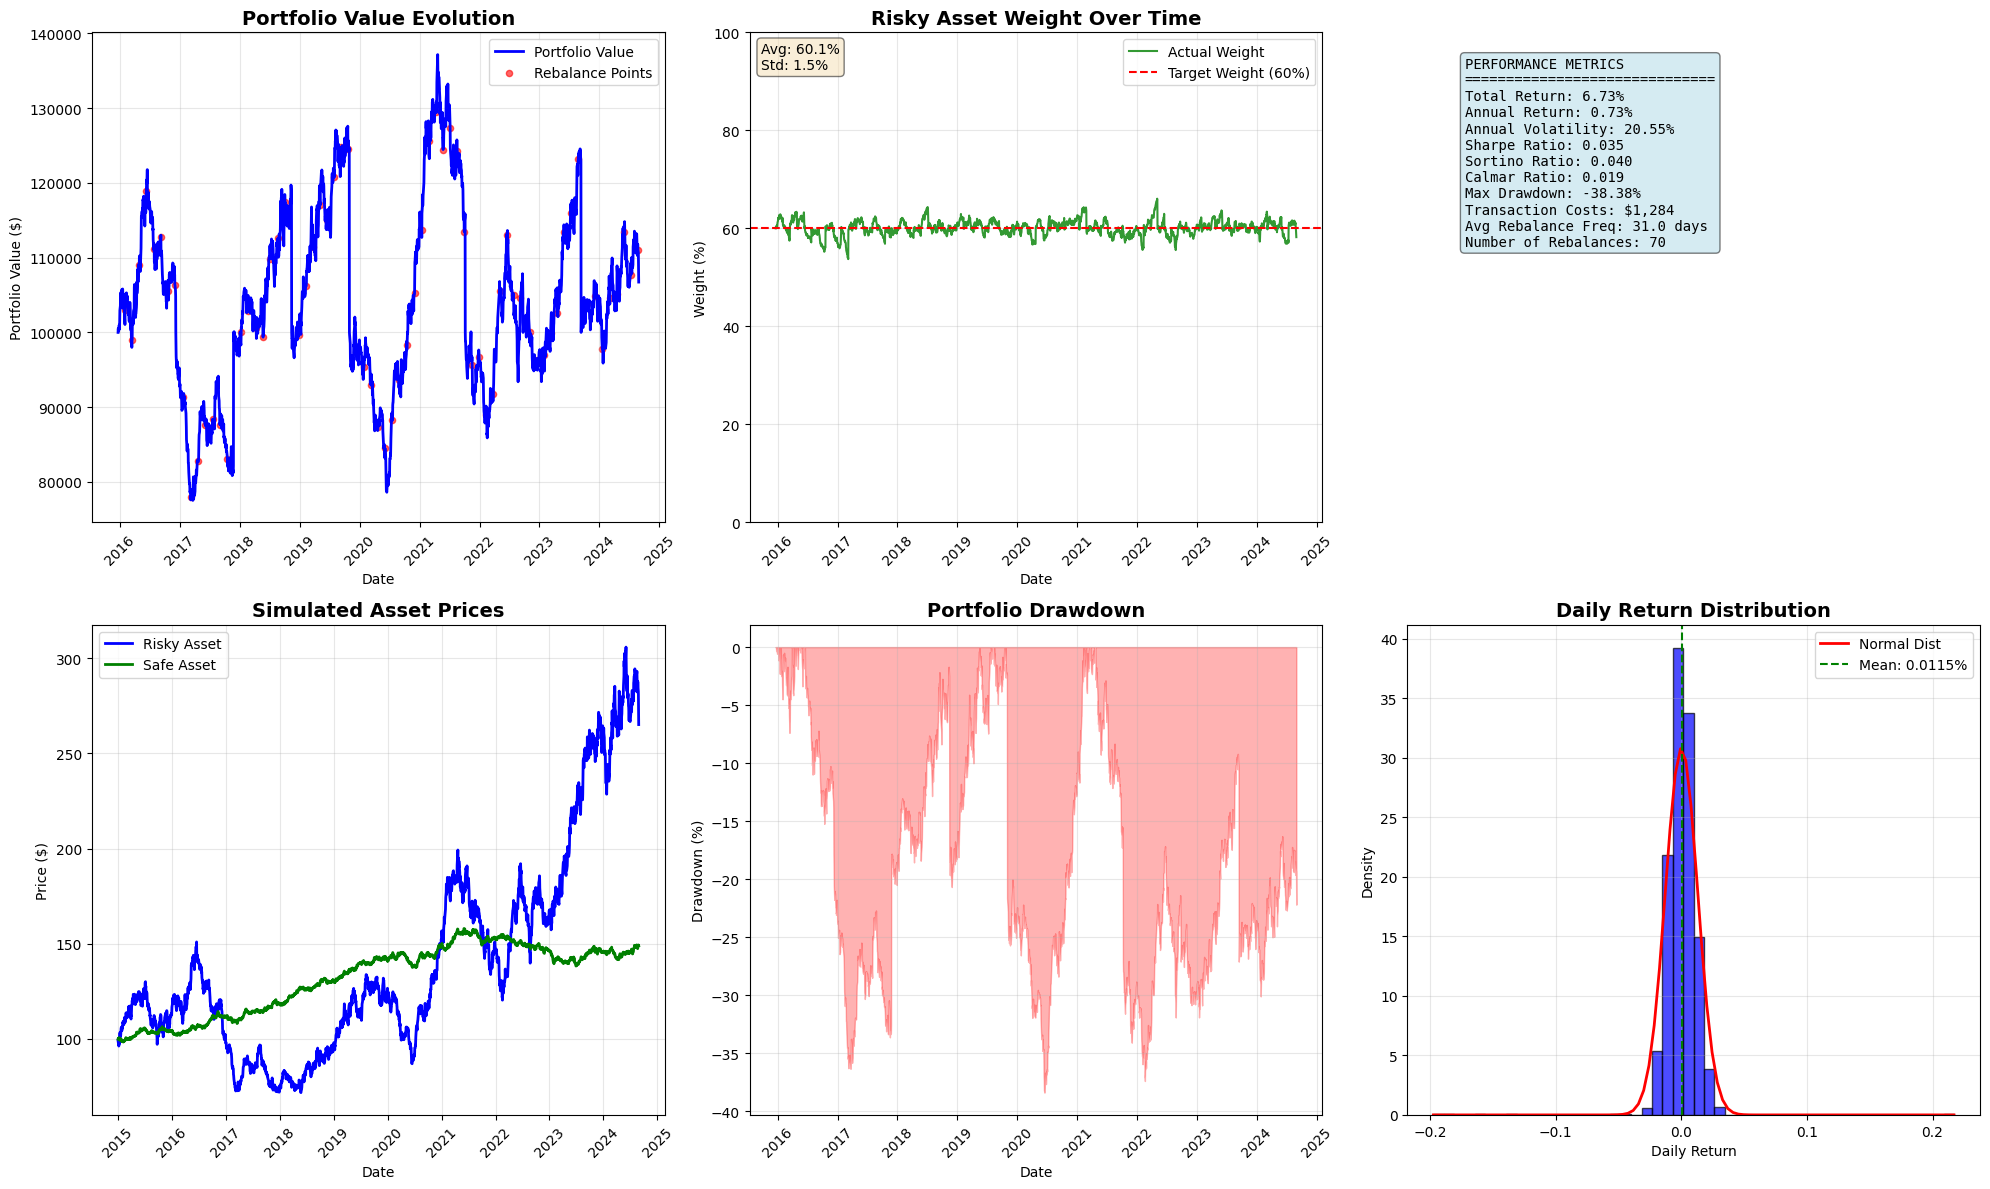


ADDITIONAL ANALYSIS

Buy-and-Hold Strategies (Initial: $100,000):
  Risky Only: $267,125.93 (167.13%)
  Safe Only: $149,013.51 (49.01%)
  Equal Weight: $208,069.72 (108.07%)
  Rebalanced Portfolio: $106,731.52 (6.73%)

Risk Metrics:
  Value at Risk (95%): -1.5259%
  Expected Shortfall (95%): -2.5032%
  Skewness: -2.108
  Excess Kurtosis: 91.447

Rebalancing Frequency Analysis:
  Min Optimal h: 30 days
  Max Optimal h: 32 days
  Std of Optimal h: 0.7 days


In [27]:
# ======================
# MONTE CARLO SIMULATION
# ======================
def generate_mc_returns(annual_return=0.08, annual_volatility=0.20,
                         correlation=0.3, years=10, trading_days=252,
                         seed=42):
    """
    Generate correlated asset returns using Monte Carlo simulation.

    Parameters:
    -----------
    annual_return : float
        Annual expected return for risky asset
    annual_volatility : float
        Annual volatility for risky asset
    correlation : float
        Correlation between risky and safe assets
    years : int
        Number of years to simulate
    trading_days : int
        Trading days per year
    seed : int
        Random seed for reproducibility

    Returns:
    --------
    tuple : (prices_risky, prices_safe, returns_risky, returns_safe)
    """
    np.random.seed(seed)

    n_days = years * trading_days

    # Generate correlated returns
    # Asset 1: Risky (e.g., stock), Asset 2: Safe (e.g., bond)
    mean_returns = np.array([annual_return/trading_days, 0.03/trading_days])
    volatilities = np.array([annual_volatility/np.sqrt(trading_days), 0.05/np.sqrt(trading_days)])

    # Correlation matrix
    corr_matrix = np.array([[1.0, correlation],
                           [correlation, 1.0]])

    # Covariance matrix
    cov_matrix = np.diag(volatilities) @ corr_matrix @ np.diag(volatilities)

    # Generate correlated random numbers
    returns = np.random.multivariate_normal(mean_returns, cov_matrix, n_days)

    # Convert to prices (starting at 100)
    prices_risky = 100 * np.exp(np.cumsum(returns[:, 0]))
    prices_safe = 100 * np.exp(np.cumsum(returns[:, 1]))

    # Create DataFrames
    dates = pd.date_range(start='2015-01-01', periods=n_days, freq='B')
    prices_df = pd.DataFrame({
        'Risky': prices_risky,
        'Safe': prices_safe
    }, index=dates)

    returns_df = pd.DataFrame({
        'Risky': returns[:, 0],
        'Safe': returns[:, 1]
    }, index=dates)

    return prices_df, returns_df

# ======================
# OPTIMAL INTERVAL CALCULATION
# ======================
def calculate_optimal_interval(w_star, daily_vol, lambda_val, c):
    """
    Calculate optimal rebalancing interval using cube-root rule.

    Parameters:
    -----------
    w_star : float
        Target weight in risky asset
    daily_vol : float
        Daily portfolio volatility
    lambda_val : float
        Drift penalty parameter
    c : float
        Proportional transaction cost

    Returns:
    --------
    float : Optimal rebalancing interval in days
    """
    v = (w_star * (1 - w_star) * daily_vol) ** 2
    a = c * np.sqrt(2 * v / np.pi)
    b = lambda_val * v / 2

    if b > 0:
        h_optimal = (a / (2 * b)) ** (2/3)
    else:
        h_optimal = 22  # Default monthly rebalancing

    return max(5, min(h_optimal, 252))  # Bound between 5 and 252 days

# ======================
# WALK-FORWARD BACKTEST
# ======================
def walk_forward_backtest_mc(prices_df, w_star=0.6, c=0.005,
                            lambda_val=0.01, train_days=252, test_days=252):
    """
    Perform Walk-Forward backtesting on Monte Carlo simulated data.

    Parameters:
    -----------
    prices_df : DataFrame
        Asset prices with columns ['Risky', 'Safe']
    w_star : float
        Target weight in risky asset
    c : float
        Proportional transaction cost
    lambda_val : float
        Drift penalty parameter
    train_days : int
        Training window size in days
    test_days : int
        Testing window size in days

    Returns:
    --------
    dict : Performance metrics and results
    """
    # Initialize results storage
    all_portfolio_values = []
    all_dates = []
    all_optimal_h = []
    all_transaction_costs = []
    all_risky_weights = []
    rebalance_dates = []

    # Parameters
    initial_capital = 100000
    n_windows = (len(prices_df) - train_days - test_days) // test_days + 1

    # Walk through the data
    for window in range(n_windows):
        start_idx = window * test_days
        train_end = start_idx + train_days
        test_end = train_end + test_days

        # Extract windows
        train_prices = prices_df.iloc[start_idx:train_end]
        test_prices = prices_df.iloc[train_end:test_end]

        # Calculate returns from training data
        train_returns = train_prices.pct_change().dropna()

        # Calculate portfolio statistics
        weights = np.array([w_star, 1 - w_star])
        cov_matrix = train_returns.cov()
        portfolio_variance = weights.T @ cov_matrix @ weights
        daily_vol = np.sqrt(portfolio_variance)

        # Calculate optimal rebalancing interval
        h_optimal = calculate_optimal_interval(w_star, daily_vol, lambda_val, c)
        h_optimal = int(np.round(h_optimal))
        all_optimal_h.append(h_optimal)

        # Initialize portfolio for testing window
        risky_shares = (initial_capital * w_star) / test_prices.iloc[0]['Risky']
        safe_shares = (initial_capital * (1 - w_star)) / test_prices.iloc[0]['Safe']

        transaction_costs_window = 0
        portfolio_values = []
        risky_weights_window = []

        # Backtest through testing window
        for i in range(len(test_prices)):
            current_date = test_prices.index[i]
            current_risky = test_prices.iloc[i]['Risky']
            current_safe = test_prices.iloc[i]['Safe']

            # Calculate current portfolio value
            risky_value = risky_shares * current_risky
            safe_value = safe_shares * current_safe
            portfolio_value = risky_value + safe_value

            # Calculate current risky weight
            current_risky_weight = risky_value / portfolio_value

            portfolio_values.append(portfolio_value)
            all_dates.append(current_date)
            risky_weights_window.append(current_risky_weight)

            # Check for rebalancing (skip first day)
            if i > 0 and i % h_optimal == 0:
                rebalance_dates.append(current_date)

                # Calculate target values
                target_risky = portfolio_value * w_star
                target_safe = portfolio_value * (1 - w_star)

                # Calculate trades
                trade_risky = target_risky - risky_value
                trade_safe = target_safe - safe_value

                # Calculate transaction cost
                transaction_cost = c * (abs(trade_risky) + abs(trade_safe))
                transaction_costs_window += transaction_cost

                # Execute trades
                if trade_risky != 0:
                    risky_shares += trade_risky / current_risky
                if trade_safe != 0:
                    safe_shares += trade_safe / current_safe

                # Deduct transaction cost
                portfolio_value -= transaction_cost

        # Store results for this window
        all_portfolio_values.extend(portfolio_values)
        all_transaction_costs.append(transaction_costs_window)
        all_risky_weights.extend(risky_weights_window)

    # Create time series
    portfolio_series = pd.Series(all_portfolio_values, index=all_dates)
    risky_weight_series = pd.Series(all_risky_weights, index=all_dates)

    # Calculate performance metrics
    returns = portfolio_series.pct_change().dropna()
    trading_days_per_year = 252

    total_return = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) - 1
    annual_return = (1 + total_return) ** (trading_days_per_year / len(portfolio_series)) - 1
    volatility = returns.std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = annual_return / volatility if volatility > 0 else 0

    # Maximum drawdown
    rolling_max = portfolio_series.expanding().max()
    drawdowns = (portfolio_series - rolling_max) / rolling_max
    max_drawdown = drawdowns.min()

    # Sortino ratio
    negative_returns = returns[returns < 0]
    downside_dev = negative_returns.std() * np.sqrt(trading_days_per_year) if len(negative_returns) > 0 else 0
    sortino_ratio = annual_return / downside_dev if downside_dev > 0 else 0

    # Calmar ratio
    calmar_ratio = annual_return / abs(max_drawdown) if max_drawdown < 0 else 0

    # Total transaction costs
    total_transaction_costs = sum(all_transaction_costs)
    avg_optimal_h = np.mean(all_optimal_h)

    # Weight statistics
    avg_risky_weight = risky_weight_series.mean()
    std_risky_weight = risky_weight_series.std()

    results = {
        'Total Return': total_return,
        'Annual Return': annual_return,
        'Annual Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Calmar Ratio': calmar_ratio,
        'Max Drawdown': max_drawdown,
        'Total Transaction Costs': total_transaction_costs,
        'Average Rebalance Frequency': avg_optimal_h,
        'Average Risky Weight': avg_risky_weight,
        'Risky Weight Std Dev': std_risky_weight,
        'Number of Rebalances': len(rebalance_dates),
        'Number of Windows': n_windows,
        'Portfolio Series': portfolio_series,
        'Risky Weight Series': risky_weight_series,
        'Rebalance Dates': rebalance_dates,
        'Optimal Intervals': all_optimal_h
    }

    return results

# ======================
# VISUALIZATION
# ======================
def plot_backtest_results(results, prices_df):
    """
    Create comprehensive visualizations of backtest results.

    Parameters:
    -----------
    results : dict
        Results from walk_forward_backtest_mc
    prices_df : DataFrame
        Original price data
    """
    portfolio_series = results['Portfolio Series']
    risky_weight_series = results['Risky Weight Series']
    rebalance_dates = results['Rebalance Dates']

    fig = plt.figure(figsize=(20, 12))

    # 1. Portfolio Value Over Time
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(portfolio_series.index, portfolio_series.values,
             'b-', linewidth=2, label='Portfolio Value')
    ax1.set_title('Portfolio Value Evolution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    # Mark rebalance points
    if rebalance_dates:
        rebalance_values = portfolio_series[portfolio_series.index.isin(rebalance_dates)]
        ax1.scatter(rebalance_values.index, rebalance_values.values,
                   color='red', s=20, alpha=0.6, label='Rebalance Points')
    ax1.legend()

    # 2. Risky Asset Weight Over Time
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(risky_weight_series.index, risky_weight_series.values * 100,
             'g-', linewidth=1.5, alpha=0.8, label='Actual Weight')
    ax2.axhline(y=60, color='r', linestyle='--', linewidth=1.5,
               label='Target Weight (60%)')
    ax2.set_title('Risky Asset Weight Over Time', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Weight (%)')
    ax2.set_ylim([0, 100])
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend()

    # Add weight statistics
    weight_stats = f"Avg: {risky_weight_series.mean()*100:.1f}%\nStd: {risky_weight_series.std()*100:.1f}%"
    ax2.text(0.02, 0.98, weight_stats, transform=ax2.transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 3. Performance Metrics Table
    ax3 = plt.subplot(2, 3, 3)
    ax3.axis('off')

    metrics_text = "PERFORMANCE METRICS\n" + "="*30 + "\n"
    metrics_text += f"Total Return: {results['Total Return']:.2%}\n"
    metrics_text += f"Annual Return: {results['Annual Return']:.2%}\n"
    metrics_text += f"Annual Volatility: {results['Annual Volatility']:.2%}\n"
    metrics_text += f"Sharpe Ratio: {results['Sharpe Ratio']:.3f}\n"
    metrics_text += f"Sortino Ratio: {results['Sortino Ratio']:.3f}\n"
    metrics_text += f"Calmar Ratio: {results['Calmar Ratio']:.3f}\n"
    metrics_text += f"Max Drawdown: {results['Max Drawdown']:.2%}\n"
    metrics_text += f"Transaction Costs: ${results['Total Transaction Costs']:,.0f}\n"
    metrics_text += f"Avg Rebalance Freq: {results['Average Rebalance Frequency']:.1f} days\n"
    metrics_text += f"Number of Rebalances: {results['Number of Rebalances']}"

    ax3.text(0.1, 0.95, metrics_text, fontsize=10, fontfamily='monospace',
             verticalalignment='top', transform=ax3.transAxes,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    # 4. Asset Prices
    ax4 = plt.subplot(2, 3, 4)
    ax4.plot(prices_df.index, prices_df['Risky'], 'b-', label='Risky Asset', linewidth=2)
    ax4.plot(prices_df.index, prices_df['Safe'], 'g-', label='Safe Asset', linewidth=2)
    ax4.set_title('Simulated Asset Prices', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Price ($)')
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
    ax4.legend()

    # 5. Drawdown Analysis
    ax5 = plt.subplot(2, 3, 5)
    rolling_max = portfolio_series.expanding().max()
    drawdown = (portfolio_series - rolling_max) / rolling_max * 100
    ax5.fill_between(portfolio_series.index, drawdown.values, 0,
                     color='red', alpha=0.3)
    ax5.set_title('Portfolio Drawdown', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Drawdown (%)')
    ax5.grid(True, alpha=0.3)
    ax5.tick_params(axis='x', rotation=45)

    # 6. Return Distribution
    ax6 = plt.subplot(2, 3, 6)
    returns = portfolio_series.pct_change().dropna()

    if len(returns) > 10:
        ax6.hist(returns, bins=50, alpha=0.7, color='blue',
                 edgecolor='black', density=True)

        # Add normal distribution
        x = np.linspace(returns.min(), returns.max(), 100)
        mu, sigma = returns.mean(), returns.std()
        normal_dist = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
        ax6.plot(x, normal_dist, 'r-', linewidth=2, label='Normal Dist')

        ax6.axvline(x=mu, color='green', linestyle='--',
                   label=f'Mean: {mu:.4%}')
        ax6.set_title('Daily Return Distribution', fontsize=14, fontweight='bold')
        ax6.set_xlabel('Daily Return')
        ax6.set_ylabel('Density')
        ax6.legend()
        ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ======================
# MAIN EXECUTION
# ======================
def main():
    print("=" * 70)
    print("MONTE CARLO WALK-FORWARD BACKTESTING")
    print("=" * 70)

    # Parameters
    mc_params = {
        'annual_return': 0.10,       # 10% expected annual return for risky asset
        'annual_volatility': 0.25,   # 25% annual volatility for risky asset
        'correlation': 0.2,          # 20% correlation between assets
        'years': 10,                 # 10 years of data
        'trading_days': 252,         # Trading days per year
        'seed': 42                   # Random seed for reproducibility
    }

    backtest_params = {
        'w_star': 0.6,               # 60% in risky asset
        'c': 0.005,                  # 50 bps transaction cost
        'lambda_val': 0.01,          # Drift penalty
        'train_days': 252,           # 1-year training window
        'test_days': 252             # 1-year testing window
    }

    # Step 1: Generate Monte Carlo data
    prices_df, returns_df = generate_mc_returns(**mc_params)

    print(f"Generated {len(prices_df)} days of data")
    print(f"Risky asset statistics:")
    print(f"  Final price: ${prices_df['Risky'].iloc[-1]:.2f}")
    print(f"  Total return: {(prices_df['Risky'].iloc[-1]/prices_df['Risky'].iloc[0]-1):.2%}")
    print(f"  Daily volatility: {returns_df['Risky'].std():.4f}")

    # Step 2: Perform Walk-Forward backtest
    results = walk_forward_backtest_mc(prices_df, **backtest_params)

    # Step 3: Display results
    print("\n" + "=" * 70)
    print("BACKTEST RESULTS")
    print("=" * 70)

    print(f"\nPerformance Metrics:")
    print("-" * 40)
    print(f"Total Return: {results['Total Return']:.2%}")
    print(f"Annual Return: {results['Annual Return']:.2%}")
    print(f"Annual Volatility: {results['Annual Volatility']:.2%}")
    print(f"Sharpe Ratio: {results['Sharpe Ratio']:.3f}")
    print(f"Sortino Ratio: {results['Sortino Ratio']:.3f}")
    print(f"Calmar Ratio: {results['Calmar Ratio']:.3f}")
    print(f"Maximum Drawdown: {results['Max Drawdown']:.2%}")
    print(f"Total Transaction Costs: ${results['Total Transaction Costs']:,.2f}")
    print(f"Average Rebalance Frequency: {results['Average Rebalance Frequency']:.1f} days")
    print(f"Number of Rebalances: {results['Number of Rebalances']}")
    print(f"Number of Windows: {results['Number of Windows']}")
    print(f"Average Risky Weight: {results['Average Risky Weight']:.1%}")
    print(f"Risky Weight Std Dev: {results['Risky Weight Std Dev']:.1%}")

    # Step 4: Create visualizations
    plot_backtest_results(results, prices_df)

    # Additional analysis
    print("\n" + "=" * 70)
    print("ADDITIONAL ANALYSIS")
    print("=" * 70)

    # Compare with buy-and-hold
    initial_capital = 100000
    risky_only = initial_capital * (prices_df['Risky'].iloc[-1] / prices_df['Risky'].iloc[0])
    safe_only = initial_capital * (prices_df['Safe'].iloc[-1] / prices_df['Safe'].iloc[0])
    equal_weight = 0.5 * risky_only + 0.5 * safe_only

    print(f"\nBuy-and-Hold Strategies (Initial: ${initial_capital:,}):")
    print(f"  Risky Only: ${risky_only:,.2f} ({(risky_only/initial_capital-1):.2%})")
    print(f"  Safe Only: ${safe_only:,.2f} ({(safe_only/initial_capital-1):.2%})")
    print(f"  Equal Weight: ${equal_weight:,.2f} ({(equal_weight/initial_capital-1):.2%})")
    print(f"  Rebalanced Portfolio: ${results['Portfolio Series'].iloc[-1]:,.2f} ({results['Total Return']:.2%})")

    # Risk metrics
    portfolio_returns = results['Portfolio Series'].pct_change().dropna()

    # VaR (95%)
    var_95 = np.percentile(portfolio_returns, 5)
    print(f"\nRisk Metrics:")
    print(f"  Value at Risk (95%): {var_95:.4%}")

    # Expected Shortfall (95%)
    es_95 = portfolio_returns[portfolio_returns <= var_95].mean()
    print(f"  Expected Shortfall (95%): {es_95:.4%}")

    # Skewness and Kurtosis
    skewness = portfolio_returns.skew()
    kurtosis = portfolio_returns.kurtosis()
    print(f"  Skewness: {skewness:.3f}")
    print(f"  Excess Kurtosis: {kurtosis:.3f}")

    # Window-by-window analysis
    if 'Optimal Intervals' in results:
        print(f"\nRebalancing Frequency Analysis:")
        print(f"  Min Optimal h: {min(results['Optimal Intervals']):.0f} days")
        print(f"  Max Optimal h: {max(results['Optimal Intervals']):.0f} days")
        print(f"  Std of Optimal h: {np.std(results['Optimal Intervals']):.1f} days")

    return results, prices_df

# ======================
# RUN THE ANALYSIS
# ======================
if __name__ == "__main__":
    # Execute the main analysis
    results, prices_df = main()

Try Pair Trading as what we have learned from previous literature review.

Cointegration:
- Cointegration is high when two quantities move together or remain close to each other
- Cointegration is nonexistent if the two quantities do not stay together

PAIRS TRADING IMPLEMENTATION
Pair: KO - PEP
Period: 2020-01-01 to 2024-01-01
STEP 1: Downloading data...


[*********************100%***********************]  2 of 2 completed

Downloaded 1006 data points

STEP 2: Cointegration analysis...

ADF Test on Spread:
ADF Statistic (Spread): -3.1766
p-value: 0.0214
Critical Values:
	1%: -3.4370
	5%: -2.8645
	10%: -2.5683

Johansen Cointegration Test:
Trace Statistics: [11.51514633  2.27632972]
Critical Values (90%, 95%, 99%): [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Eigenvalues: [0.0091598  0.00226469]

STEP 3: Running pairs trading strategy...
Hedge Ratio (beta): 0.2906
Intercept (alpha): 9.2481



STEP 4: Backtesting strategy...

PERFORMANCE RESULTS
Total Return        : -96.25%
Annual Return       : -56.06%
Annual Volatility   : 51.34%
Sharpe Ratio        : -1.092
Sortino Ratio       : -0.183
Calmar Ratio        : -0.582
Max Drawdown        : -96.27%
Win Rate            : 25.9%
Profit Factor       : 0.01
Total Trades        : 27
Winning Trades      : 7
Initial Capital     : $100,000
Final Capital       : $3,752.13

Generating visualizations...


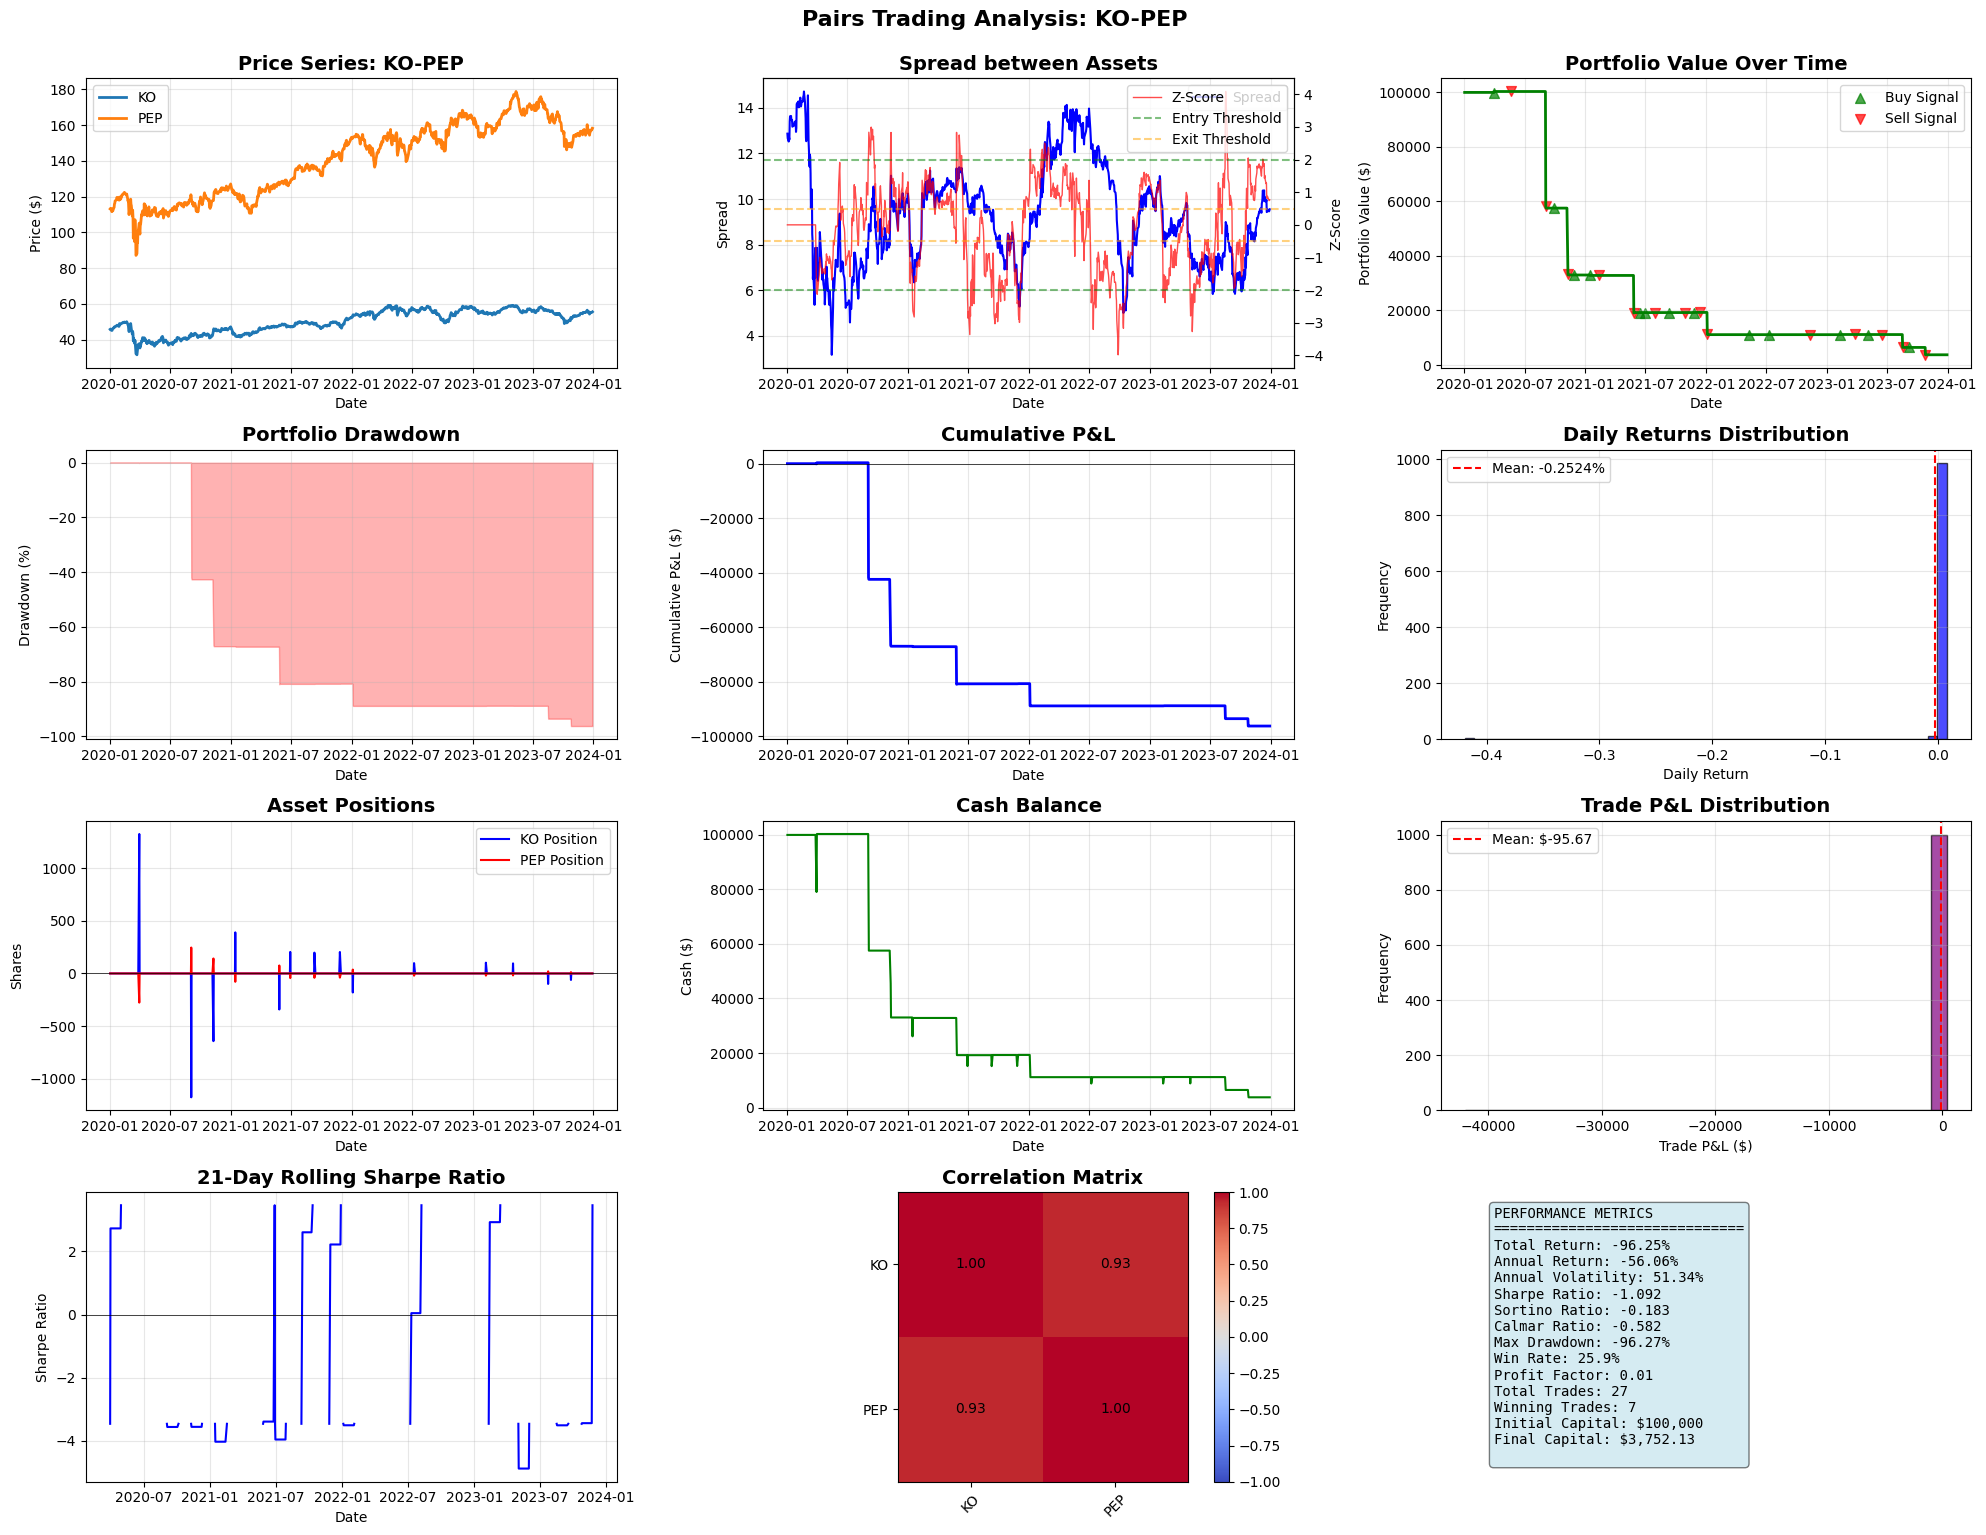


TRADE LOG

Total trades: 27

Trade details:
         date      action    zscore
0  2020-03-30         buy -2.072804
1  2020-05-20   exit_long -0.477824
2  2020-09-03        sell  2.116516
3  2020-09-28  exit_short  0.433059
4  2020-11-09        sell  2.601806
5  2020-11-27  exit_short  0.449480
6  2021-01-14         buy -2.312648
7  2021-02-10   exit_long -0.314219
8  2021-05-27        sell  2.830957
9  2021-06-16  exit_short  0.025717
10 2021-06-29         buy -2.224489
11 2021-07-29   exit_long -0.379917
12 2021-09-10         buy -2.219800
13 2021-10-29   exit_long -0.286740
14 2021-11-26         buy -2.409020
15 2021-12-13   exit_long  0.248645
16 2022-01-04        sell  2.049304
17 2022-05-10  exit_short  0.460765
18 2022-07-08         buy -2.387145
19 2022-11-10   exit_long -0.402485
20 2023-02-10         buy -2.227062
21 2023-03-27   exit_long -0.494898
22 2023-05-03         buy -2.386622
23 2023-06-16   exit_long -0.444550
24 2023-08-17        sell  3.660329
25 2023-09-06  exit

In [28]:
# ======================
# DATA DOWNLOAD & PREPARATION
# ======================
def download_asset_data(tickers, start_date, end_date, interval='1d'):
    """
    Download asset data from Yahoo Finance.

    Parameters:
    -----------
    tickers : list
        List of ticker symbols
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
    interval : str
        Data interval ('1d', '1h', '1m', etc.)

    Returns:
    --------
    DataFrame with close prices
    """
    print(f"Downloading data for {tickers}...")
    data = yf.download(tickers, start=start_date, end=end_date, interval=interval)

    if len(tickers) == 1:
        data = data[['Close']]
        data.columns = tickers
    else:
        data = data['Close']

    print(f"Downloaded {len(data)} data points")
    return data.dropna()

# %%
# ======================
# COINTEGRATION ANALYSIS
# ======================
class CointegrationAnalyzer:
    """Class for cointegration analysis and pair selection."""

    @staticmethod
    def calculate_spread(p1, p2, method='ols'):
        """
        Calculate spread between two price series.

        Parameters:
        -----------
        p1, p2 : Series
            Price series
        method : str
            'ols' for ordinary least squares, 'ratio' for simple ratio

        Returns:
        --------
        Series of spread values
        """
        if method == 'ols':
            # Linear regression: p1 = beta * p2 + alpha
            X = np.vstack([np.ones(len(p2)), p2.values]).T
            beta = np.linalg.lstsq(X, p1.values, rcond=None)[0]
            spread = p1 - (beta[0] + beta[1] * p2)
        elif method == 'ratio':
            spread = p1 / p2
        else:
            raise ValueError("method must be 'ols' or 'ratio'")

        return spread

    @staticmethod
    def adf_test(series, title=''):
        """Perform Augmented Dickey-Fuller test for stationarity."""
        result = adfuller(series.dropna())
        print(f'ADF Statistic ({title}): {result[0]:.4f}')
        print(f'p-value: {result[1]:.4f}')
        print(f'Critical Values:')
        for key, value in result[4].items():
            print(f'\t{key}: {value:.4f}')
        return result

    @staticmethod
    def johansen_test(data, lag=1):
        """Perform Johansen cointegration test."""
        result = coint_johansen(data, 0, lag)
        print(f"Trace Statistics: {result.lr1}")
        print(f"Critical Values (90%, 95%, 99%): {result.cvt}")
        print(f"Eigenvalues: {result.eig}")
        return result

    @staticmethod
    def find_cointegrated_pairs(prices_df, pvalue_threshold=0.05):
        """
        Find cointegrated pairs among multiple assets.

        Returns:
        --------
        DataFrame with pairs and their cointegration statistics
        """
        n = prices_df.shape[1]
        pairs = []

        for i in range(n):
            for j in range(i+1, n):
                ticker1 = prices_df.columns[i]
                ticker2 = prices_df.columns[j]

                # Test for cointegration
                score, pvalue, _ = coint(prices_df.iloc[:, i], prices_df.iloc[:, j])

                if pvalue < pvalue_threshold:
                    # Calculate hedge ratio
                    X = np.vstack([np.ones(len(prices_df)),
                                   prices_df.iloc[:, j].values]).T
                    beta = np.linalg.lstsq(X, prices_df.iloc[:, i].values, rcond=None)[0]

                    pairs.append({
                        'pair': f"{ticker1}-{ticker2}",
                        'pvalue': pvalue,
                        'score': score,
                        'hedge_ratio': beta[1],
                        'intercept': beta[0]
                    })

        return pd.DataFrame(pairs).sort_values('pvalue')

# %%
# ======================
# PAIRS TRADING STRATEGY
# ======================
class PairsTradingStrategy:
    """Implementation of pairs trading strategy."""

    def __init__(self, lookback_window=60, entry_threshold=2.0, exit_threshold=0.5):
        """
        Initialize pairs trading strategy.

        Parameters:
        -----------
        lookback_window : int
            Window for calculating z-score statistics
        entry_threshold : float
            Z-score threshold for entering trades
        exit_threshold : float
            Z-score threshold for exiting trades
        """
        self.lookback_window = lookback_window
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold

        # State variables
        self.position = 0  # 1: long spread, -1: short spread, 0: flat
        self.trades = []

    def calculate_zscore(self, spread, current_idx):
        """Calculate z-score of spread."""
        if current_idx < self.lookback_window:
            return 0

        window = spread.iloc[current_idx-self.lookback_window:current_idx]
        current_val = spread.iloc[current_idx]

        mean = window.mean()
        std = window.std()

        if std == 0:
            return 0

        return (current_val - mean) / std

    def generate_signals(self, p1, p2, hedge_ratio=None, method='ols'):
        """
        Generate trading signals for a pair.

        Parameters:
        -----------
        p1, p2 : Series
            Price series
        hedge_ratio : float or None
            Pre-calculated hedge ratio. If None, calculate dynamically
        method : str
            Method for spread calculation

        Returns:
        --------
        DataFrame with signals and positions
        """
        # Calculate spread
        if hedge_ratio is None:
            spread = self.calculate_spread(p1, p2, method)
        else:
            spread = p1 - hedge_ratio * p2

        # Initialize results DataFrame
        results = pd.DataFrame(index=p1.index)
        results['price1'] = p1
        results['price2'] = p2
        results['spread'] = spread
        results['zscore'] = 0.0
        results['signal'] = 0
        results['position'] = 0

        # Track trades
        trades = []
        position = 0

        # Generate signals
        for i in range(len(results)):
            # Calculate z-score
            zscore = self.calculate_zscore(spread, i)
            results.loc[results.index[i], 'zscore'] = zscore

            # Generate signals based on position
            if position == 0:  # No position
                if zscore < -self.entry_threshold:
                    # Buy spread (long p1, short p2)
                    results.loc[results.index[i], 'signal'] = 1
                    position = 1
                    trades.append({
                        'date': results.index[i],
                        'action': 'buy',
                        'zscore': zscore
                    })
                elif zscore > self.entry_threshold:
                    # Sell spread (short p1, long p2)
                    results.loc[results.index[i], 'signal'] = -1
                    position = -1
                    trades.append({
                        'date': results.index[i],
                        'action': 'sell',
                        'zscore': zscore
                    })

            elif position == 1:  # Long spread position
                if zscore > -self.exit_threshold:
                    # Exit long position
                    results.loc[results.index[i], 'signal'] = -1
                    position = 0
                    trades.append({
                        'date': results.index[i],
                        'action': 'exit_long',
                        'zscore': zscore
                    })

            elif position == -1:  # Short spread position
                if zscore < self.exit_threshold:
                    # Exit short position
                    results.loc[results.index[i], 'signal'] = 1
                    position = 0
                    trades.append({
                        'date': results.index[i],
                        'action': 'exit_short',
                        'zscore': zscore
                    })

            results.loc[results.index[i], 'position'] = position

        self.trades = trades
        return results

    @staticmethod
    def calculate_spread(p1, p2, method='ols'):
        """Calculate spread between two price series."""
        if method == 'ols':
            X = np.vstack([np.ones(len(p2)), p2.values]).T
            beta = np.linalg.lstsq(X, p1.values, rcond=None)[0]
            return p1 - (beta[0] + beta[1] * p2)
        elif method == 'ratio':
            return p1 / p2
        else:
            raise ValueError("method must be 'ols' or 'ratio'")

# %%
# ======================
# BACKTESTING ENGINE
# ======================
class PairsTradingBacktester:
    """Backtesting engine for pairs trading strategies."""

    def __init__(self, initial_capital=100000, transaction_cost=0.001):
        """
        Initialize backtester.

        Parameters:
        -----------
        initial_capital : float
            Initial capital for backtesting
        transaction_cost : float
            Transaction cost as percentage (e.g., 0.001 for 0.1%)
        """
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost

    def backtest(self, signals_df, p1, p2, hedge_ratio=None):
        """
        Backtest pairs trading strategy.

        Parameters:
        -----------
        signals_df : DataFrame
            DataFrame with signals from strategy
        p1, p2 : Series
            Price series
        hedge_ratio : float or None
            Hedge ratio for spread calculation

        Returns:
        --------
        DataFrame with backtest results
        """
        # Initialize results
        results = signals_df.copy()
        results['returns1'] = p1.pct_change()
        results['returns2'] = p2.pct_change()
        results['portfolio_value'] = self.initial_capital
        results['cash'] = self.initial_capital
        results['p1_position'] = 0.0
        results['p2_position'] = 0.0
        results['trade_pnl'] = 0.0
        results['cumulative_pnl'] = 0.0

        # Portfolio state
        cash = self.initial_capital
        p1_shares = 0.0
        p2_shares = 0.0
        position = 0

        # Weights for dollar-neutral portfolio
        weight_p1 = 0.5
        weight_p2 = -0.5 if hedge_ratio is None else -hedge_ratio

        for i in range(1, len(results)):
            current_signal = results['signal'].iloc[i]
            prev_position = results['position'].iloc[i-1]

            # Handle position changes
            if current_signal != 0 and prev_position == 0:
                # Enter new position
                if current_signal == 1:  # Long spread
                    # Buy p1, sell p2
                    p1_target_value = cash * weight_p1
                    p2_target_value = cash * weight_p2

                    # Execute trades with transaction costs
                    p1_shares = p1_target_value / results['price1'].iloc[i] * (1 - self.transaction_cost)
                    p2_shares = p2_target_value / results['price2'].iloc[i] * (1 + self.transaction_cost)
                    cash -= p1_target_value + p2_target_value

                elif current_signal == -1:  # Short spread
                    # Sell p1, buy p2
                    p1_target_value = cash * weight_p1
                    p2_target_value = cash * weight_p2

                    p1_shares = -p1_target_value / results['price1'].iloc[i] * (1 + self.transaction_cost)
                    p2_shares = -p2_target_value / results['price2'].iloc[i] * (1 - self.transaction_cost)
                    cash -= p1_target_value + p2_target_value

            elif current_signal == 0 and prev_position != 0:
                # Exit position
                cash += p1_shares * results['price1'].iloc[i] + p2_shares * results['price2'].iloc[i]
                p1_shares = 0.0
                p2_shares = 0.0

            # Update portfolio values
            portfolio_value = cash + p1_shares * results['price1'].iloc[i] + p2_shares * results['price2'].iloc[i]

            # Calculate P&L
            if i > 0:
                prev_value = results['portfolio_value'].iloc[i-1]
                trade_pnl = portfolio_value - prev_value
            else:
                trade_pnl = 0

            # Update results
            results.loc[results.index[i], 'portfolio_value'] = portfolio_value
            results.loc[results.index[i], 'cash'] = cash
            results.loc[results.index[i], 'p1_position'] = p1_shares
            results.loc[results.index[i], 'p2_position'] = p2_shares
            results.loc[results.index[i], 'trade_pnl'] = trade_pnl
            results.loc[results.index[i], 'cumulative_pnl'] = results['trade_pnl'].cumsum().iloc[i]

        return results

    def calculate_performance_metrics(self, results_df):
        """Calculate performance metrics from backtest results."""
        # Returns
        returns = results_df['portfolio_value'].pct_change().dropna()
        total_return = (results_df['portfolio_value'].iloc[-1] / self.initial_capital) - 1

        # Annualized metrics (assuming 252 trading days)
        trading_days = 252
        annual_return = (1 + total_return) ** (trading_days / len(results_df)) - 1

        if len(returns) > 1:
            annual_volatility = returns.std() * np.sqrt(trading_days)
            sharpe_ratio = annual_return / annual_volatility if annual_volatility > 0 else 0

            # Maximum drawdown
            portfolio_values = results_df['portfolio_value']
            rolling_max = portfolio_values.expanding().max()
            drawdown = (portfolio_values - rolling_max) / rolling_max
            max_drawdown = drawdown.min()

            # Sortino ratio (only downside volatility)
            negative_returns = returns[returns < 0]
            downside_volatility = negative_returns.std() * np.sqrt(trading_days) if len(negative_returns) > 0 else 0
            sortino_ratio = annual_return / downside_volatility if downside_volatility > 0 else 0

            # Calmar ratio
            calmar_ratio = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0

            # Win rate
            winning_trades = (results_df['trade_pnl'] > 0).sum()
            total_trades = (results_df['signal'] != 0).sum()
            win_rate = winning_trades / total_trades if total_trades > 0 else 0

            # Profit factor
            gross_profit = results_df[results_df['trade_pnl'] > 0]['trade_pnl'].sum()
            gross_loss = abs(results_df[results_df['trade_pnl'] < 0]['trade_pnl'].sum())
            profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

        else:
            annual_volatility = 0
            sharpe_ratio = 0
            max_drawdown = 0
            sortino_ratio = 0
            calmar_ratio = 0
            win_rate = 0
            profit_factor = 0

        metrics = {
            'Total Return': f"{total_return:.2%}",
            'Annual Return': f"{annual_return:.2%}",
            'Annual Volatility': f"{annual_volatility:.2%}",
            'Sharpe Ratio': f"{sharpe_ratio:.3f}",
            'Sortino Ratio': f"{sortino_ratio:.3f}",
            'Calmar Ratio': f"{calmar_ratio:.3f}",
            'Max Drawdown': f"{max_drawdown:.2%}",
            'Win Rate': f"{win_rate:.1%}",
            'Profit Factor': f"{profit_factor:.2f}",
            'Total Trades': int(total_trades),
            'Winning Trades': int(winning_trades),
            'Initial Capital': f"${self.initial_capital:,.0f}",
            'Final Capital': f"${results_df['portfolio_value'].iloc[-1]:,.2f}"
        }

        return metrics

# %%
# ======================
# VISUALIZATION FUNCTIONS
# ======================
def visualize_pairs_trading(results_df, prices_df, pair_name):
    """
    Create comprehensive visualization for pairs trading results.

    Parameters:
    -----------
    results_df : DataFrame
        Backtest results
    prices_df : DataFrame
        Original price data
    pair_name : str
        Name of the trading pair
    """
    fig = plt.figure(figsize=(20, 15))

    # 1. Price Series
    ax1 = plt.subplot(4, 3, 1)
    ax1.plot(prices_df.index, prices_df.iloc[:, 0], label=prices_df.columns[0], linewidth=2)
    ax1.plot(prices_df.index, prices_df.iloc[:, 1], label=prices_df.columns[1], linewidth=2)
    ax1.set_title(f'Price Series: {pair_name}', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Spread and Z-score
    ax2 = plt.subplot(4, 3, 2)
    ax2.plot(results_df.index, results_df['spread'], 'b-', label='Spread', linewidth=1.5)
    ax2.set_title('Spread between Assets', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Spread')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax2b = ax2.twinx()
    ax2b.plot(results_df.index, results_df['zscore'], 'r-', label='Z-Score', linewidth=1, alpha=0.7)
    ax2b.axhline(y=2, color='g', linestyle='--', alpha=0.5, label='Entry Threshold')
    ax2b.axhline(y=-2, color='g', linestyle='--', alpha=0.5)
    ax2b.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Exit Threshold')
    ax2b.axhline(y=-0.5, color='orange', linestyle='--', alpha=0.5)
    ax2b.set_ylabel('Z-Score')
    ax2b.legend(loc='upper right')

    # 3. Portfolio Value
    ax3 = plt.subplot(4, 3, 3)
    ax3.plot(results_df.index, results_df['portfolio_value'], 'g-', linewidth=2)
    ax3.set_title('Portfolio Value Over Time', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Portfolio Value ($)')
    ax3.grid(True, alpha=0.3)

    # Highlight trade entries and exits
    buy_signals = results_df[results_df['signal'] == 1]
    sell_signals = results_df[results_df['signal'] == -1]

    if len(buy_signals) > 0:
        ax3.scatter(buy_signals.index, results_df.loc[buy_signals.index, 'portfolio_value'],
                   color='green', s=50, marker='^', label='Buy Signal', alpha=0.7)
    if len(sell_signals) > 0:
        ax3.scatter(sell_signals.index, results_df.loc[sell_signals.index, 'portfolio_value'],
                   color='red', s=50, marker='v', label='Sell Signal', alpha=0.7)
    ax3.legend()

    # 4. Drawdown
    ax4 = plt.subplot(4, 3, 4)
    portfolio_values = results_df['portfolio_value']
    rolling_max = portfolio_values.expanding().max()
    drawdown = (portfolio_values - rolling_max) / rolling_max * 100
    ax4.fill_between(results_df.index, drawdown, 0, color='red', alpha=0.3)
    ax4.set_title('Portfolio Drawdown', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Drawdown (%)')
    ax4.grid(True, alpha=0.3)

    # 5. Cumulative P&L
    ax5 = plt.subplot(4, 3, 5)
    ax5.plot(results_df.index, results_df['cumulative_pnl'], 'b-', linewidth=2)
    ax5.set_title('Cumulative P&L', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Cumulative P&L ($)')
    ax5.grid(True, alpha=0.3)
    ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # 6. Daily Returns Distribution
    ax6 = plt.subplot(4, 3, 6)
    returns = results_df['portfolio_value'].pct_change().dropna()
    ax6.hist(returns, bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax6.axvline(x=returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.4%}')
    ax6.set_title('Daily Returns Distribution', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Daily Return')
    ax6.set_ylabel('Frequency')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    # 7. Positions
    ax7 = plt.subplot(4, 3, 7)
    ax7.plot(results_df.index, results_df['p1_position'], 'b-', label=f'{prices_df.columns[0]} Position', linewidth=1.5)
    ax7.plot(results_df.index, results_df['p2_position'], 'r-', label=f'{prices_df.columns[1]} Position', linewidth=1.5)
    ax7.set_title('Asset Positions', fontsize=14, fontweight='bold')
    ax7.set_xlabel('Date')
    ax7.set_ylabel('Shares')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    ax7.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # 8. Cash Balance
    ax8 = plt.subplot(4, 3, 8)
    ax8.plot(results_df.index, results_df['cash'], 'g-', linewidth=1.5)
    ax8.set_title('Cash Balance', fontsize=14, fontweight='bold')
    ax8.set_xlabel('Date')
    ax8.set_ylabel('Cash ($)')
    ax8.grid(True, alpha=0.3)

    # 9. Trade P&L Distribution
    ax9 = plt.subplot(4, 3, 9)
    trade_pnl = results_df['trade_pnl'].dropna()
    if len(trade_pnl) > 0:
        ax9.hist(trade_pnl, bins=30, alpha=0.7, color='purple', edgecolor='black')
        ax9.axvline(x=trade_pnl.mean(), color='red', linestyle='--', label=f'Mean: ${trade_pnl.mean():.2f}')
        ax9.set_title('Trade P&L Distribution', fontsize=14, fontweight='bold')
        ax9.set_xlabel('Trade P&L ($)')
        ax9.set_ylabel('Frequency')
        ax9.legend()
        ax9.grid(True, alpha=0.3)

    # 10. Rolling Sharpe Ratio (21-day window)
    ax10 = plt.subplot(4, 3, 10)
    if len(returns) > 21:
        rolling_sharpe = returns.rolling(window=21).mean() / returns.rolling(window=21).std() * np.sqrt(252)
        ax10.plot(returns.index, rolling_sharpe, 'b-', linewidth=1.5)
        ax10.set_title('21-Day Rolling Sharpe Ratio', fontsize=14, fontweight='bold')
        ax10.set_xlabel('Date')
        ax10.set_ylabel('Sharpe Ratio')
        ax10.grid(True, alpha=0.3)
        ax10.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # 11. Correlation Heatmap
    ax11 = plt.subplot(4, 3, 11)
    corr_matrix = prices_df.corr()
    im = ax11.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
    ax11.set_xticks(range(len(corr_matrix.columns)))
    ax11.set_yticks(range(len(corr_matrix.columns)))
    ax11.set_xticklabels(corr_matrix.columns, rotation=45)
    ax11.set_yticklabels(corr_matrix.columns)
    ax11.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

    # Add correlation values
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            text = ax11.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                           ha="center", va="center", color="black")

    plt.colorbar(im, ax=ax11)

    # 12. Performance Metrics Table
    ax12 = plt.subplot(4, 3, 12)
    ax12.axis('off')

    # Calculate metrics
    backtester = PairsTradingBacktester()
    metrics = backtester.calculate_performance_metrics(results_df)

    metrics_text = "PERFORMANCE METRICS\n" + "="*30 + "\n"
    for key, value in metrics.items():
        metrics_text += f"{key}: {value}\n"

    ax12.text(0.1, 0.95, metrics_text, fontsize=10, fontfamily='monospace',
             verticalalignment='top', transform=ax12.transAxes,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    plt.tight_layout()
    plt.suptitle(f'Pairs Trading Analysis: {pair_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.show()


# ======================
# COMPLETE PAIRS TRADING PIPELINE
# ======================
def run_complete_pairs_trading_pipeline(ticker1, ticker2, start_date, end_date,
                                       lookback_window=60, entry_threshold=2.0,
                                       exit_threshold=0.5, initial_capital=100000):
    """
    Run complete pairs trading pipeline from data download to backtesting.

    Parameters:
    -----------
    ticker1, ticker2 : str
        Ticker symbols for the pair
    start_date, end_date : str
        Start and end dates in 'YYYY-MM-DD' format
    lookback_window : int
        Window for z-score calculation
    entry_threshold : float
        Z-score threshold for entry
    exit_threshold : float
        Z-score threshold for exit
    initial_capital : float
        Initial capital for backtest

    Returns:
    --------
    Tuple of (results_df, metrics, strategy)
    """
    # Step 1: Download data
    print("=" * 70)
    print("STEP 1: Downloading data...")
    print("=" * 70)

    prices_df = download_asset_data([ticker1, ticker2], start_date, end_date)
    p1 = prices_df[ticker1]
    p2 = prices_df[ticker2]

    # Step 2: Cointegration analysis
    print("\n" + "=" * 70)
    print("STEP 2: Cointegration analysis...")
    print("=" * 70)

    analyzer = CointegrationAnalyzer()

    # Calculate spread using OLS
    spread_ols = analyzer.calculate_spread(p1, p2, method='ols')

    # Perform ADF test on spread
    print("\nADF Test on Spread:")
    adf_result = analyzer.adf_test(spread_ols, title='Spread')

    # Perform Johansen test
    print("\nJohansen Cointegration Test:")
    johansen_result = analyzer.johansen_test(prices_df.values, lag=1)

    # Step 3: Run pairs trading strategy
    print("\n" + "=" * 70)
    print("STEP 3: Running pairs trading strategy...")
    print("=" * 70)

    strategy = PairsTradingStrategy(
        lookback_window=lookback_window,
        entry_threshold=entry_threshold,
        exit_threshold=exit_threshold
    )

    # Calculate hedge ratio from cointegration
    X = np.vstack([np.ones(len(p2)), p2.values]).T
    beta = np.linalg.lstsq(X, p1.values, rcond=None)[0]
    hedge_ratio = beta[1]

    print(f"Hedge Ratio (beta): {hedge_ratio:.4f}")
    print(f"Intercept (alpha): {beta[0]:.4f}")

    # Generate trading signals
    signals_df = strategy.generate_signals(p1, p2, hedge_ratio=hedge_ratio, method='ols')

    # Step 4: Backtest strategy
    print("\n" + "=" * 70)
    print("STEP 4: Backtesting strategy...")
    print("=" * 70)

    backtester = PairsTradingBacktester(
        initial_capital=initial_capital,
        transaction_cost=0.001  # 0.1% transaction cost
    )

    results_df = backtester.backtest(signals_df, p1, p2, hedge_ratio=hedge_ratio)

    # Calculate performance metrics
    metrics = backtester.calculate_performance_metrics(results_df)

    # Step 5: Display results
    print("\n" + "=" * 70)
    print("PERFORMANCE RESULTS")
    print("=" * 70)

    for key, value in metrics.items():
        print(f"{key:<20}: {value}")

    # Step 6: Visualize results
    print("\n" + "=" * 70)
    print("Generating visualizations...")
    print("=" * 70)

    visualize_pairs_trading(results_df, prices_df, f"{ticker1}-{ticker2}")

    return results_df, metrics, strategy


# ======================
# PARAMETER OPTIMIZATION
# ======================
def optimize_pairs_trading_parameters(p1, p2, hedge_ratio,
                                     lookback_windows=[30, 60, 90],
                                     entry_thresholds=[1.5, 2.0, 2.5],
                                     exit_thresholds=[0.0, 0.5, 1.0]):
    """
    Optimize pairs trading parameters using grid search.

    Returns:
    --------
    DataFrame with optimization results
    """
    results = []

    for lookback in lookback_windows:
        for entry in entry_thresholds:
            for exit in exit_thresholds:
                # Run strategy
                strategy = PairsTradingStrategy(
                    lookback_window=lookback,
                    entry_threshold=entry,
                    exit_threshold=exit
                )

                signals_df = strategy.generate_signals(p1, p2, hedge_ratio=hedge_ratio)

                # Backtest
                backtester = PairsTradingBacktester(initial_capital=100000)
                results_df = backtester.backtest(signals_df, p1, p2, hedge_ratio)

                # Calculate metrics
                metrics = backtester.calculate_performance_metrics(results_df)

                # Extract key metrics
                total_return = float(metrics['Total Return'].strip('%')) / 100
                sharpe_ratio = float(metrics['Sharpe Ratio'])
                max_drawdown = float(metrics['Max Drawdown'].strip('%')) / 100

                results.append({
                    'lookback_window': lookback,
                    'entry_threshold': entry,
                    'exit_threshold': exit,
                    'total_return': total_return,
                    'sharpe_ratio': sharpe_ratio,
                    'max_drawdown': max_drawdown,
                    'total_trades': int(metrics['Total Trades']),
                    'win_rate': float(metrics['Win Rate'].strip('%')) / 100
                })

    return pd.DataFrame(results)

# ======================
# MULTIPLE PAIRS ANALYSIS
# ======================
def analyze_multiple_pairs(tickers, start_date, end_date, pvalue_threshold=0.05):
    """
    Analyze multiple pairs for cointegration and select best pairs.

    Returns:
    --------
    DataFrame with cointegration results for all pairs
    """
    # Download data for all tickers
    prices_df = download_asset_data(tickers, start_date, end_date)

    # Find cointegrated pairs
    analyzer = CointegrationAnalyzer()
    coint_pairs = analyzer.find_cointegrated_pairs(prices_df, pvalue_threshold)

    print(f"Found {len(coint_pairs)} cointegrated pairs (p-value < {pvalue_threshold}):")
    print(coint_pairs)

    return coint_pairs, prices_df

# ======================
# MAIN EXECUTION
# ======================
if __name__ == "__main__":
    # Example: Run pairs trading for Coca-Cola (KO) and Pepsi (PEP)
    # These are often considered a classic pairs trading pair

    ticker1 = "KO"
    ticker2 = "PEP"
    start_date = "2020-01-01"
    end_date = "2024-01-01"

    print("=" * 70)
    print("PAIRS TRADING IMPLEMENTATION")
    print("=" * 70)
    print(f"Pair: {ticker1} - {ticker2}")
    print(f"Period: {start_date} to {end_date}")
    print("=" * 70)

    # Run complete pipeline
    results_df, metrics, strategy = run_complete_pairs_trading_pipeline(
        ticker1=ticker1,
        ticker2=ticker2,
        start_date=start_date,
        end_date=end_date,
        lookback_window=60,
        entry_threshold=2.0,
        exit_threshold=0.5,
        initial_capital=100000
    )

    # Show trade log
    print("\n" + "=" * 70)
    print("TRADE LOG")
    print("=" * 70)

    if hasattr(strategy, 'trades') and strategy.trades:
        trades_df = pd.DataFrame(strategy.trades)
        print(f"\nTotal trades: {len(trades_df)}")
        print("\nTrade details:")
        print(trades_df.to_string())
    else:
        print("No trades executed during the period.")

# ======================
# PARAMETER OPTIMIZATION
# ======================
def run_parameter_optimization_example():
    """Example of parameter optimization for pairs trading."""
    print("\n" + "=" * 70)
    print("PARAMETER OPTIMIZATION")
    print("=" * 70)

    # Download data
    prices_df = download_asset_data(["KO", "PEP"], "2020-01-01", "2024-01-01")
    p1 = prices_df["KO"]
    p2 = prices_df["PEP"]

    # Calculate hedge ratio
    X = np.vstack([np.ones(len(p2)), p2.values]).T
    beta = np.linalg.lstsq(X, p1.values, rcond=None)[0]
    hedge_ratio = beta[1]

    # Run optimization
    optimization_results = optimize_pairs_trading_parameters(
        p1, p2, hedge_ratio,
        lookback_windows=[30, 60, 90],
        entry_thresholds=[1.5, 2.0, 2.5],
        exit_thresholds=[0.0, 0.5, 1.0]
    )

    # Find best parameters by Sharpe ratio
    best_by_sharpe = optimization_results.loc[optimization_results['sharpe_ratio'].idxmax()]
    best_by_return = optimization_results.loc[optimization_results['total_return'].idxmax()]

    print("\nBest parameters by Sharpe Ratio:")
    print(best_by_sharpe)

    print("\nBest parameters by Total Return:")
    print(best_by_return)

    return optimization_results

# Uncomment to run optimization
# optimization_results = run_parameter_optimization_example()


# ======================
# MULTIPLE PAIRS ANALYSIS
# ======================
def run_multiple_pairs_analysis():
    """Example of analyzing multiple pairs."""
    print("\n" + "=" * 70)
    print("MULTIPLE PAIRS ANALYSIS")
    print("=" * 70)

    # List of potential pairs (stocks in same sector)
    consumer_staples = ["KO", "PEP", "PG", "CL", "MO"]
    tech_stocks = ["AAPL", "MSFT", "GOOGL", "META", "NVDA"]
    financials = ["JPM", "BAC", "WFC", "C", "GS"]

    # Analyze consumer staples
    print("\nAnalyzing Consumer Staples sector...")
    coint_pairs, prices_df = analyze_multiple_pairs(
        consumer_staples,
        "2020-01-01",
        "2024-01-01",
        pvalue_threshold=0.05
    )

    # If we found cointegrated pairs, run backtest on the best one
    if len(coint_pairs) > 0:
        best_pair = coint_pairs.iloc[0]['pair']
        ticker1, ticker2 = best_pair.split('-')

        print(f"\nRunning backtest on best pair: {best_pair}")
        results_df, metrics, _ = run_complete_pairs_trading_pipeline(
            ticker1, ticker2,
            "2020-01-01", "2024-01-01",
            lookback_window=60,
            entry_threshold=2.0,
            exit_threshold=0.5
        )


Also, we would like to observe the effect of different length estimation windows here.

In [29]:
def walk_forward_backtest(data, train_days, test_days, w_star=0.6,
                          c_prop=0.005, F_fixed=50, lambda_val=0.01,
                          use_cube_rule=True):
    """
    Perform Walk-Forward backtesting for periodic rebalancing strategy.
    If use_cube_rule=True: use cube-root rule (proportional cost)
    If use_cube_rule=False: use square-root rule (fixed cost)
    """

    # Initialize results storage
    all_portfolio_values = []
    all_rebalance_dates = []
    all_transaction_costs = []
    all_optimal_h = []
    all_window_stats = []

    # Walk through the data
    start_idx = 0
    window_count = 0

    while start_idx + train_days + test_days <= len(data):
        window_count += 1

        # Split data into training and testing periods
        train_data = data.iloc[start_idx:start_idx + train_days]
        test_data = data.iloc[start_idx + train_days:start_idx + train_days + test_days]

        # Estimate parameters from training window
        train_returns = train_data.pct_change().dropna()

        # Calculate portfolio statistics
        weights = np.array([w_star, 1 - w_star])
        cov_matrix = train_returns.cov()
        portfolio_variance = weights.T @ cov_matrix @ weights
        daily_vol_window = np.sqrt(portfolio_variance)

        # Calculate optimal h based on cost structure
        intervals = calculate_optimal_intervals(lambda_val, daily_vol_window, w_star, c_prop, F_fixed)
        h_optimal = intervals['h_cube'] if use_cube_rule else intervals['h_square']
        h_optimal = int(round(h_optimal))
        h_optimal = max(5, min(h_optimal, test_days))  # Bound
        all_optimal_h.append(h_optimal)

        # Backtest on testing period
        tsla_shares = (initial_capital * w_star) / test_data.iloc[0]['TSLA']
        agg_shares = (initial_capital * (1 - w_star)) / test_data.iloc[0]['AGG']

        transaction_costs_window = 0
        rebalance_count = 0

        portfolio_values = []
        portfolio_dates = []

        # Run backtest
        for i in range(len(test_data)):
            current_date = test_data.index[i]
            current_tsla = test_data.iloc[i]['TSLA']
            current_agg = test_data.iloc[i]['AGG']

            # Calculate current values
            tsla_value = tsla_shares * current_tsla
            agg_value = agg_shares * current_agg
            current_value = tsla_value + agg_value

            portfolio_values.append(current_value)
            portfolio_dates.append(current_date)

            # Check for rebalance (skip first day)
            if i > 0 and i % h_optimal == 0:
                all_rebalance_dates.append(current_date)
                rebalance_count += 1

                # Calculate target values
                target_tsla = current_value * w_star
                target_agg = current_value * (1 - w_star)

                # Trade amounts
                trade_tsla = target_tsla - tsla_value
                trade_agg = target_agg - agg_value

                # Transaction cost based on cost structure
                if use_cube_rule:
                    # Proportional cost
                    transaction_cost = c_prop * (abs(trade_tsla) + abs(trade_agg))
                else:
                    # Fixed cost
                    transaction_cost = F_fixed if (abs(trade_tsla) > 0 or abs(trade_agg) > 0) else 0

                transaction_costs_window += transaction_cost

                # Update shares
                if trade_tsla != 0:
                    tsla_shares += trade_tsla / current_tsla
                if trade_agg != 0:
                    agg_shares += trade_agg / current_agg

                # Deduct transaction cost
                current_value -= transaction_cost

        # Store results for this window
        all_portfolio_values.extend(portfolio_values)
        all_transaction_costs.append(transaction_costs_window)

        # Store window statistics
        window_return = (portfolio_values[-1] / portfolio_values[0]) - 1

        all_window_stats.append({
            'Window': window_count,
            'Optimal h': h_optimal,
            'Return': window_return,
            'Transaction Costs': transaction_costs_window,
            'Rebalances': rebalance_count
        })

        # Move to next window
        start_idx += test_days

    # Create portfolio series
    portfolio_series = pd.Series(all_portfolio_values, index=pd.date_range(
        start=data.index[train_days], periods=len(all_portfolio_values), freq='B'
    ))

    # Calculate performance metrics
    if len(portfolio_series) > 1:
        returns_series = portfolio_series.pct_change().dropna()

        total_return = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) - 1
        annual_return = (1 + total_return) ** (trading_days_per_year / len(portfolio_series)) - 1
        volatility = returns_series.std() * np.sqrt(trading_days_per_year)
        sharpe_ratio = annual_return / volatility if volatility > 0 else 0

        # Maximum drawdown
        rolling_max = portfolio_series.expanding().max()
        drawdowns = (portfolio_series - rolling_max) / rolling_max
        max_drawdown = drawdowns.min()

        # Total transaction costs
        total_transaction_costs = sum(all_transaction_costs)
        avg_optimal_h = np.mean(all_optimal_h)

        results = {
            'Total Return': total_return,
            'Annual Return': annual_return,
            'Annual Volatility': volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown,
            'Total Transaction Costs': total_transaction_costs,
            'Average Rebalance Frequency': avg_optimal_h,
            'Total Rebalances': len(all_rebalance_dates),
            'Number of Windows': window_count
        }
    else:
        results = {}

    return results, portfolio_series, all_window_stats, all_rebalance_dates


# Make sure your calculate_optimal_intervals function looks like this:
def calculate_optimal_intervals(lambda_val, daily_vol, w_star, c_prop, F_fixed):
    """Calculate optimal rebalancing intervals for both cost structures."""
    v = (w_star * (1 - w_star) * daily_vol) ** 2

    # Cube-root rule (proportional cost)
    a = c_prop * np.sqrt(2 * v / np.pi)
    b = lambda_val * v / 2
    h_cube = (a / (2 * b)) ** (2/3) if b > 0 else 0

    # Square-root rule (fixed cost)
    h_square = np.sqrt(2 * F_fixed / (lambda_val * v)) if lambda_val * v > 0 else 0

    return {
        'h_cube': max(5, min(h_cube, 252)),  # Bound between 5 and 252 days
        'h_square': max(5, min(h_square, 252)),
        'v': v,
        'lambda': lambda_val
    }



SENSITIVITY ANALYSIS: IMPACT OF INTEGER-YEAR ESTIMATION WINDOW LENGTH


[*********************100%***********************]  2 of 2 completed


Running backtest with Estimation Window = 1.0 years (252 days)...


  Completed with 8 windows. Avg h* = 25.8 days.

Running backtest with Estimation Window = 2.0 years (504 days)...
  Completed with 7 windows. Avg h* = 25.0 days.

Running backtest with Estimation Window = 3.0 years (756 days)...
  Completed with 6 windows. Avg h* = 24.5 days.

Running backtest with Estimation Window = 4.0 years (1008 days)...
  Completed with 5 windows. Avg h* = 23.8 days.


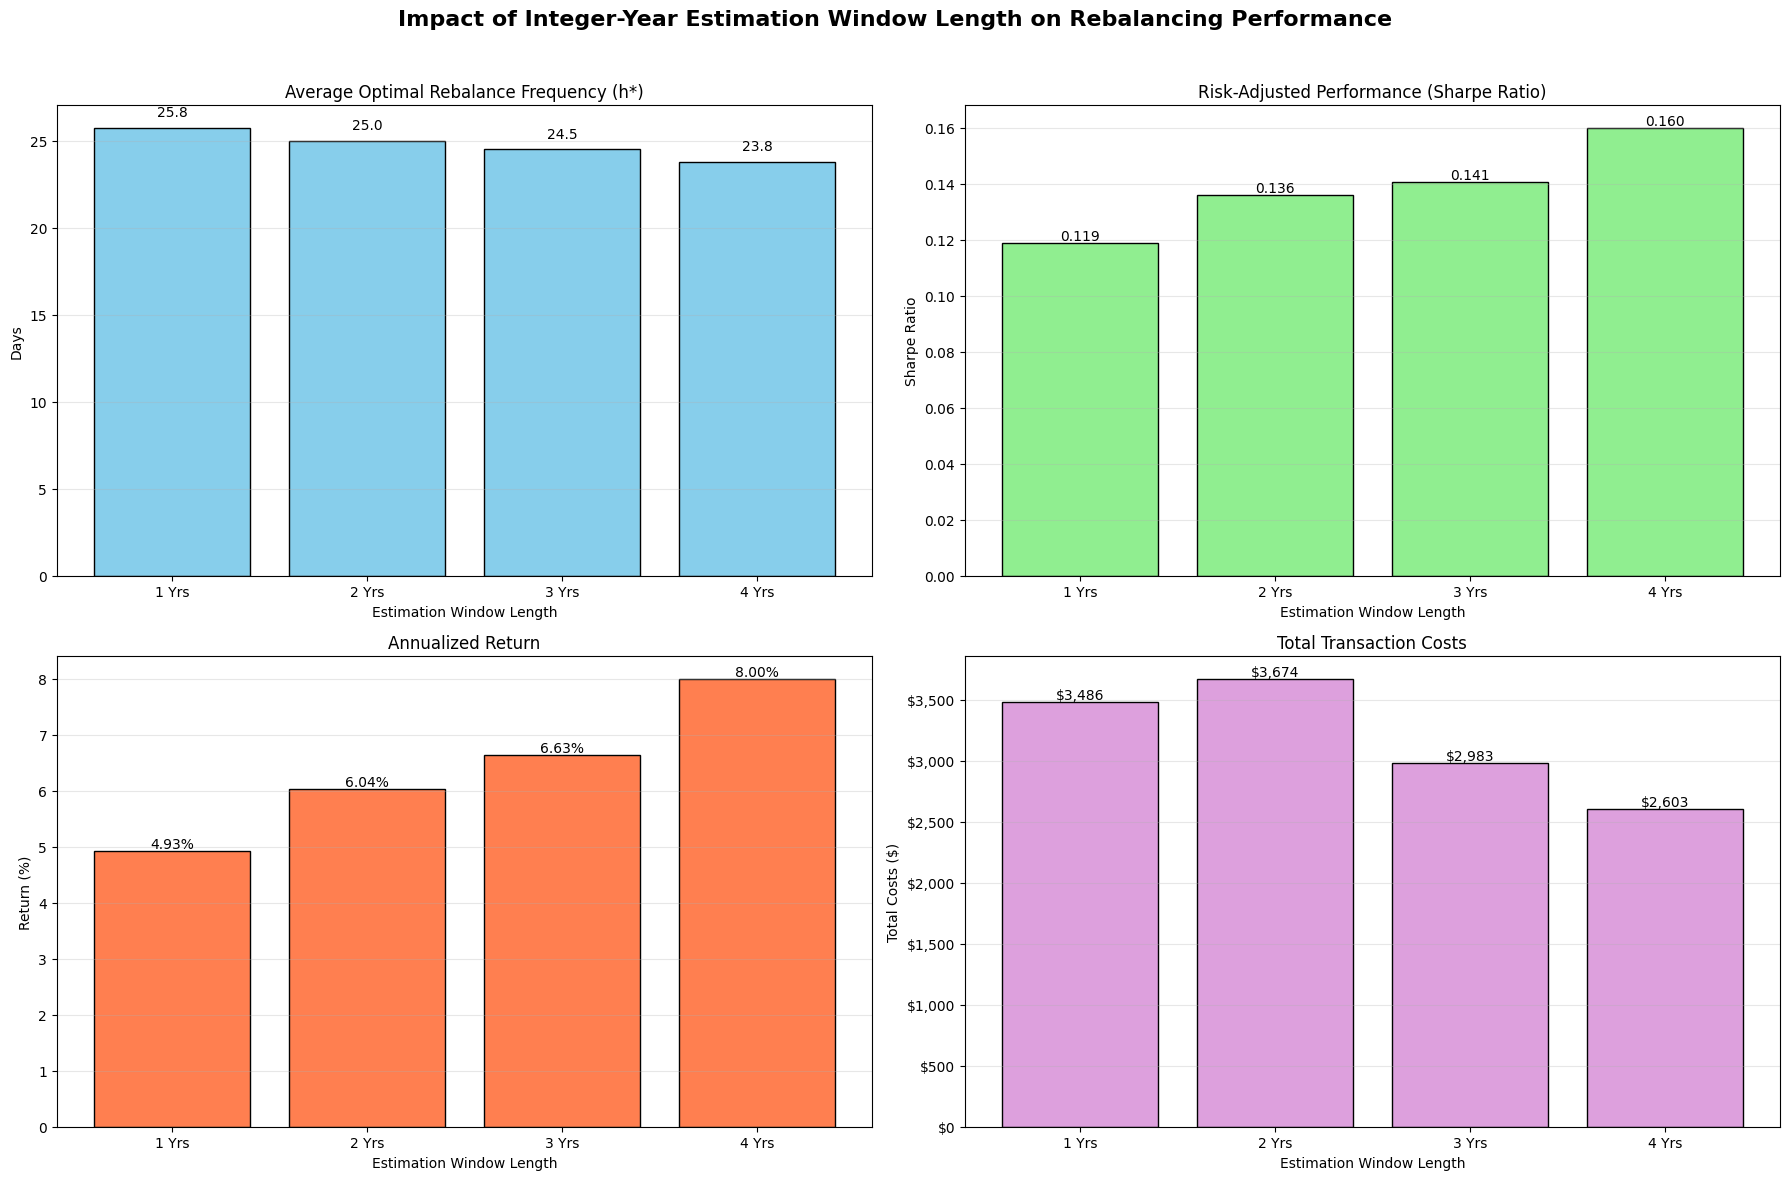


SUMMARY OF INTEGER-YEAR ESTIMATION WINDOW SENSITIVITY ANALYSIS
 Train Window (Yrs)  Annual Return  Sharpe Ratio  Max Drawdown  Total Transaction Costs ($)  Avg Rebalance Freq (days)  Num Windows
                1.0       0.049287      0.118680     -0.784970                  3486.134119                      25.75            8
                2.0       0.060373      0.135906     -0.794073                  3673.514012                      25.00            7
                3.0       0.066315      0.140618     -0.790500                  2983.283179                      24.50            6
                4.0       0.080018      0.159965     -0.784911                  2602.534157                      23.80            5


In [30]:
# ==============================================================================
# SENSITIVITY ANALYSIS: IMPACT OF INTEGER-YEAR ESTIMATION WINDOW LENGTH
# ==============================================================================
print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS: IMPACT OF INTEGER-YEAR ESTIMATION WINDOW LENGTH")
print("=" * 80)

# --- Parameters ---
# Use the same data as before
tickers = ["TSLA", "AGG"]
data_est = yf.download(tickers, start="2015-01-01", end="2025-01-01")["Close"]
data_est.columns = ['TSLA', 'AGG']

# Define the different estimation window lengths to test (in years) - ONLY INTEGER YEARS
train_window_years = [1.0, 2.0, 3.0, 4.0] # Restricted to integer years
test_years = 1.0  # Keep the testing period constant for fair comparison

trading_days_per_year = 252
test_days = int(test_years * trading_days_per_year)

# Strategy parameters (using parameters that match the walk_forward_backtest function)
w_star = 0.6
c_prop = 0.005 # Proportional cost
F_fixed = 50   # Fixed cost (used by square-root rule, but we'll use cube-root here)
lambda_val = 0.01 # Drift penalty (used by both)
use_cube_rule = True # Set to True to use the cube-root rule for rebalancing intervals

# --- Store Results ---
estimation_window_results_int_years = []

# --- Run Backtests for Each Integer Window Length ---
for train_yrs in train_window_years:
    train_days = int(train_yrs * trading_days_per_year)

    print(f"\nRunning backtest with Estimation Window = {train_yrs} years ({train_days} days)...")

    # Ensure there's enough data to run at least one full train+test window
    if len(data_est) < train_days + test_days:
        print(f"  Skipping: Not enough data for a single window ({train_days + test_days} days needed).")
        continue

    # Run the periodic rebalancing backtest
    results, _, _, _ = walk_forward_backtest(
        data=data_est,
        train_days=train_days,
        test_days=test_days,
        w_star=w_star,
        c_prop=c_prop,
        F_fixed=F_fixed,
        lambda_val=lambda_val,
        use_cube_rule=use_cube_rule
    )

    # Store the key metrics
    if results: # Check if the results dict is not empty
        metrics = {
            'Train Window (Yrs)': train_yrs,
            'Annual Return': results.get('Annual Return', 0),
            'Sharpe Ratio': results.get('Sharpe Ratio', 0),
            'Max Drawdown': results.get('Max Drawdown', 0),
            'Total Transaction Costs ($)': results.get('Total Transaction Costs', 0),
            'Avg Rebalance Freq (days)': results.get('Average Rebalance Frequency', 0),
            'Num Windows': results.get('Number of Windows', 0)
        }
        estimation_window_results_int_years.append(metrics)
        print(f"  Completed with {metrics['Num Windows']} windows. Avg h* = {metrics['Avg Rebalance Freq (days)']:.1f} days.")
    else:
        print(f"  Backtest did not return valid results for {train_yrs} years (likely due to insufficient data for any full window).")

# --- Analyze and Visualize Results ---
if estimation_window_results_int_years:
    results_df_int_years = pd.DataFrame(estimation_window_results_int_years)

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Impact of Integer-Year Estimation Window Length on Rebalancing Performance', fontsize=16, fontweight='bold')
    x_labels = [f'{int(yrs)} Yrs' for yrs in results_df_int_years['Train Window (Yrs)']] # Cast to int for labels

    # 1. Average Rebalance Frequency
    ax1 = axes[0, 0]
    ax1.bar(x_labels, results_df_int_years['Avg Rebalance Freq (days)'], color='skyblue', edgecolor='black')
    ax1.set_title('Average Optimal Rebalance Frequency (h*)')
    ax1.set_ylabel('Days')
    ax1.set_xlabel('Estimation Window Length')
    ax1.grid(True, alpha=0.3, axis='y')
    for i, val in enumerate(results_df_int_years['Avg Rebalance Freq (days)']):
        ax1.text(i, val + 0.5, f'{val:.1f}', ha='center', va='bottom')

    # 2. Sharpe Ratio
    ax2 = axes[0, 1]
    ax2.bar(x_labels, results_df_int_years['Sharpe Ratio'], color='lightgreen', edgecolor='black')
    ax2.set_title('Risk-Adjusted Performance (Sharpe Ratio)')
    ax2.set_ylabel('Sharpe Ratio')
    ax2.set_xlabel('Estimation Window Length')
    ax2.grid(True, alpha=0.3, axis='y')
    for i, val in enumerate(results_df_int_years['Sharpe Ratio']):
        ax2.text(i, val, f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top')

    # 3. Annual Return
    ax3 = axes[1, 0]
    ax3.bar(x_labels, results_df_int_years['Annual Return'] * 100, color='coral', edgecolor='black')
    ax3.set_title('Annualized Return')
    ax3.set_ylabel('Return (%)')
    ax3.set_xlabel('Estimation Window Length')
    ax3.grid(True, alpha=0.3, axis='y')
    for i, val in enumerate(results_df_int_years['Annual Return'] * 100):
        ax3.text(i, val, f'{val:.2f}%', ha='center', va='bottom' if val >= 0 else 'top')

    # 4. Total Transaction Costs
    ax4 = axes[1, 1]
    ax4.bar(x_labels, results_df_int_years['Total Transaction Costs ($)'], color='plum', edgecolor='black')
    ax4.set_title('Total Transaction Costs')
    ax4.set_ylabel('Total Costs ($)')
    ax4.set_xlabel('Estimation Window Length')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    for i, val in enumerate(results_df_int_years['Total Transaction Costs ($)']):
        ax4.text(i, val, f'${val:,.0f}', ha='center', va='bottom')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # --- Print Summary Table ---
    print("\n" + "=" * 80)
    print("SUMMARY OF INTEGER-YEAR ESTIMATION WINDOW SENSITIVITY ANALYSIS")
    print("=" * 80)
    print(results_df_int_years.to_string(index=False))
else:
    print("\nNo results to display. The integer-year estimation window analysis did not complete successfully.")



Last thing we would like to try out is, compare the use of high-frequency and the use of low-frequency data in constructing rebalancing.

[*********************100%***********************]  2 of 2 completed


UPDATED ANALYSIS: IMPACT OF VOLATILITY ESTIMATION DATA FREQ (ADJUSTED LAMBDA)

Running backtest with parameter estimation using Daily data (adjusted lambda)...


  Completed. Avg h* = 25.8 days, Sharpe = 0.119

Running backtest with parameter estimation using Weekly data (adjusted lambda)...
  Completed. Avg h* = 8.9 days, Sharpe = 0.112

Running backtest with parameter estimation using Monthly data (adjusted lambda)...
  Completed. Avg h* = 5.0 days, Sharpe = 0.110


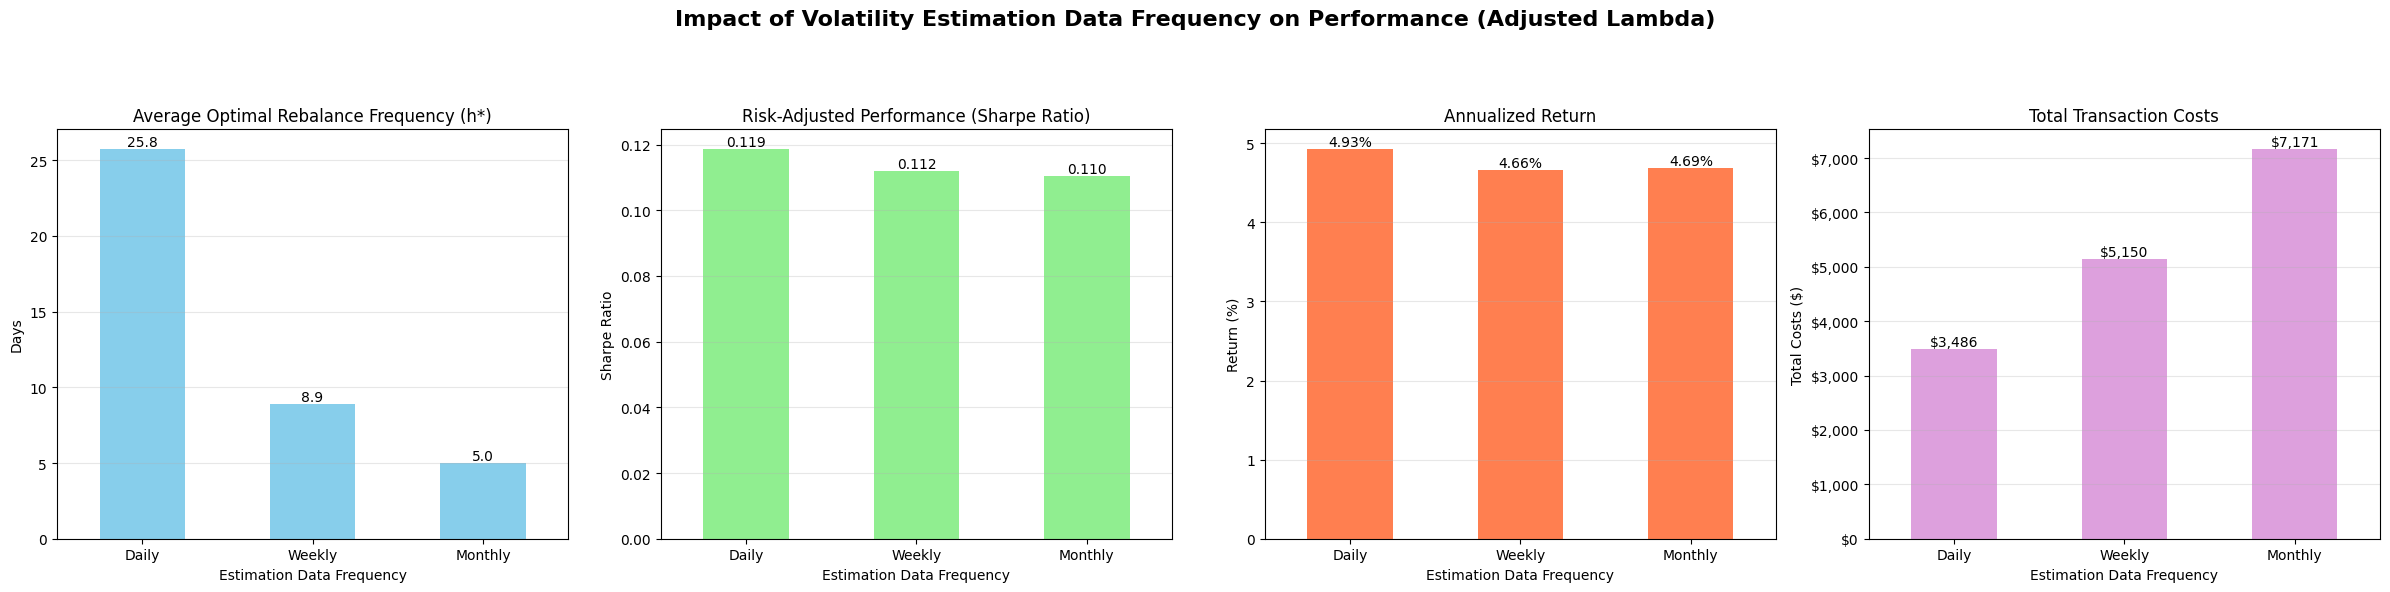


SUMMARY OF DATA FREQUENCY COMPARISON (ADJUSTED LAMBDA)
Estimation Freq  Annual Return  Annual Volatility  Sharpe Ratio  Max Drawdown  Total Transaction Costs ($)  Avg Rebalance Freq (days)  Num Windows  Total Rebalances  Annual Return (%)
          Daily       0.049287           0.415265      0.118688     -0.784970                  3486.134119                     25.750            8                77           4.928713
         Weekly       0.046587           0.415992      0.111989     -0.777778                  5149.678628                      8.875            8               230           4.658671
        Monthly       0.046868           0.424612      0.110378     -0.795752                  7170.524672                      5.000            8               400           4.686766


In [31]:
# ==============================================================================
# UPDATED ANALYSIS: HIGH- VS. LOW-FREQUENCY DATA FOR PARAMETER ESTIMATION
# (with Frequency-Adjusted Lambda)
# ==============================================================================

# We need a dedicated version of the backtest function for this analysis
# because the original walk_forward_backtest (even the one you provided)
# hardcodes the return type calculation (daily_vol_window = np.sqrt(portfolio_variance))
# This function will modify how daily_vol is derived based on `estimation_freq`.
def walk_forward_estimation_freq_comparison_adjusted_lambda(data, train_days, test_days,
                                                         w_star=0.6, c_prop=0.005, F_fixed=50,
                                                         lambda_val_daily_base=0.01, # Renamed for clarity: this is the daily base lambda
                                                         use_cube_rule=True,
                                                         estimation_freq='Daily'):
    """
    Performs a walk-forward backtest where volatility is estimated using
    data of a specific frequency (e.g., 'Daily', 'Weekly', 'Monthly').
    The backtest itself is always run on daily data.

    Crucially, `lambda_val_daily_base` is adjusted based on the `estimation_freq`
    to represent a "per-period" penalty, which then influences the calculation
    of h_optimal.
    """

    global initial_capital, trading_days_per_year # Bring them into scope

    # Initialize results storage
    all_portfolio_values = []
    all_dates = []
    all_optimal_h = []
    all_transaction_costs = []
    all_window_stats_list = []

    # Walk through the data
    start_idx = 0
    window_count = 0

    overall_rebalance_dates = []

    while start_idx + train_days + test_days <= len(data):
        window_count += 1

        # --- Parameter Estimation from Training Window ---
        train_data = data.iloc[start_idx : start_idx + train_days]
        test_data = data.iloc[start_idx + train_days : start_idx + train_days + test_days]

        # Skip window if test_data is empty or too short
        if test_data.empty or len(test_data) < 5:
            start_idx += test_days
            continue

        # --- Adjustment for Lambda and Volatility based on Estimation Frequency ---
        actual_lambda_for_calc = lambda_val_daily_base # Default to daily base

        if estimation_freq == 'Daily':
            returns_for_estimation = train_data.pct_change().dropna()
            # If there's not enough data for covariance, fall back
            if len(returns_for_estimation) < 2:
                daily_vol = 0.01 # Fallback, a small arbitrary daily vol
            else:
                weights_ = np.array([w_star, 1 - w_star])
                cov_matrix_ = returns_for_estimation.cov()
                portfolio_variance_ = weights_.T @ cov_matrix_ @ weights_
                daily_vol = np.sqrt(portfolio_variance_)

            # Lambda remains daily_base

        elif estimation_freq == 'Weekly':
            weekly_train_data = train_data.resample('W').last() # Use W instead of W-FRI for consistency if market data doesn't align
            returns_for_estimation = weekly_train_data.pct_change().dropna()

            if len(returns_for_estimation) < 2:
                 daily_vol = 0.01 # Fallback
            else:
                weights_ = np.array([w_star, 1 - w_star])
                cov_matrix_weekly = returns_for_estimation.cov()
                portfolio_variance_weekly = weights_.T @ cov_matrix_weekly @ weights_
                weekly_vol = np.sqrt(portfolio_variance_weekly)

                # Convert weekly volatility to an approximate daily volatility
                daily_vol = weekly_vol / np.sqrt(5) # Assuming 5 trading days in a week

            # Crucial Change: Scale lambda for weekly periods if it's a "per-period" penalty
            actual_lambda_for_calc = lambda_val_daily_base * 5 # 5 trading days in a week, so weekly penalty increases

        elif estimation_freq == 'Monthly':
            monthly_train_data = train_data.resample('M').last()
            returns_for_estimation = monthly_train_data.pct_change().dropna()

            if len(returns_for_estimation) < 2:
                daily_vol = 0.01 # Fallback
            else:
                weights_ = np.array([w_star, 1 - w_star])
                cov_matrix_monthly = returns_for_estimation.cov()
                portfolio_variance_monthly = weights_.T @ cov_matrix_monthly @ weights_
                monthly_vol = np.sqrt(portfolio_variance_monthly)

                # Convert monthly volatility to an approximate daily volatility
                daily_vol = monthly_vol / np.sqrt(22) # Assuming 22 trading days in a month (approx)

            # Crucial Change: Scale lambda for monthly periods
            actual_lambda_for_calc = lambda_val_daily_base * 22 # 22 trading days in a month, so monthly penalty increases

        else:
            raise ValueError("estimation_freq must be 'Daily', 'Weekly', or 'Monthly'")

        # Ensure daily_vol is not zero
        if daily_vol == 0:
            daily_vol = 0.0001 # Prevent division by zero

        # --- Calculate Optimal h* using the estimated daily_vol and ADJUSTED lambda ---
        v = (w_star * (1 - w_star) * daily_vol) ** 2 # Still represents daily variance component

        if use_cube_rule: # Proportional cost (Cube-root rule)
            a = c_prop * np.sqrt(2 * v / np.pi)
            b = actual_lambda_for_calc * v / 2 # Use the adjusted lambda here
            h_optimal = (a / (2 * b)) ** (2/3) if b > 0 and a > 0 else 252 # Fallback to 252
        else: # Fixed cost (Square-root rule)
            # For fixed costs, lambda still penalizes daily holding cost, not per-period
            # The scaling of lambda is primarily relevant for proportional costs where 'a' and 'b' terms interact differently
            h_optimal = np.sqrt(2 * F_fixed / (lambda_val_daily_base * v)) if lambda_val_daily_base * v > 0 else 252

        h_optimal = int(round(max(5, min(h_optimal, test_days)))) # Bound and cast
        if h_optimal == 0: h_optimal = 5 # Ensure h_optimal is never 0 which would lead to infinite rebalances
        all_optimal_h.append(h_optimal)

        # --- Backtest on Daily Testing Period ---
        # (This part remains the same as it correctly simulates daily actual trading)
        tsla_price = test_data.iloc[0]['TSLA']
        agg_price = test_data.iloc[0]['AGG']
        tsla_shares = (initial_capital * w_star) / tsla_price
        agg_shares = (initial_capital * (1 - w_star)) / agg_price
        transaction_costs_window = 0
        portfolio_values_window = []
        num_rebalances_in_window = 0
        rebalance_dates_in_window = []

        for i in range(len(test_data)):
            current_date = test_data.index[i]
            current_tsla = test_data.iloc[i]['TSLA']
            current_agg = test_data.iloc[i]['AGG']

            tsla_value = tsla_shares * current_tsla
            agg_value = agg_shares * current_agg
            current_value = tsla_value + agg_value

            if i > 0 and i % h_optimal == 0:
                num_rebalances_in_window += 1
                rebalance_dts = test_data.index[i]
                rebalance_dates_in_window.append(rebalance_dts)

                target_tsla = current_value * w_star
                target_agg = current_value * (1 - w_star)

                trade_tsla = target_tsla - tsla_value
                trade_agg = target_agg - agg_value

                if use_cube_rule: # Proportional cost
                    transaction_cost = c_prop * (abs(trade_tsla) + abs(trade_agg))
                else: # Fixed cost
                    transaction_cost = F_fixed if (abs(trade_tsla) > 0 or abs(trade_agg) > 0) else 0

                transaction_costs_window += transaction_cost

                if trade_tsla != 0:
                    tsla_shares += trade_tsla / current_tsla
                if trade_agg != 0:
                    agg_shares += trade_agg / current_agg

                current_value -= transaction_cost

            portfolio_values_window.append(current_value)
            all_dates.append(current_date)

        all_portfolio_values.extend(portfolio_values_window)
        all_transaction_costs.append(transaction_costs_window)
        overall_rebalance_dates.extend(rebalance_dates_in_window)

        if len(portfolio_values_window) > 1:
            window_return = (portfolio_values_window[-1] / portfolio_values_window[0]) - 1
            annualized_return = (1 + window_return) ** (trading_days_per_year / len(test_data)) - 1
            window_volatility_calc = np.std(np.diff(portfolio_values_window) / portfolio_values_window[:-1]) * np.sqrt(trading_days_per_year)
        else:
             window_return, annualized_return, window_volatility_calc = 0, 0, 0

        all_window_stats_list.append({
            'Window': window_count,
            'Start Date': test_data.index[0].date(),
            'End Date': test_data.index[-1].date(),
            'Optimal h': h_optimal,
            'Avg Daily Vol (Est)': daily_vol,
            'Return': window_return,
            'Annualized Return': annualized_return,
            'Volatility (Window)': window_volatility_calc,
            'Transaction Costs': transaction_costs_window,
            'Rebalances': num_rebalances_in_window
        })

        start_idx += test_days

    # --- Calculate and Return Overall Performance Metrics ---
    unique_dates, unique_indices = np.unique(all_dates, return_index=True)
    portfolio_series = pd.Series(np.array(all_portfolio_values)[unique_indices], index=unique_dates)
    portfolio_series = portfolio_series.sort_index()

    if len(portfolio_series) > 1:
        returns = portfolio_series.pct_change().dropna()
        if returns.empty:
            return {}

        total_return = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) - 1
        annual_return = (1 + total_return) ** (trading_days_per_year / len(portfolio_series.index.unique())) - 1
        volatility = returns.std() * np.sqrt(trading_days_per_year)
        sharpe_ratio = annual_return / volatility if volatility > 0 else 0

        rolling_max = portfolio_series.expanding().max()
        drawdowns = (portfolio_series - rolling_max) / rolling_max
        max_drawdown = drawdowns.min()

        total_transaction_costs = sum(all_transaction_costs)
        avg_optimal_h = np.mean(all_optimal_h) if all_optimal_h else 0

        return {
            'Estimation Freq': estimation_freq,
            'Annual Return': annual_return,
            'Annual Volatility': volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown,
            'Total Transaction Costs ($)': total_transaction_costs,
            'Avg Rebalance Freq (days)': avg_optimal_h,
            'Num Windows': window_count,
            'Total Rebalances': len(overall_rebalance_dates)
        }
    else:
        return {}


# --- Main Execution Block for Frequency Comparison ---
print("\n" + "=" * 80)
print("UPDATED ANALYSIS: IMPACT OF VOLATILITY ESTIMATION DATA FREQ (ADJUSTED LAMBDA)")
print("=" * 80)

# --- Parameters ---
data_freq = yf.download(["TSLA", "AGG"], start="2015-01-01", end="2025-01-01")["Close"]
data_freq.columns = ['TSLA', 'AGG']

train_days_freq = 252  # 1 year training window for estimation
test_days_freq = 252   # 1 year testing window for actual backtest

w_star = 0.6
c_prop = 0.005 # Proportional cost
F_fixed = 50   # Fixed cost (not primarily used if use_cube_rule=True)
lambda_val_daily_base = 0.01 # This is the BASE daily drift penalty
use_cube_rule = True # Focused on proportional costs for this example

# Frequencies to compare
estimation_frequencies_to_test = ['Daily', 'Weekly', 'Monthly']
freq_comparison_results_adjusted = []

# --- Run Backtests for Each Estimation Frequency ---
for freq in estimation_frequencies_to_test:
    print(f"\nRunning backtest with parameter estimation using {freq} data (adjusted lambda)...")

    result = walk_forward_estimation_freq_comparison_adjusted_lambda(
        data=data_freq,
        train_days=train_days_freq,
        test_days=test_days_freq,
        w_star=w_star,
        c_prop=c_prop,
        F_fixed=F_fixed,
        lambda_val_daily_base=lambda_val_daily_base, # Pass the base lambda
        use_cube_rule=use_cube_rule,
        estimation_freq=freq
    )

    if result:
        freq_comparison_results_adjusted.append(result)
        print(f"  Completed. Avg h* = {result.get('Avg Rebalance Freq (days)', 0):.1f} days, "
              f"Sharpe = {result.get('Sharpe Ratio', 0):.3f}")
    else:
        print(f"  Backtest did not return valid results for {freq} estimation (likely due to insufficient data for any full window).")

# --- Analyze and Visualize Results ---
if freq_comparison_results_adjusted:
    results_df_freq_adjusted = pd.DataFrame(freq_comparison_results_adjusted)

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    fig.suptitle('Impact of Volatility Estimation Data Frequency on Performance (Adjusted Lambda)', fontsize=16, fontweight='bold')

    # 1. Average Rebalance Frequency
    results_df_freq_adjusted.plot(kind='bar', x='Estimation Freq', y='Avg Rebalance Freq (days)',
                         ax=axes[0], legend=False, color='skyblue', rot=0)
    axes[0].set_title('Average Optimal Rebalance Frequency (h*)')
    axes[0].set_ylabel('Days')
    axes[0].set_xlabel('Estimation Data Frequency')
    axes[0].grid(True, alpha=0.3, axis='y')
    for i, val in enumerate(results_df_freq_adjusted['Avg Rebalance Freq (days)']):
        axes[0].text(i, val, f'{val:.1f}', ha='center', va='bottom')

    # 2. Sharpe Ratio
    results_df_freq_adjusted.plot(kind='bar', x='Estimation Freq', y='Sharpe Ratio',
                         ax=axes[1], legend=False, color='lightgreen', rot=0)
    axes[1].set_title('Risk-Adjusted Performance (Sharpe Ratio)')
    axes[1].set_ylabel('Sharpe Ratio')
    axes[1].set_xlabel('Estimation Data Frequency')
    axes[1].grid(True, alpha=0.3, axis='y')
    for i, val in enumerate(results_df_freq_adjusted['Sharpe Ratio']):
        axes[1].text(i, val, f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top')

    # 3. Annual Return
    results_df_freq_adjusted['Annual Return (%)'] = results_df_freq_adjusted['Annual Return'] * 100
    results_df_freq_adjusted.plot(kind='bar', x='Estimation Freq', y='Annual Return (%)',
                         ax=axes[2], legend=False, color='coral', rot=0)
    axes[2].set_title('Annualized Return')
    axes[2].set_ylabel('Return (%)')
    axes[2].set_xlabel('Estimation Data Frequency')
    axes[2].grid(True, alpha=0.3, axis='y')
    for i, val in enumerate(results_df_freq_adjusted['Annual Return (%)']):
        axes[2].text(i, val, f'{val:.2f}%', ha='center', va='bottom' if val >= 0 else 'top')

    # 4. Total Transaction Costs
    results_df_freq_adjusted.plot(kind='bar', x='Estimation Freq', y='Total Transaction Costs ($)',
                         ax=axes[3], legend=False, color='plum', rot=0)
    axes[3].set_title('Total Transaction Costs')
    axes[3].set_ylabel('Total Costs ($)')
    axes[3].set_xlabel('Estimation Data Frequency')
    axes[3].grid(True, alpha=0.3, axis='y')
    axes[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    for i, val in enumerate(results_df_freq_adjusted['Total Transaction Costs ($)']):
        axes[3].text(i, val, f'${val:,.0f}', ha='center', va='bottom')


    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

    # --- Print Summary Table ---
    print("\n" + "=" * 80)
    print("SUMMARY OF DATA FREQUENCY COMPARISON (ADJUSTED LAMBDA)")
    print("=" * 80)
    print(results_df_freq_adjusted.to_string(index=False))
else:
    print("\nNo results to display. The adjusted lambda data frequency analysis did not complete successfully.")
